Extracting EDF parameters from Z:\25. Interictal activities - Rotem\Bonn\processed\734\P734_mtl_clean.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


C:\Users\user\AppData\Local\Temp\ipykernel_27328\1402058124.py:16: FutureWarning: The default for pick_channels will change from ordered=False to ordered=True in 1.5 and this will result in a change of behavior because the resulting channel order will not match. Either use a channel order that matches your instance or pass ordered=False.
  raw.pick_channels(channel_names).crop(tmin=crop_min, tmax=crop_min + 3)


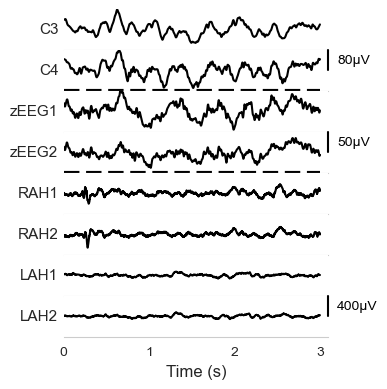

In [3]:
# Figure 1C
import mne
import numpy as np
import matplotlib.pyplot as plt

signal_color = 'black' #'#1f77b4'   # dark blue
zero_line_color = 'lightgray'
axis_line_color = 'black'

# Load and crop data
raw = mne.io.read_raw(r"Z:\25. Interictal activities - Rotem\Bonn\processed\734\P734_mtl_clean.edf")
channel_names = ['C3', 'C4', 'EOG1', 'EOG2', 'RAH1', 'RAH2', 'LAH1', 'LAH2']
# crop_min = 1*3600 + 29*60 + 15
crop_min = 8125
raw.pick_channels(channel_names).crop(tmin=crop_min, tmax=crop_min + 3)

group1_channels = ['C3', 'C4']
group2_channels = ['EOG1', 'EOG2']
group3_channels = [x for x in channel_names if x not in group1_channels + group2_channels]

# Get data for just those channels
data, times = raw.get_data(picks=channel_names, return_times=True)
data *= 1e6  # convert to µV

# Function to round to nice numbers
def round_to_nice_number(value):
    if value < 10:
        return np.ceil(value)  # Round up to nearest integer
    elif value < 100:
        return np.floor(value / 10) * 10  # Round up to nearest 10
    elif value < 1000:
        return np.floor(value / 25) * 25  # Round up to nearest 25
    else:
        return np.floor(value / 50) * 50  # Round up to nearest 50

# Calculate group scales
group1_max = 0
group2_max = 0
group3_max = 0

for ch_data, name in zip(data, channel_names):
    max_abs_value = np.max(np.abs(ch_data)) * 1.1
    
    if name in group1_channels:
        group1_max = max(group1_max, max_abs_value)
    elif name in group2_channels:
        group2_max = max(group2_max, max_abs_value)
    elif name in group3_channels:
        group3_max = max(group3_max, max_abs_value)


# Round group scales to nice numbers
group1_scale = round_to_nice_number(group1_max)
group2_scale = round_to_nice_number(group2_max)
group3_scale = round_to_nice_number(group3_max)
group1_scale = 80
group2_scale = 50
group3_scale = 400

# Plot each channel separately, stacked vertically, with individual scales but equal spacing
fig, axs = plt.subplots(len(channel_names), 1, figsize=(4, 4), sharex=True,
                        gridspec_kw={'hspace': 0.0})  # No space between subplots for equal visual spacing

for i, (ch_data, name) in enumerate(zip(data, channel_names)):    
    axs[i].plot(times, ch_data, color=signal_color)

    if name in group1_channels:
        y_limit = group1_scale
        is_last_in_group = (name == group1_channels[-1])
    elif name in group2_channels:
        y_limit = group2_scale
        is_last_in_group = (name == group2_channels[-1])
    elif name in group3_channels:
        y_limit = group3_scale
        is_last_in_group = (name == group3_channels[-1])
    else:
        # shouldn't happen
        y_limit = 1
        is_last_in_group = False
    
    # Set symmetrical y-limits for this channel
    axs[i].set_ylim(-y_limit, y_limit)
    axs[i].set_yticks([y_limit])  # Only show the positive tick
    xright = times[-1] + 0.1

    # Only show scale line and label for last channel in each group
    if is_last_in_group:
        # Draw a bold line on the right side of the plot
        axs[i].plot([xright, xright], [0, y_limit], color=axis_line_color, linewidth=1.5, zorder=3, clip_on=False)
        
        # Place custom y tick label centered on the bold line
        mid_y = y_limit / 2
        axs[i].text(xright + 0.1, mid_y, str(int(y_limit)) + 'µV',
                    va='center', ha='left', fontsize=10, color='black', clip_on=False)

    # Channel name on the left (positioned at the center of each subplot)
    display_name = name.replace('EOG1', 'zEEG1').replace('EOG2', 'zEEG2')
    axs[i].text(-0.02, 0, display_name,
                transform=axs[i].get_yaxis_transform(),
                rotation=0, ha='right', va='center', fontsize=11)
    
    # Hide default y tick marks and labels
    axs[i].tick_params(axis='y', labelsize=10, left=False, right=False, labelleft=False, labelright=False)
    axs[i].set_yticklabels([])
    
    # Hide all spines except for group separators
    axs[i].spines['left'].set_visible(False)
    axs[i].spines['right'].set_visible(False)

    axs[i].grid(False)
    axs[i].spines['top'].set_visible(False)
    
    # Draw a strong horizontal line after the last channel of group 1
    if name == group1_channels[-1] or name == group2_channels[-1]:
        axs[i].plot([times[0], times[-1]], [-y_limit, -y_limit],
                    color='black', linewidth=3, clip_on=True, ls='--')

    
    axs[i].tick_params(axis='x', labelsize=10)
    axs[i].set_xlim(times[0], xright)

axs[-1].set_xlim(0, xright)
axs[-1].set_xlabel('Time (s)', fontsize=12)

# Ensure all subplots have exactly the same height
plt.tight_layout()
plt.subplots_adjust(hspace=0.0)  # Ensure no space between subplots
fig.savefig(f"figures/P734_{crop_min}.pdf", bbox_inches='tight')
fig.savefig(f"figures/P734_{crop_min}.png", dpi=300, bbox_inches='tight', transparent=False)

plt.show()

Extracting EDF parameters from C:\repos\spikes_notebooks\paper\figures\49_clean_mtl.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


C:\Users\user\AppData\Local\Temp\ipykernel_7644\3510453906.py:24: FutureWarning: The default for pick_channels will change from ordered=False to ordered=True in 1.5 and this will result in a change of behavior because the resulting channel order will not match. Either use a channel order that matches your instance or pass ordered=False.
  raw.pick_channels(channel_names).crop(tmin=crop_min, tmax=crop_min + 3)


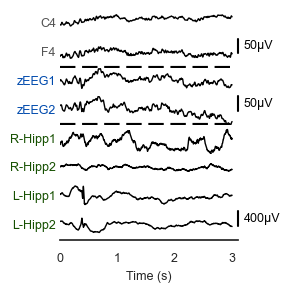

In [149]:
# for grant fixes 07/25
# Figure 1C
import mne
import numpy as np
import matplotlib.pyplot as plt

signal_color = 'black' #'#1f77b4'   # dark blue
zero_line_color = 'lightgray'
axis_line_color = 'black'

subj_time = [('49', 159.5), ('723', 6594), ('734', 8125)]
selected = subj_time[0]
# Load and crop data
if selected[0] == '49':
    raw = mne.io.read_raw(r"figures\49_clean_mtl.edf")
    group1_channels = ['C4', 'F4']
else:
    raw = mne.io.read_raw(rf"figures\P{selected[0]}_mtl_clean.edf")
    group1_channels = ['C3', 'C4']

channel_names = group1_channels + ['EOG1', 'EOG2', 'RAH1', 'RAH2', 'LAH1', 'LAH2']
# crop_min = 1*3600 + 29*60 + 15
crop_min = selected[1]
raw.pick_channels(channel_names).crop(tmin=crop_min, tmax=crop_min + 3)

group2_channels = ['EOG1', 'EOG2']
group3_channels = [x for x in channel_names if x not in group1_channels + group2_channels]

# Get data for just those channels
data, times = raw.get_data(picks=channel_names, return_times=True)
data *= 1e6  # convert to µV

# Function to round to nice numbers
def round_to_nice_number(value):
    if value < 10:
        return np.ceil(value)  # Round up to nearest integer
    elif value < 100:
        return np.floor(value / 10) * 10  # Round up to nearest 10
    elif value < 1000:
        return np.floor(value / 25) * 25  # Round up to nearest 25
    else:
        return np.floor(value / 50) * 50  # Round up to nearest 50

# Calculate group scales
group1_max = 0
group2_max = 0
group3_max = 0

for ch_data, name in zip(data, channel_names):
    max_abs_value = np.max(np.abs(ch_data)) * 1.1
    
    if name in group1_channels:
        group1_max = max(group1_max, max_abs_value)
    elif name in group2_channels:
        group2_max = max(group2_max, max_abs_value)
    elif name in group3_channels:
        group3_max = max(group3_max, max_abs_value)


# Round group scales to nice numbers
group1_scale = round_to_nice_number(group1_max)
group2_scale = round_to_nice_number(group2_max)
group3_scale = round_to_nice_number(group3_max)
if selected[0] == '49':
    group1_scale = 50
    group2_scale = 50
    group3_scale = 400
elif selected[0] == '723':
    group1_scale = 60
    group2_scale = 30
    group3_scale = 600
else:
    group1_scale = 80
    group2_scale = 50
    group3_scale = 400

# Plot each channel separately, stacked vertically, with individual scales but equal spacing
fig, axs = plt.subplots(len(channel_names), 1, figsize=(3, 3), sharex=True,
                        gridspec_kw={'hspace': 0.0})  # No space between subplots for equal visual spacing

for i, (ch_data, name) in enumerate(zip(data, channel_names)):    
    axs[i].plot(times, ch_data, color=signal_color, linewidth=1)

    if name in group1_channels:
        y_limit = group1_scale
        is_last_in_group = (name == group1_channels[-1])
    elif name in group2_channels:
        y_limit = group2_scale
        is_last_in_group = (name == group2_channels[-1])
    elif name in group3_channels:
        y_limit = group3_scale
        is_last_in_group = (name == group3_channels[-1])
    else:
        # shouldn't happen
        y_limit = 1
        is_last_in_group = False
    
    # Set symmetrical y-limits for this channel
    axs[i].set_ylim(-y_limit, y_limit)
    axs[i].set_yticks([y_limit])  # Only show the positive tick
    xright = times[-1] + 0.1

    # Only show scale line and label for last channel in each group
    if is_last_in_group:
        # Draw a bold line on the right side of the plot
        axs[i].plot([xright, xright], [0, y_limit], color=axis_line_color, linewidth=1.5, zorder=3, clip_on=False)
        
        # Place custom y tick label centered on the bold line
        mid_y = y_limit / 2
        axs[i].text(xright + 0.1, mid_y, str(int(y_limit)) + 'µV',
                    va='center', ha='left', fontsize=9, color='black', clip_on=False)

    # Channel name on the left (positioned at the center of each subplot)
    if selected[0] == '49':
        display_name = name.replace('EOG1', 'zEEG1').replace('EOG2', 'zEEG2').replace('RAH1', 'R-Hipp1').replace('RAH2', 'R-Hipp2').replace('LAH1', 'L-Hipp1').replace('LAH2', 'L-Hipp2')
    else:
        display_name = name.replace('EOG1', 'zEEG1').replace('EOG2', 'zEEG2').replace('RAH1', 'R-Hipp1').replace('RAH2', 'R-Hipp2').replace('LAH1', 'L-Hipp1').replace('LAH2', 'L-Hipp2')
    
    if "z" in display_name:
        display_color = '#004aad'  # dark blue
    elif "Hipp" in display_name:
        display_color = '#165001'
    else:
        display_color = '#545454'
    axs[i].text(-0.02, 0, display_name,
                transform=axs[i].get_yaxis_transform(),
                rotation=0, ha='right', va='center', fontsize=9, color=display_color)
    
    # Hide default y tick marks and labels
    axs[i].tick_params(axis='y', labelsize=10, left=False, right=False, labelleft=False, labelright=False)
    axs[i].set_yticklabels([])
    
    # Hide all spines except for group separators
    axs[i].spines['left'].set_visible(False)
    axs[i].spines['right'].set_visible(False)

    axs[i].grid(False)
    axs[i].spines['top'].set_visible(False)
    if i != len(axs) - 1:
        axs[i].spines['bottom'].set_visible(False)
    
    # Draw a strong horizontal line after the last channel of group 1
    if name == group1_channels[-1] or name == group2_channels[-1]:
        axs[i].plot([times[0], times[-1]], [-y_limit, -y_limit],
                    color='black', linewidth=3, clip_on=True, ls='--')

    
    axs[i].tick_params(axis='x', labelsize=9)
    axs[i].set_xlim(times[0], xright)

axs[-1].set_xlim(0, xright)
axs[-1].set_xlabel('Time (s)', fontsize=9)

# Ensure all subplots have exactly the same height
plt.tight_layout()
plt.subplots_adjust(hspace=0.0)  # Ensure no space between subplots
# fig.savefig(f"figures/P{selected[0]}_{crop_min}_raw_hipp.png", dpi=300, bbox_inches='tight', transparent=False)
fig.savefig(f"figures/P{selected[0]}_{crop_min}_raw_hipp.pdf", dpi=600, bbox_inches="tight", pad_inches=0.02)


plt.show()

Opening raw data file ofer_pipe\RMH1.fif...
Isotrak not found
    Range : 0 ... 5344999 =      0.000 ...  5344.999 secs
Ready.


C:\Users\user\AppData\Local\Temp\ipykernel_9364\3554558419.py:24: RuntimeWarning: This filename (ofer_pipe\RMH1.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(raw_path, preload=True)


Reading 0 ... 5344999  =      0.000 ...  5344.999 secs...
Not setting metadata
149 matching events found
Setting baseline interval to [-0.25, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 149 events and 501 original time points ...
0 bad epochs dropped
Using data from preloaded Raw for 149 events and 501 original time points ...


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
C:\Users\user\AppData\Local\Temp\ipykernel_9364\3554558419.py:161: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


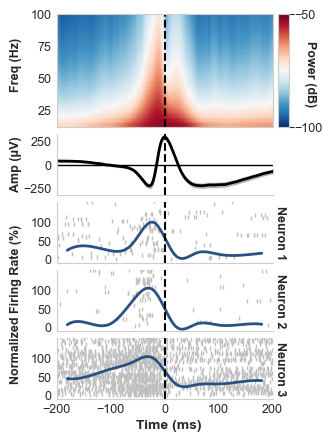

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mne
import glob
from scipy.interpolate import make_interp_spline

# === Load your data ===
# Replace these with your actual subject, paths and selections
subj = '018'
channels = ['RMH']
units = [('RMH2', 1), ('RMH6', 3), ('RMH7', 1)]
window_ms = 200
tmin = -250
tmax = 250

# Load macro data
raw_path = fr"ofer_pipe\RMH1.fif"
npz_path = fr"ofer_pipe\RMH1.npz"
raw = mne.io.read_raw_fif(raw_path, preload=True)
npz = np.load(npz_path)
spikes = npz['array']
zeros = np.zeros((spikes.shape[0], 2), dtype=int)
spikes = np.hstack((spikes, zeros))
spikes[:, -1] = np.arange(spikes.shape[0])
spikes = spikes[spikes[:, 0] != spikes[0, 0]]
epochs = mne.Epochs(raw, spikes, tmin=tmin/1000, tmax=tmax/1000, event_repeated='drop')
evoked = epochs.average()

# Time-Frequency
freqs = np.linspace(12, 100, 25)
n_cycles = 2.0
if (n_cycles / freqs[0]) <= (tmax - tmin) / 1000:
    power = mne.time_frequency.tfr_morlet(epochs, freqs, n_cycles, use_fft=True,
                                          return_itc=False, average=True)
else:
    power = mne.time_frequency.tfr_multitaper(epochs, freqs, n_cycles=2, use_fft=True,
                                              return_itc=False, average=True)

# Load spike data
peaks_file = fr"ofer_pipe\p018_flat_features.csv"
df_peaks = pd.read_csv(peaks_file)
filtered_df = df_peaks[df_peaks['channel'].str.startswith(tuple(channels))]
peaks = filtered_df['timestamp'].astype(int).tolist()
n_trials = len(peaks)

unit_files = glob.glob(fr"D:\Hanna\D{subj}\units\*_unit*.csv")
desired_filenames = {f"{name}_unit{num}.csv" for name, num in units}
filtered_unit_files = [f for f in unit_files if os.path.basename(f) in desired_filenames]
n_units = len(filtered_unit_files)

# === Build the full figure ===
import matplotlib.gridspec as gridspec
fig = plt.figure(figsize=(3, 5))
gs = gridspec.GridSpec(5, 2, width_ratios=[20, 1], height_ratios=[1.3, 0.7, 0.7, 0.7, 0.7], hspace=0.1, wspace=0.05)

# TFR
ax1 = fig.add_subplot(gs[0, 0])
cax = fig.add_subplot(gs[0, 1])
tfr_times_ms = power.times * 1000
edge_margin = 50
valid_time_mask = (tfr_times_ms >= (tmin + edge_margin)) & (tfr_times_ms <= (tmax - edge_margin))
tfr_times_crop = tfr_times_ms[valid_time_mask]
tfr_data = np.mean(power.data, axis=0) if power.data.shape[0] > 1 else power.data[0]
tfr_data_db = 10 * np.log10(tfr_data)
tfr_data_crop = tfr_data_db[:, valid_time_mask]
im = ax1.imshow(tfr_data_crop, aspect='auto', origin='lower',
                extent=[tfr_times_crop[0], tfr_times_crop[-1], freqs[0], freqs[-1]],
                cmap='RdBu_r', vmin=-100, vmax=-50)
plt.colorbar(im, cax=cax, ticks=[-100, -50])
ax1.axvline(0, color='black', linestyle='--')
ax1.set_yticks([25, 50, 75, 100])
ax1.tick_params(labelbottom=False)
ax1.set_xlim(tfr_times_crop[0], tfr_times_crop[-1])

# ERP
ax2 = fig.add_subplot(gs[1, 0], sharex=ax1)
times_ms = evoked.times * 1000
data = evoked.data.T * 1e6
for i in range(data.shape[1]):
    ax2.plot(times_ms, data[:, i], color='black', linewidth=2)
if len(epochs) > 1:
    epoch_data_all = epochs.get_data() * 1e6
    for i in range(data.shape[1]):
        ch_data = epoch_data_all[:, i, :]
        mean_data = np.mean(ch_data, axis=0)
        sem_data = np.std(ch_data, axis=0) / np.sqrt(len(epochs))
        ax2.fill_between(times_ms, mean_data - sem_data, mean_data + sem_data, alpha=0.2, color='black')
ax2.axvline(0, color='black', linestyle='--')
ax2.axhline(0, color='black', linestyle='-', linewidth=1)
ax2.set_ylim(-1.1 * np.max(np.abs(data)), 1.1 * np.max(np.abs(data)))
ax2.tick_params(labelbottom=False)

# Raster + PSTH
bin_size = 40
bin_edges = np.linspace(-window_ms, window_ms, int(2 * window_ms / bin_size) + 1)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
X_ = np.linspace(bin_centers.min(), bin_centers.max(), 300)


for j, unit_file in enumerate(filtered_unit_files):
    spikes = pd.read_csv(unit_file, header=None)[0].to_list()
    unit = np.zeros(spikes[-1])
    unit[spikes[:-1]] = 1

    ax_raster = fig.add_subplot(gs[j + 2, 0], sharex=ax1)
    trials_hist = []
    for i, peak in enumerate(peaks):
        start, end = peak - window_ms, peak + window_ms
        if start < 0 or end > len(unit): continue
        curr = unit[start:end]
        spike_times = np.where(curr == 1)[0] - window_ms
        ax_raster.scatter(spike_times, [i] * len(spike_times), color='#BFBFBF', s=5, marker='|', linewidths=1)
        trials_hist.extend(spike_times)

    # PSTH
    counts, _ = np.histogram(trials_hist, bins=bin_edges)
    y = (counts / (n_trials * bin_size)) * 1000  # Hz
    y = (y / y.max()) * 100
    spline = make_interp_spline(bin_centers, y)
    Y_ = spline(X_)
    ax_raster.plot(X_, Y_, color='#2b5082', linewidth=2)

    ax_raster.axvline(0, color='black', linestyle='--')
    ax_raster.set_ylim(-10, 155)
    ax_raster.set_yticks([0, 50, 100])
    # Only show x-axis labels on the last subplot
    if j == n_units - 1:
        ax_raster.tick_params(axis='x', labelsize=8)
    else:
        ax_raster.tick_params(labelbottom=False)
    ax_raster.tick_params(axis='y', labelsize=8)
    ax_raster.set_ylabel(f'Neuron {j+1}', fontsize=9, fontweight='bold', rotation=270, labelpad=10)
    ax_raster.yaxis.set_label_position("right")


# Add one common ylabel on right
fig.text(0.95, 0.7, 'Power (dB)', fontsize=9, fontweight='bold', rotation=270)
fig.text(-0.03, 0.78, 'Freq (Hz)', va='center', rotation=90, fontsize=9, fontweight='bold')
fig.text(-0.03, 0.58, 'Amp (μV)', va='center', rotation=90, fontsize=9, fontweight='bold')
fig.text(-0.03, 0.3, 'Normalized Firing Rate (%)', va='center', rotation=90, fontsize=9, fontweight='bold')

# Shared x-axis label
fig.text(0.5, 0.05, 'Time (ms)', ha='center', fontsize=10, fontweight='bold')

# remove grid from all axes
for i, ax in enumerate(fig.get_axes()):
    ax.grid(False)
    ax.tick_params(axis='both', labelsize=9, pad=0)

    if i != 0:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

# save the figure
plt.tight_layout()
# plt.savefig('figures/018_MTL_combined_gray.png', dpi=300, bbox_inches='tight')
plt.show()

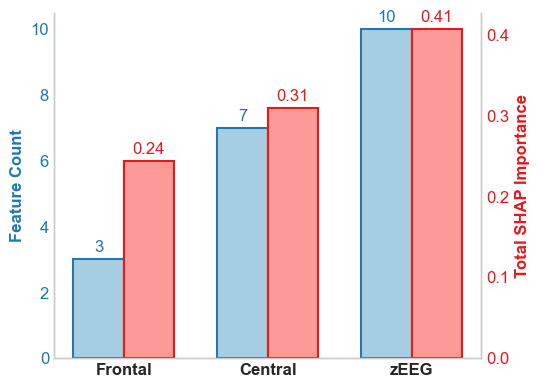

In [25]:
# supplementary?
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load your data
df_shap_summary = pd.read_csv('figures/feature_importence_summary.csv')

# Extract values
group_order = df_shap_summary['Group'].tolist()
ordered_counts = df_shap_summary['TopFeatureCount'].tolist()
ordered_sums = df_shap_summary['SHAPSum'].tolist()

# Define color pairs
count_fill = '#A6CEE3'   # Light blue
count_edge = '#1F78B4'   # Navy blue
shap_fill = '#FB9A99'    # Light red
shap_edge = '#E31A1C'    # Dark red

x = np.arange(len(group_order))
width = 0.35

fig, ax1 = plt.subplots(figsize=(5.5, 4))

# Left axis (Feature Count)
bar1 = ax1.bar(x - width/2, ordered_counts, width,
               color=count_fill, edgecolor=count_edge, linewidth=1.5, zorder=3)
ax1.set_ylabel('Feature Count', fontsize=12, fontweight='bold', color=count_edge)
ax1.tick_params(axis='y', labelcolor=count_edge, colors=count_edge, labelsize=12)
ax1.set_xticks(x)
ax1.set_xticklabels(group_order, fontsize=12, fontweight='bold')
ax1.spines['top'].set_visible(False)
ax1.grid(False)

# Right axis (SHAP Sum)
ax2 = ax1.twinx()
bar2 = ax2.bar(x + width/2, ordered_sums, width,
               color=shap_fill, edgecolor=shap_edge, linewidth=1.5, zorder=2)
ax2.set_ylabel('Total SHAP Importance', fontsize=12, fontweight='bold', color=shap_edge)
ax2.tick_params(axis='y', labelcolor=shap_edge, colors=shap_edge, labelsize=12)
ax2.set_yticks([0, 0.1, 0.2, 0.3, 0.4])
ax2.spines['top'].set_visible(False)
ax2.grid(False)

# Annotations
for rect in bar1:
    height = rect.get_height()
    ax1.annotate(f'{int(height)}', xy=(rect.get_x() + rect.get_width()/2, height),
                 xytext=(0, 3), textcoords="offset points",
                 ha='center', va='bottom', fontsize=12, color=count_edge)

for rect in bar2:
    height = rect.get_height()
    ax2.annotate(f'{height:.2f}', xy=(rect.get_x() + rect.get_width()/2, height),
                 xytext=(0, 3), textcoords="offset points",
                 ha='center', va='bottom', fontsize=12, color=shap_edge)

fig.tight_layout()
fig.savefig(f"figures/features_bars.png", dpi=300, bbox_inches='tight', transparent=False)
plt.show()

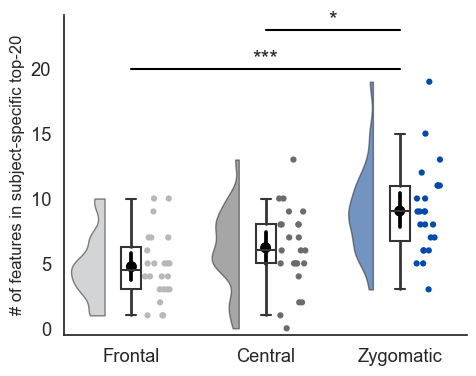

In [153]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import ptitprince as pt
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests

# סגנון
sns.set_context("notebook", font_scale=1.2)
sns.set_style("white")

# קריאת הנתונים
df = pd.read_csv('figures/subject_shap_summary_balanced_per_subj.csv')

# המרה ל־long
df_long = pd.melt(
    df,
    id_vars='subj',
    value_vars=[col for col in df.columns if col.startswith('count_')],
    var_name='metric_group',
    value_name='value'
)
df_long['region'] = df_long['metric_group'].str.split('_').str[1]
# שינוי שם zEEG ל-Zygomatic
df_long['region'] = df_long['region'].replace({'zEEG': 'Zygomatic'})
df_long['metric_type'] = 'count'
region_order = ['Frontal', 'Central', 'Zygomatic']
pairs = [('Frontal', 'Central'), ('Frontal', 'Zygomatic'), ('Central', 'Zygomatic')]

# פילטור
data_subset = df_long[df_long['metric_type'] == 'count']
region_palette = {
    'Frontal': '#b6b8b9',
    'Central': '#6b6b6b',
    'Zygomatic': '#004aad'
}
# ציור
fig, ax = plt.subplots(figsize=(5, 4))

# Raincloud
pt.RainCloud(
    x='region',
    y='value',
    data=data_subset,
    order=region_order,
    palette=region_palette,
    bw=.3,
    width_viol=.5,
    ax=ax,
    orient='v',
    move=0.2,
    alpha=0.6,
    pointplot=False,
    box_showfliers=False,
    point_size=4.5
)

# ממוצעים
sns.pointplot(
    data=data_subset,
    x='region',
    y='value',
    order=region_order,
    color='black',
    join=False,
    markers='o',
    errorbar=None,
    scale=0.9,
    ax=ax
)

# סטטיסטיקה
pvals = []
for g1, g2 in pairs:
    vals1 = data_subset[data_subset['region'] == g1]['value']
    vals2 = data_subset[data_subset['region'] == g2]['value']
    stat, p = ttest_ind(vals1, vals2, equal_var=False)
    pvals.append(p)

reject, pvals_corrected, _, _ = multipletests(pvals, method='bonferroni')

# ציור כוכביות – עם רווח ברור
y_max = data_subset['value'].max()
y_offset = y_max * 0.01
line_heights = [10, 20, 23]     # גובה קווים (לפי סדר הזוגות)
star_heights = [22, 20, 23]     # גובה הכוכביות

for i, ((g1, g2), pval_corr) in enumerate(zip(pairs, pvals_corrected)):
    if pval_corr < 0.001:
        star = '***'
    elif pval_corr < 0.01:
        star = '**'
    elif pval_corr < 0.05:
        star = '*'
    else:
        continue

    x1 = region_order.index(g1)
    x2 = region_order.index(g2)
    x_center = (x1 + x2) / 2
    y_line = line_heights[i]
    y_star = star_heights[i]

    ax.plot([x1, x2], [y_line, y_line], color='black', linewidth=1.5)
    ax.text(x_center, y_star, star, ha='center', va='bottom', fontsize=16)

# עיצוב
ax.set_ylabel("# of features in subject-specific top-20", fontsize=12)
ax.set_xlabel("")  # הסרת המילה Region
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim(bottom=-0.5)

plt.tight_layout()
# fig.savefig(f"figures/features_raincloud_gray.png", dpi=300, bbox_inches='tight', transparent=False)
fig.savefig("figures/features_raincloud_gray.pdf", dpi=600, bbox_inches="tight", pad_inches=0.02)

plt.show()

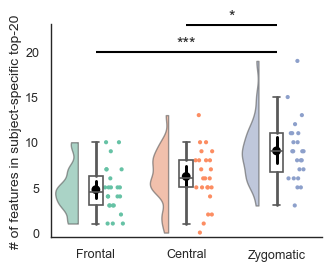

In [153]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import ptitprince as pt
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests
import numpy as np

# ===== סגנון קומפקטי עם פונטים ברורים =====
sns.set_style("white")
sns.set_context("paper", font_scale=1.5)   # 'paper' מיועד לפיגרים קטנים; font_scale מגדיל קריאוּת
plt.rcParams.update({
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
})

# ===== קריאת נתונים והכנה (כמו אצלך) =====
df = pd.read_csv('figures/subject_shap_summary_balanced_per_subj.csv')

df_long = pd.melt(
    df,
    id_vars='subj',
    value_vars=[c for c in df.columns if c.startswith('count_')],
    var_name='metric_group',
    value_name='value'
)
df_long['region'] = df_long['metric_group'].str.split('_').str[1]
df_long['region'] = df_long['region'].replace({'zEEG': 'Zygomatic'})
region_order = ['Frontal', 'Central', 'Zygomatic']
pairs = [('Frontal', 'Central'), ('Frontal', 'Zygomatic'), ('Central', 'Zygomatic')]
data_subset = df_long  # זה כבר count

# ===== ציור קטן אבל חד =====
fig, ax = plt.subplots(figsize=(3.2, 2.6), constrained_layout=True)  # קטן וברור

pt.RainCloud(
    x='region', y='value', data=data_subset,
    order=region_order, palette='Set2',
    bw=.3, width_viol=.5, ax=ax, orient='v',
    move=0.2, alpha=0.6, pointplot=False, box_showfliers=False,
)

sns.pointplot(
    data=data_subset, x='region', y='value', order=region_order,
    color='black', join=False, markers='o', errorbar=None, scale=0.9, ax=ax
)

# ===== סטטיסטיקה (כמו אצלך) =====
pvals = []
for g1, g2 in pairs:
    v1 = data_subset.loc[data_subset['region']==g1, 'value']
    v2 = data_subset.loc[data_subset['region']==g2, 'value']
    _, p = ttest_ind(v1, v2, equal_var=False)
    pvals.append(p)
_, pvals_corrected, _, _ = multipletests(pvals, method='bonferroni')

# קווי השוואה – התאמה לגובה הדאטה כדי שלא ייחתך בפיגר קטן
y_max = data_subset['value'].max()
line_heights = [max(y_max*1.02, 10), max(y_max*1.05, 20), max(y_max*1.1, 23)]
star_heights = [lh + 0.05 for lh in line_heights]
ax.set_ylim(top=max(y_max*1.01, star_heights[-1]), bottom=-0.5)

for i, ((g1, g2), p) in enumerate(zip(pairs, pvals_corrected)):
    if p < 0.001: star = '***'
    elif p < 0.01: star = '**'
    elif p < 0.05: star = '*'
    else: 
        continue

    x1, x2 = region_order.index(g1), region_order.index(g2)
    y_line = line_heights[i]         # <-- זה הגובה של הקו
    y_star = star_heights[i]

    # קו מובהקות בעובי אחיד ומעל כל הגרפיקה
    ax.hlines(y=y_line, xmin=x1, xmax=x2,
              colors='black', linewidth=1.5, zorder=10)

    # כוכביות
    ax.text((x1 + x2) / 2, y_star, star,
            ha='center', va='bottom', fontsize=12, zorder=11)

# ===== עיצוב ופונטים =====
ax.set_ylabel('# of features in subject-specific top-20', labelpad=2)
ax.set_xlabel('')
ax.tick_params(axis='x', labelsize=9)
ax.tick_params(axis='y', labelsize=9)
sns.despine(ax=ax, top=True, right=True)
# שמירה חדה מאוד (מומלץ גם גרסת PDF וקטורית למאמר)
fig.savefig("figures/features_raincloud_small.png", dpi=600, bbox_inches='tight')
plt.show()


C:\Users\user\AppData\Local\Temp\ipykernel_19264\2551987338.py:114: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


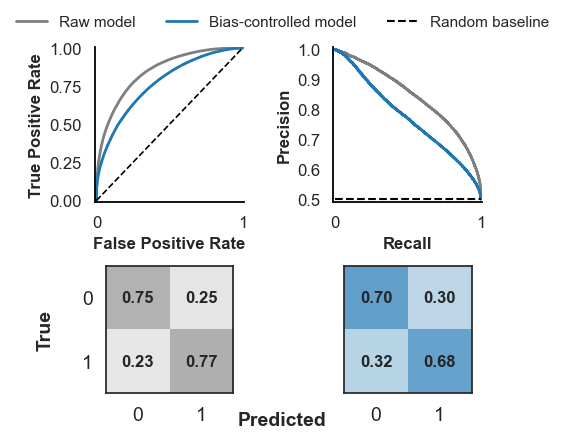

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
from matplotlib.colors import to_rgb
import seaborn as sns
from matplotlib.gridspec import GridSpec

# === Setup ===
sns.set_context("notebook", font_scale=1.3)
sns.set_style("white")
fig = plt.figure(figsize=(5, 4.5))
gs = GridSpec(2, 2, height_ratios=[1.1, 0.9], hspace=0.45, wspace=0.6)

# === ROC & PR Curves (Top Row) ===
roc1 = pd.read_csv('figures/roc_curve_bmax_asym.csv')
metrics1 = pd.read_csv('figures/curve_bmax_asym_metrics.csv')
roc2 = pd.read_csv('figures/roc_curve_b3000_sym.csv')
metrics2 = pd.read_csv('figures/roc_curve_b3000_sym_metrics.csv')
pr1 = pd.read_csv('figures/pr_curve_bmax_asym.csv')
pr2 = pd.read_csv('figures/pr_curve_b3000_sym.csv')

# ROC Curve
# ROC Curve
ax_roc = fig.add_subplot(gs[0, 0])
roc_line1, = ax_roc.plot(roc1['fpr'], roc1['tpr'], label='Raw model', linewidth=2, color='#7f7f7f')  # gray
roc_line2, = ax_roc.plot(roc2['fpr'], roc2['tpr'], label='Bias-controlled model', linewidth=2, color='#1f77b4')  # blue

rand_line, = ax_roc.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Random classifier')
ax_roc.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
ax_roc.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
ax_roc.set_xlim([-0.01, 1.01])
ax_roc.set_ylim([-0.01, 1.01])
for side in ['top', 'right']:
    ax_roc.spines[side].set_visible(False)
for side in ['left', 'bottom']:
    ax_roc.spines[side].set_color('black')
    ax_roc.spines[side].set_linewidth(1.3)

# PR Curve
ax_pr = fig.add_subplot(gs[0, 1])
ax_pr.plot(pr1['recall'], pr1['precision'], label='Raw model', linewidth=2, color='#7f7f7f')  # gray
ax_pr.plot(pr2['recall'], pr2['precision'], label='Bias-controlled model', linewidth=2, color='#1f77b4')  # blue
ax_pr.hlines(y=0.5, xmin=0, xmax=1, colors='black', linestyles='--', label='Random baseline')
ax_pr.set_xlabel('Recall', fontsize=12, fontweight='bold')
ax_pr.set_ylabel('Precision', fontsize=12, fontweight='bold')
ax_pr.set_xlim([-0.01, 1.01])
ax_pr.set_ylim([0.49, 1.01])
for side in ['top', 'right']:
    ax_pr.spines[side].set_visible(False)
for side in ['left', 'bottom']:
    ax_pr.spines[side].set_color('black')
    ax_pr.spines[side].set_linewidth(1.3)

ax_roc.set_yticks([0.0, 0.25, 0.5, 0.75, 1.0])
ax_pr.set_yticks([0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
ax_roc.tick_params(axis='both', labelsize=12)
ax_pr.tick_params(axis='both', labelsize=12)

# === Confusion Matrices (Bottom Row) ===
paths = [
    ('figures/confusion_bmax_asym_metrics.csv', '#999999'),   # gray for Raw model
    ('figures/confusion_b3000_sym_metrics.csv', '#1f77b4')    # blue for Bias-controlled
]

for i, (path, base_color) in enumerate(paths):
    ax = fig.add_subplot(gs[1, i])
    df = pd.read_csv(path)
    y_true, y_pred = df['y_true'], df['y_pred']
    cm = confusion_matrix(y_true, y_pred, normalize='true')

    base_rgb = np.array(to_rgb(base_color))
    cm_colors = np.ones((*cm.shape, 3))
    for row in range(2):
        for col in range(2):
            intensity = 1 - cm[row, col]
            alt_row, alt_col = row, 1 - col
            cm_colors[alt_row, alt_col] = 1 - (1 - base_rgb) * intensity

    ax.imshow(cm_colors, extent=[-0.5, 1.5, 1.5, -0.5])
    for row in range(2):
        for col in range(2):
            ax.text(col, row, f"{cm[row, col]:.2f}", ha='center', va='center', fontsize=12, fontweight='bold')

    ax.set_xticks([0, 1])
    ax.set_xticklabels(['0', '1'], fontsize=14)
    ax.set_yticks([0, 1])

    if i == 0:
        ax.set_yticklabels(['0', '1'], fontsize=14)
        ax.set_ylabel("True", fontsize=14, fontweight='bold')
        ax.yaxis.set_label_coords(-0.4, 0.5)  # Shift label left (tweak as needed)

    else:
        ax.set_yticklabels([])
        ax.set_ylabel("")

# === Centered "Predicted" Label ===
fig.text(0.5, 0.05, 'Predicted', ha='center', va='center', fontsize=14, fontweight='bold')

# === Legend Just Below the Top Row (Under the Curves' X-Axes) ===
handles, labels = ax_pr.get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc='upper center',
    bbox_to_anchor=(0.5, 0.98),  # slightly below top row axes
    ncol=3,
    frameon=False,
    fontsize=11
)


# === Final Layout ===
# plt.tight_layout(rect=[0, 0.1, 1, 0.945])
plt.tight_layout()
# Save the figure
fig.savefig('figures/combined_curves_and_confusion.png', dpi=300, bbox_inches='tight', transparent=False)
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_7644\4270248404.py:125: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


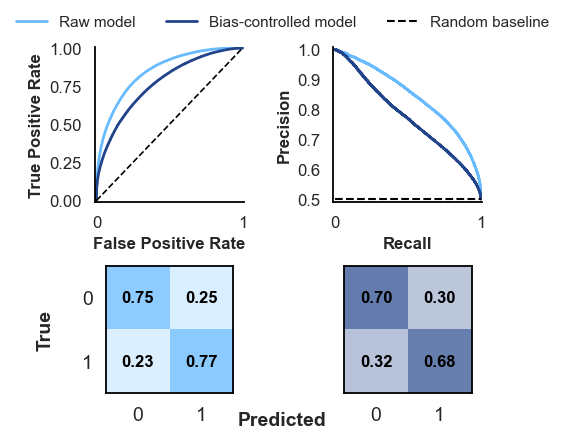

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LinearSegmentedColormap

# === Colors ===
LIGHT_BLUE = "#69BBFF"   # כחול בהיר
DARK_BLUE  = "#21448B"   # כחול כהה

# Colormaps: White -> Blue shade
cmap_light = LinearSegmentedColormap.from_list("white_to_lightblue", ["#FFFFFF", LIGHT_BLUE])
cmap_dark  = LinearSegmentedColormap.from_list("white_to_darkblue",  ["#FFFFFF", DARK_BLUE])

# === Setup ===
sns.set_context("notebook", font_scale=1.3)
sns.set_style("white")
fig = plt.figure(figsize=(5, 4.5))
gs = GridSpec(2, 2, height_ratios=[1.1, 0.9], hspace=0.45, wspace=0.6)

# === ROC & PR Curves (Top Row) ===
roc1 = pd.read_csv('figures/roc_curve_bmax_asym.csv')
metrics1 = pd.read_csv('figures/curve_bmax_asym_metrics.csv')
roc2 = pd.read_csv('figures/roc_curve_b3000_sym.csv')
metrics2 = pd.read_csv('figures/roc_curve_b3000_sym_metrics.csv')  # ← תוקן

pr1 = pd.read_csv('figures/pr_curve_bmax_asym.csv')
pr2 = pd.read_csv('figures/pr_curve_b3000_sym.csv')

# ROC Curve
ax_roc = fig.add_subplot(gs[0, 0])
ax_roc.plot(roc1['fpr'], roc1['tpr'], label='Raw model', linewidth=2, color=LIGHT_BLUE)
ax_roc.plot(roc2['fpr'], roc2['tpr'], label='Bias-controlled model', linewidth=2, color=DARK_BLUE)
ax_roc.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Random classifier')
ax_roc.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
ax_roc.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
ax_roc.set_xlim([-0.01, 1.01])
ax_roc.set_ylim([-0.01, 1.01])
# הסרת ספיינים רק בעקומות
for side in ['top', 'right']:
    ax_roc.spines[side].set_visible(False)
for side in ['left', 'bottom']:
    ax_roc.spines[side].set_color('black')
    ax_roc.spines[side].set_linewidth(1.3)

# PR Curve
ax_pr = fig.add_subplot(gs[0, 1])
ax_pr.plot(pr1['recall'], pr1['precision'], label='Raw model', linewidth=2, color=LIGHT_BLUE)
ax_pr.plot(pr2['recall'], pr2['precision'], label='Bias-controlled model', linewidth=2, color=DARK_BLUE)
ax_pr.hlines(y=0.5, xmin=0, xmax=1, colors='black', linestyles='--', label='Random baseline')
ax_pr.set_xlabel('Recall', fontsize=12, fontweight='bold')
ax_pr.set_ylabel('Precision', fontsize=12, fontweight='bold')
ax_pr.set_xlim([-0.01, 1.01])
ax_pr.set_ylim([0.49, 1.01])
# הסרת ספיינים רק בעקומות
for side in ['top', 'right']:
    ax_pr.spines[side].set_visible(False)
for side in ['left', 'bottom']:
    ax_pr.spines[side].set_color('black')
    ax_pr.spines[side].set_linewidth(1.3)

ax_roc.set_yticks([0.0, 0.25, 0.5, 0.75, 1.0])
ax_pr.set_yticks([0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
ax_roc.tick_params(axis='both', labelsize=12)
ax_pr.tick_params(axis='both', labelsize=12)

# === Confusion Matrices (Bottom Row) ===
specs = [
    {'path': 'figures/confusion_bmax_asym_metrics.csv', 'cmap': cmap_light, 'label': 'Raw model'},
    {'path': 'figures/confusion_b3000_sym_metrics.csv', 'cmap': cmap_dark,  'label': 'Bias-controlled model'},
]

for i, spec in enumerate(specs):
    ax = fig.add_subplot(gs[1, i])
    df = pd.read_csv(spec['path'])
    y_true, y_pred = df['y_true'], df['y_pred']
    cm = confusion_matrix(y_true, y_pred, normalize='true')

    # Heatmap: white -> model's blue shade
    ax.imshow(cm, vmin=0, vmax=1, cmap=spec['cmap'], extent=[-0.5, 1.5, 1.5, -0.5], aspect='equal')

    # Numeric labels – תמיד שחור
    for row in range(2):
        for col in range(2):
            val = cm[row, col]
            ax.text(col, row, f"{val:.2f}", ha='center', va='center',
                    fontsize=12, fontweight='bold', color='black')

    ax.set_xticks([0, 1])
    ax.set_xticklabels(['0', '1'], fontsize=14)
    ax.set_yticks([0, 1])

    if i == 0:
        ax.set_yticklabels(['0', '1'], fontsize=14)
        ax.set_ylabel("True", fontsize=14, fontweight='bold')
        ax.yaxis.set_label_coords(-0.4, 0.5)
    else:
        ax.set_yticklabels([])
        ax.set_ylabel("")

    # במטריצות לא מסירים ספיינים
    for side in ['top', 'right', 'left', 'bottom']:
        ax.spines[side].set_visible(True)
        ax.spines[side].set_color('black')
        ax.spines[side].set_linewidth(1.3)

# === Centered "Predicted" Label ===
fig.text(0.5, 0.05, 'Predicted', ha='center', va='center', fontsize=14, fontweight='bold')

# === Legend (for curves) ===
handles, labels = ax_pr.get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc='upper center',
    bbox_to_anchor=(0.5, 0.98),
    ncol=3,
    frameon=False,
    fontsize=11
)

# === Final Layout ===
plt.tight_layout()
fig.savefig('figures/combined_curves_and_confusion_blue.png', dpi=300, bbox_inches='tight', transparent=False)
plt.show()


C:\Users\user\AppData\Local\Temp\ipykernel_7644\2986906785.py:130: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  fig.savefig("figures/combined_curves_and_confusion_blue.pdf", dpi=300, bbox_inches="tight", pad_inches=0.02)
C:\Users\user\anaconda3\envs\depth_ieds\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  fig.canvas.print_figure(bytes_io, **kw)


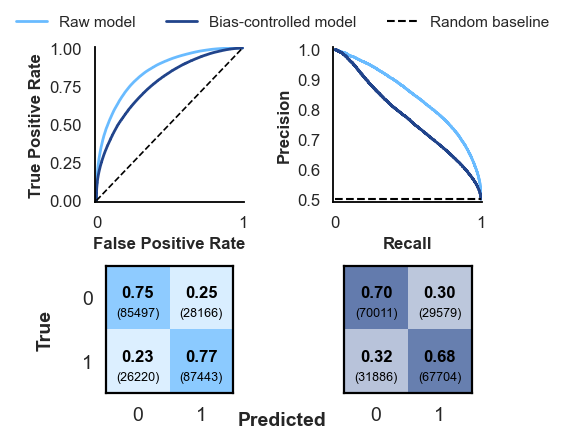

In [162]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LinearSegmentedColormap

# === Colors ===
LIGHT_BLUE = "#69BBFF"   # כחול בהיר
DARK_BLUE  = "#21448B"   # כחול כהה

# Colormaps: White -> Blue shade
cmap_light = LinearSegmentedColormap.from_list("white_to_lightblue", ["#FFFFFF", LIGHT_BLUE])
cmap_dark  = LinearSegmentedColormap.from_list("white_to_darkblue",  ["#FFFFFF", DARK_BLUE])

# === Setup ===
sns.set_context("notebook", font_scale=1.3)
sns.set_style("white")
fig = plt.figure(figsize=(5, 4.5), constrained_layout=True)
gs = GridSpec(2, 2, height_ratios=[1.1, 0.9], hspace=0.45, wspace=0.6)

# === ROC & PR Curves (Top Row) ===
roc1 = pd.read_csv('figures/roc_curve_bmax_asym.csv')
metrics1 = pd.read_csv('figures/curve_bmax_asym_metrics.csv')
roc2 = pd.read_csv('figures/roc_curve_b3000_sym.csv')
metrics2 = pd.read_csv('figures/roc_curve_b3000_sym_metrics.csv')  # ← תוקן

pr1 = pd.read_csv('figures/pr_curve_bmax_asym.csv')
pr2 = pd.read_csv('figures/pr_curve_b3000_sym.csv')

# ROC Curve
ax_roc = fig.add_subplot(gs[0, 0])
ax_roc.plot(roc1['fpr'], roc1['tpr'], label='Raw model', linewidth=2, color=LIGHT_BLUE)
ax_roc.plot(roc2['fpr'], roc2['tpr'], label='Bias-controlled model', linewidth=2, color=DARK_BLUE)
ax_roc.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Random classifier')
ax_roc.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
ax_roc.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
ax_roc.set_xlim([-0.01, 1.01])
ax_roc.set_ylim([-0.01, 1.01])
# הסרת ספיינים רק בעקומות
for side in ['top', 'right']:
    ax_roc.spines[side].set_visible(False)
for side in ['left', 'bottom']:
    ax_roc.spines[side].set_color('black')
    ax_roc.spines[side].set_linewidth(1.3)

# PR Curve
ax_pr = fig.add_subplot(gs[0, 1])
ax_pr.plot(pr1['recall'], pr1['precision'], label='Raw model', linewidth=2, color=LIGHT_BLUE)
ax_pr.plot(pr2['recall'], pr2['precision'], label='Bias-controlled model', linewidth=2, color=DARK_BLUE)
ax_pr.hlines(y=0.5, xmin=0, xmax=1, colors='black', linestyles='--', label='Random baseline')
ax_pr.set_xlabel('Recall', fontsize=12, fontweight='bold')
ax_pr.set_ylabel('Precision', fontsize=12, fontweight='bold')
ax_pr.set_xlim([-0.01, 1.01])
ax_pr.set_ylim([0.49, 1.01])
# הסרת ספיינים רק בעקומות
for side in ['top', 'right']:
    ax_pr.spines[side].set_visible(False)
for side in ['left', 'bottom']:
    ax_pr.spines[side].set_color('black')
    ax_pr.spines[side].set_linewidth(1.3)

ax_roc.set_yticks([0.0, 0.25, 0.5, 0.75, 1.0])
ax_pr.set_yticks([0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
ax_roc.tick_params(axis='both', labelsize=12)
ax_pr.tick_params(axis='both', labelsize=12)

# === Confusion Matrices (Bottom Row) ===
specs = [
    {'path': 'figures/confusion_bmax_asym_metrics.csv', 'cmap': cmap_light, 'label': 'Raw model'},
    {'path': 'figures/confusion_b3000_sym_metrics.csv', 'cmap': cmap_dark,  'label': 'Bias-controlled model'},
]

for i, spec in enumerate(specs):
    ax = fig.add_subplot(gs[1, i])
    df = pd.read_csv(spec['path'])
    y_true, y_pred = df['y_true'], df['y_pred']
    cm_counts = confusion_matrix(y_true, y_pred)  # ← raw counts
    cm_norm = confusion_matrix(y_true, y_pred, normalize='true')

    # Heatmap: white -> model's blue shade
    ax.imshow(cm_norm, vmin=0, vmax=1, cmap=spec['cmap'], extent=[-0.5, 1.5, 1.5, -0.5], aspect='equal')

    # Numeric labels – תמיד שחור
    for row in range(2):
        for col in range(2):
            val_norm = cm_norm[row, col]
            val_count = cm_counts[row, col]

            ax.text(col, row - 0.07, f"{val_norm:.2f}", ha='center', va='center',
                    fontsize=12, fontweight='bold', color='black')
            ax.text(col, row + 0.25, f"({val_count})", ha='center', va='center',
                    fontsize=9, color='black')

    ax.set_xticks([0, 1])
    ax.set_xticklabels(['0', '1'], fontsize=14)
    ax.set_yticks([0, 1])

    if i == 0:
        ax.set_yticklabels(['0', '1'], fontsize=14)
        ax.set_ylabel("True", fontsize=14, fontweight='bold')
        ax.yaxis.set_label_coords(-0.4, 0.5)
    else:
        ax.set_yticklabels([])
        ax.set_ylabel("")

    # במטריצות לא מסירים ספיינים
    for side in ['top', 'right', 'left', 'bottom']:
        ax.spines[side].set_visible(True)
        ax.spines[side].set_color('black')
        ax.spines[side].set_linewidth(1.6)

# === Centered "Predicted" Label ===
fig.text(0.5, 0.05, 'Predicted', ha='center', va='center', fontsize=14, fontweight='bold')

# === Legend (for curves) ===
handles, labels = ax_pr.get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc='upper center',
    bbox_to_anchor=(0.5, 0.98),
    ncol=3,
    frameon=False,
    fontsize=11
)

# === Final Layout ===
fig.savefig("figures/combined_curves_and_confusion_blue.pdf", dpi=300, bbox_inches="tight", pad_inches=0.02)
plt.show()


Extracting EDF parameters from C:\repos\spikes_notebooks\paper\figures\38_clean_mtl.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


C:\Users\user\AppData\Local\Temp\ipykernel_7644\3684475027.py:19: FutureWarning: The default for pick_channels will change from ordered=False to ordered=True in 1.5 and this will result in a change of behavior because the resulting channel order will not match. Either use a channel order that matches your instance or pass ordered=False.
  raw.pick_channels(channel_names).crop(tmin=crop_min, tmax=crop_min + 3.5)


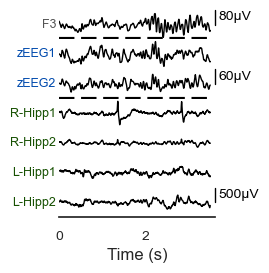

In [165]:
# figure 2f
import mne
import numpy as np
import matplotlib.pyplot as plt

signal_color = 'black' #'#1f77b4'   # dark blue
zero_line_color = 'lightgray'
axis_line_color = 'black'

selected = ('38', 5716)
# Load and crop data
# raw = mne.io.read_raw(rf"Z:\25. Interictal activities - Rotem\Bonn\processed\{selected[0]}\P{selected[0]}_mtl_clean.edf")
raw = mne.io.read_raw(rf"figures\{selected[0]}_clean_mtl.edf")
group1_channels = ['F3']

channel_names = group1_channels + ['EOG1', 'EOG2', 'RAH1', 'RAH2', 'LMH1', 'LMH2']
# crop_min = 1*3600 + 29*60 + 15
crop_min = selected[1]
raw.pick_channels(channel_names).crop(tmin=crop_min, tmax=crop_min + 3.5)

group2_channels = ['EOG1', 'EOG2']
group3_channels = [x for x in channel_names if x not in group1_channels + group2_channels]

# Get data for just those channels
data, times = raw.get_data(picks=channel_names, return_times=True)
data *= 1e6  # convert to µV

# Function to round to nice numbers
def round_to_nice_number(value):
    if value < 10:
        return np.ceil(value)  # Round up to nearest integer
    elif value < 100:
        return np.floor(value / 10) * 10  # Round up to nearest 10
    elif value < 1000:
        return np.floor(value / 25) * 25  # Round up to nearest 25
    else:
        return np.floor(value / 50) * 50  # Round up to nearest 50

# Calculate group scales
group1_max = 0
group2_max = 0
group3_max = 0

for ch_data, name in zip(data, channel_names):
    max_abs_value = np.max(np.abs(ch_data)) * 1.1
    
    if name in group1_channels:
        group1_max = max(group1_max, max_abs_value)
    elif name in group2_channels:
        group2_max = max(group2_max, max_abs_value)
    elif name in group3_channels:
        group3_max = max(group3_max, max_abs_value)


# Round group scales to nice numbers
group1_scale = round_to_nice_number(group1_max)
group2_scale = round_to_nice_number(group2_max)
group3_scale = round_to_nice_number(group3_max)
group1_scale = 80
group2_scale = 60
group3_scale = 500


# Plot each channel separately, stacked vertically, with individual scales but equal spacing
fig, axs = plt.subplots(len(channel_names), 1, figsize=(3, 3), sharex=True,
                        gridspec_kw={'hspace': 0.0})  # No space between subplots for equal visual spacing

for i, (ch_data, name) in enumerate(zip(data, channel_names)):    
    axs[i].plot(times, ch_data, color=signal_color, linewidth=1)

    if name in group1_channels:
        y_limit = group1_scale
        is_last_in_group = (name == group1_channels[-1])
    elif name in group2_channels:
        y_limit = group2_scale
        is_last_in_group = (name == group2_channels[-1])
    elif name in group3_channels:
        y_limit = group3_scale
        is_last_in_group = (name == group3_channels[-1])
    else:
        # shouldn't happen
        y_limit = 1
        is_last_in_group = False
    
    # Set symmetrical y-limits for this channel
    axs[i].set_ylim(-y_limit, y_limit)
    axs[i].set_yticks([y_limit])  # Only show the positive tick
    xright = times[-1] + 0.1

    # Only show scale line and label for last channel in each group
    if is_last_in_group:
        # Draw a bold line on the right side of the plot
        axs[i].plot([xright, xright], [0, y_limit], color=axis_line_color, linewidth=1, zorder=3, clip_on=False)
        
        # Place custom y tick label centered on the bold line
        mid_y = y_limit / 2
        axs[i].text(xright + 0.1, mid_y, str(int(y_limit)) + 'µV',
                    va='center', ha='left', fontsize=10, color='black', clip_on=False)

    # Channel name on the left (positioned at the center of each subplot)
    display_name = name.replace('EOG1', 'zEEG1').replace('EOG2', 'zEEG2').replace('RAH1', 'R-Hipp1').replace('RAH2', 'R-Hipp2').replace('LMH1', 'L-Hipp1').replace('LMH2', 'L-Hipp2')
    if "z" in display_name:
        display_color = '#004aad'  # dark blue
    elif "Hipp" in display_name:
        display_color = '#165001'
    else:
        display_color = '#545454'
        
    axs[i].text(-0.02, 0, display_name,
            transform=axs[i].get_yaxis_transform(),
            rotation=0, ha='right', va='center', fontsize=9, color=display_color)

    
    # Hide default y tick marks and labels
    axs[i].tick_params(axis='y', labelsize=10, left=False, right=False, labelleft=False, labelright=False)
    axs[i].set_yticklabels([])
    
    # Hide all spines except for group separators
    axs[i].spines['left'].set_visible(False)
    axs[i].spines['right'].set_visible(False)

    axs[i].grid(False)
    axs[i].spines['top'].set_visible(False)
    if i != len(axs) - 1:
        axs[i].spines['bottom'].set_visible(False)

    
    # Draw a strong horizontal line after the last channel of group 1
    if name == group1_channels[-1] or name == group2_channels[-1]:
        axs[i].plot([times[0], times[-1]], [-y_limit, -y_limit],
                    color='black', linewidth=3, clip_on=True, ls='--')

    axs[i].tick_params(axis='x', labelsize=10)
    axs[i].set_xlim(times[0], xright)

axs[-1].set_xlim(0, xright)
axs[-1].set_xlabel('Time (s)', fontsize=12)

# Ensure all subplots have exactly the same height
plt.tight_layout()
plt.subplots_adjust(hspace=0.0)  # Ensure no space between subplots
# save
# fig.savefig(f"figures/P{selected[0]}_{crop_min}.png", bbox_inches='tight', dpi=300)
fig.savefig(f"figures/P{selected[0]}_{crop_min}_detection.pdf", dpi=600, bbox_inches="tight", pad_inches=0.02)

plt.show()

Opening raw data file D:\clean_zeeg\P013_mtl_clean.fif...


C:\Users\user\AppData\Local\Temp\ipykernel_7644\827800671.py:12: RuntimeWarning: This filename (D:\clean_zeeg\P013_mtl_clean.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif('D:\\clean_zeeg\\P013_mtl_clean.fif', preload=True)


Isotrak not found
    Range : 0 ... 30161999 =      0.000 ... 30161.999 secs
Ready.
Reading 0 ... 30161999  =      0.000 ... 30161.999 secs...
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


C:\Users\user\AppData\Local\Temp\ipykernel_7644\827800671.py:18: FutureWarning: The default for pick_channels will change from ordered=False to ordered=True in 1.5 and this will result in a change of behavior because the resulting channel order will not match. Either use a channel order that matches your instance or pass ordered=False.
  raw.pick_channels(channel_names).crop(tmin=crop_min, tmax=crop_min + 3.5)


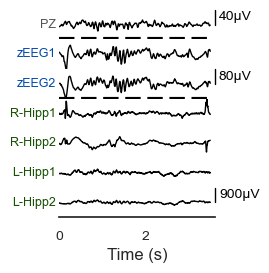

In [168]:
# 2f
import mne
import numpy as np
import matplotlib.pyplot as plt

signal_color = 'black' #'#1f77b4'   # dark blue
zero_line_color = 'lightgray'
axis_line_color = 'black'

selected = ('013', 4221.1)
# Load and crop data
raw = mne.io.read_raw_fif('D:\\clean_zeeg\\P013_mtl_clean.fif', preload=True)
group1_channels = ['PZ']

channel_names = group1_channels + ['EOG1', 'EOG2', 'RMH1', 'RMH2', 'LMH1', 'LMH2']
# crop_min = 1*3600 + 29*60 + 15
crop_min = selected[1]
raw.pick_channels(channel_names).crop(tmin=crop_min, tmax=crop_min + 3.5)

group2_channels = ['EOG1', 'EOG2']
group3_channels = [x for x in channel_names if x not in group1_channels + group2_channels]

# Get data for just those channels
data, times = raw.get_data(picks=channel_names, return_times=True)
data *= 1e6  # convert to µV

# Function to round to nice numbers
def round_to_nice_number(value):
    if value < 10:
        return np.ceil(value)  # Round up to nearest integer
    elif value < 100:
        return np.floor(value / 10) * 10  # Round up to nearest 10
    elif value < 1000:
        return np.floor(value / 25) * 25  # Round up to nearest 25
    else:
        return np.floor(value / 50) * 50  # Round up to nearest 50

# Calculate group scales
group1_max = 0
group2_max = 0
group3_max = 0

for ch_data, name in zip(data, channel_names):
    max_abs_value = np.max(np.abs(ch_data)) * 1.1
    
    if name in group1_channels:
        group1_max = max(group1_max, max_abs_value)
    elif name in group2_channels:
        group2_max = max(group2_max, max_abs_value)
    elif name in group3_channels:
        group3_max = max(group3_max, max_abs_value)


# Round group scales to nice numbers
group1_scale = round_to_nice_number(group1_max)
group2_scale = round_to_nice_number(group2_max)
group3_scale = round_to_nice_number(group3_max)
group1_scale = 40
group2_scale = 80
group3_scale = 900


# Plot each channel separately, stacked vertically, with individual scales but equal spacing
fig, axs = plt.subplots(len(channel_names), 1, figsize=(3, 3), sharex=True,
                        gridspec_kw={'hspace': 0.0})  # No space between subplots for equal visual spacing

for i, (ch_data, name) in enumerate(zip(data, channel_names)):    
    axs[i].plot(times, ch_data, color=signal_color, linewidth=1)

    if name in group1_channels:
        y_limit = group1_scale
        is_last_in_group = (name == group1_channels[-1])
    elif name in group2_channels:
        y_limit = group2_scale
        is_last_in_group = (name == group2_channels[-1])
    elif name in group3_channels:
        y_limit = group3_scale
        is_last_in_group = (name == group3_channels[-1])
    else:
        # shouldn't happen
        y_limit = 1
        is_last_in_group = False
    
    # Set symmetrical y-limits for this channel
    axs[i].set_ylim(-y_limit, y_limit)
    axs[i].set_yticks([y_limit])  # Only show the positive tick
    xright = times[-1] + 0.1

    # Only show scale line and label for last channel in each group
    if is_last_in_group:
        # Draw a bold line on the right side of the plot
        axs[i].plot([xright, xright], [0, y_limit], color=axis_line_color, linewidth=1, zorder=3, clip_on=False)
        
        # Place custom y tick label centered on the bold line
        mid_y = y_limit / 2
        axs[i].text(xright + 0.1, mid_y, str(int(y_limit)) + 'µV',
                    va='center', ha='left', fontsize=10, color='black', clip_on=False)

    # Channel name on the left (positioned at the center of each subplot)
    display_name = name.replace('EOG1', 'zEEG1').replace('EOG2', 'zEEG2').replace('RMH1', 'R-Hipp1').replace('RMH2', 'R-Hipp2').replace('LMH1', 'L-Hipp1').replace('LMH2', 'L-Hipp2')
    if "z" in display_name:
        display_color = '#004aad'  # dark blue
    elif "Hipp" in display_name:
        display_color = '#165001'
    else:
        display_color = '#545454'
        
    axs[i].text(-0.02, 0, display_name,
            transform=axs[i].get_yaxis_transform(),
            rotation=0, ha='right', va='center', fontsize=9, color=display_color)
    
    # Hide default y tick marks and labels
    axs[i].tick_params(axis='y', labelsize=10, left=False, right=False, labelleft=False, labelright=False)
    axs[i].set_yticklabels([])
    
    # Hide all spines except for group separators
    axs[i].spines['left'].set_visible(False)
    axs[i].spines['right'].set_visible(False)

    axs[i].grid(False)
    axs[i].spines['top'].set_visible(False)
    if i != len(axs) - 1:
        axs[i].spines['bottom'].set_visible(False)
    
    # Draw a strong horizontal line after the last channel of group 1
    if name == group1_channels[-1] or name == group2_channels[-1]:
        axs[i].plot([times[0], times[-1]], [-y_limit, -y_limit],
                    color='black', linewidth=3, clip_on=True, ls='--')

    axs[i].tick_params(axis='x', labelsize=10)
    axs[i].set_xlim(times[0], xright)

axs[-1].set_xlim(0, xright)
axs[-1].set_xlabel('Time (s)', fontsize=12)

# Ensure all subplots have exactly the same height
plt.tight_layout()
plt.subplots_adjust(hspace=0.0)  # Ensure no space between subplots
# save
# fig.savefig(f"figures/P{selected[0]}_{crop_min}.png", bbox_inches='tight', dpi=300)
fig.savefig(f"figures/P{selected[0]}_{crop_min}_detection.pdf", dpi=600, bbox_inches="tight", pad_inches=0.02)

plt.show()

Extracting EDF parameters from C:\repos\spikes_notebooks\paper\figures\P746_mtl_clean.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


C:\Users\user\AppData\Local\Temp\ipykernel_7644\197150726.py:18: FutureWarning: The default for pick_channels will change from ordered=False to ordered=True in 1.5 and this will result in a change of behavior because the resulting channel order will not match. Either use a channel order that matches your instance or pass ordered=False.
  raw.pick_channels(channel_names).crop(tmin=crop_min, tmax=crop_min + 3.5)


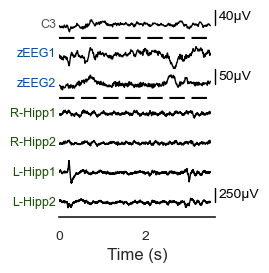

In [167]:
# Figure 2f
import mne
import numpy as np
import matplotlib.pyplot as plt

signal_color = 'black' #'#1f77b4'   # dark blue
zero_line_color = 'lightgray'
axis_line_color = 'black'

selected = ('746', 9440.8)
# Load and crop data
raw = mne.io.read_raw(rf"figures\P{selected[0]}_mtl_clean.edf")
group1_channels = ['C3']

channel_names = group1_channels + ['EOG1', 'EOG2', 'RAH1', 'RAH2', 'LAH1', 'LAH2']
# crop_min = 1*3600 + 29*60 + 15
crop_min = selected[1]
raw.pick_channels(channel_names).crop(tmin=crop_min, tmax=crop_min + 3.5)

group2_channels = ['EOG1', 'EOG2']
group3_channels = [x for x in channel_names if x not in group1_channels + group2_channels]

# Get data for just those channels
data, times = raw.get_data(picks=channel_names, return_times=True)
data *= 1e6  # convert to µV

# Function to round to nice numbers
def round_to_nice_number(value):
    if value < 10:
        return np.ceil(value)  # Round up to nearest integer
    elif value < 100:
        return np.floor(value / 10) * 10  # Round up to nearest 10
    elif value < 1000:
        return np.floor(value / 25) * 25  # Round up to nearest 25
    else:
        return np.floor(value / 50) * 50  # Round up to nearest 50

# Calculate group scales
group1_max = 0
group2_max = 0
group3_max = 0

for ch_data, name in zip(data, channel_names):
    max_abs_value = np.max(np.abs(ch_data)) * 1.1
    
    if name in group1_channels:
        group1_max = max(group1_max, max_abs_value)
    elif name in group2_channels:
        group2_max = max(group2_max, max_abs_value)
    elif name in group3_channels:
        group3_max = max(group3_max, max_abs_value)


# Round group scales to nice numbers
group1_scale = round_to_nice_number(group1_max)
group2_scale = round_to_nice_number(group2_max)
group3_scale = round_to_nice_number(group3_max)
group1_scale = 40
group2_scale = 50
group3_scale = 250


# Plot each channel separately, stacked vertically, with individual scales but equal spacing
fig, axs = plt.subplots(len(channel_names), 1, figsize=(3, 3), sharex=True,
                        gridspec_kw={'hspace': 0.0})  # No space between subplots for equal visual spacing

for i, (ch_data, name) in enumerate(zip(data, channel_names)):    
    axs[i].plot(times, ch_data, color=signal_color, linewidth=1)

    if name in group1_channels:
        y_limit = group1_scale
        is_last_in_group = (name == group1_channels[-1])
    elif name in group2_channels:
        y_limit = group2_scale
        is_last_in_group = (name == group2_channels[-1])
    elif name in group3_channels:
        y_limit = group3_scale
        is_last_in_group = (name == group3_channels[-1])
    else:
        # shouldn't happen
        y_limit = 1
        is_last_in_group = False
    
    # Set symmetrical y-limits for this channel
    axs[i].set_ylim(-y_limit, y_limit)
    axs[i].set_yticks([y_limit])  # Only show the positive tick
    xright = times[-1] + 0.1

    # Only show scale line and label for last channel in each group
    if is_last_in_group:
        # Draw a bold line on the right side of the plot
        axs[i].plot([xright, xright], [0, y_limit], color=axis_line_color, linewidth=1, zorder=3, clip_on=False)
        
        # Place custom y tick label centered on the bold line
        mid_y = y_limit / 2
        axs[i].text(xright + 0.1, mid_y, str(int(y_limit)) + 'µV',
                    va='center', ha='left', fontsize=10, color='black', clip_on=False)

    # Channel name on the left (positioned at the center of each subplot)
    display_name = name.replace('EOG1', 'zEEG1').replace('EOG2', 'zEEG2').replace('RAH1', 'R-Hipp1').replace('RAH2', 'R-Hipp2').replace('LAH1', 'L-Hipp1').replace('LAH2', 'L-Hipp2')
    if "z" in display_name:
        display_color = '#004aad'  # dark blue
    elif "Hipp" in display_name:
        display_color = '#165001'
    else:
        display_color = '#545454'
        
    axs[i].text(-0.02, 0, display_name,
            transform=axs[i].get_yaxis_transform(),
            rotation=0, ha='right', va='center', fontsize=9, color=display_color)
    
    # Hide default y tick marks and labels
    axs[i].tick_params(axis='y', labelsize=10, left=False, right=False, labelleft=False, labelright=False)
    axs[i].set_yticklabels([])
    
    # Hide all spines except for group separators
    axs[i].spines['left'].set_visible(False)
    axs[i].spines['right'].set_visible(False)

    axs[i].grid(False)
    axs[i].spines['top'].set_visible(False)
    if i != len(axs) - 1:
        axs[i].spines['bottom'].set_visible(False)
    
    # Draw a strong horizontal line after the last channel of group 1
    if name == group1_channels[-1] or name == group2_channels[-1]:
        axs[i].plot([times[0], times[-1]], [-y_limit, -y_limit],
                    color='black', linewidth=3, clip_on=True, ls='--')

    axs[i].tick_params(axis='x', labelsize=10)
    axs[i].set_xlim(times[0], xright)

axs[-1].set_xlim(0, xright)
axs[-1].set_xlabel('Time (s)', fontsize=12)

# Ensure all subplots have exactly the same height
plt.tight_layout()
plt.subplots_adjust(hspace=0.0)  # Ensure no space between subplots
# save
# fig.savefig(f"figures/P{selected[0]}_{crop_min}.png", bbox_inches='tight', dpi=300)
fig.savefig(f"figures/P{selected[0]}_{crop_min}_detection.pdf", dpi=600, bbox_inches="tight", pad_inches=0.02)

plt.show()

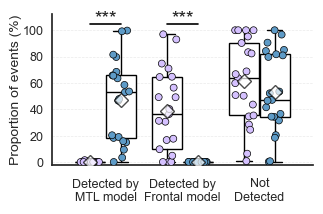

In [171]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests

# === Load and preprocess data ===
# df = pd.read_excel(r"\\132.66.207.73\rem\35. RotemV\frontal_channels\Plot Data in Excel\kfold_xgb\kfold_xgb_boxplot.xlsx")
df = pd.read_excel(r"figures\kfold_xgb_boxplot.xlsx")

df = df[
    (df['Depth Category'] != 'Both Depth') &
    (df['Scalp Detection Type'] != 'Both Scalp')
]

df['Scalp Detection Type'] = df['Scalp Detection Type'].replace({
    'MTL Scalp': 'Detected by\nMTL model',
    'Frontal Scalp': 'Detected by\nFrontal model',
    'Not Detected': 'Not\nDetected'
})
df['Depth Category'] = df['Depth Category'].replace({
    'Only Frontal Depth': 'Frontal IEDs',
    'Only MTL Depth': 'MTL IEDs'
})

# === Style ===
sns.set_context("notebook", font_scale=1.3)
sns.set_style("white")

fig, ax = plt.subplots(figsize=(3.5, 2.5))

depth_palette = {
    'MTL IEDs': '#5E9BC7',
    'Frontal IEDs': '#d5c1ff' 
}

# === Boxplot ===
sns.boxplot(
    x='Scalp Detection Type',
    y='Percentage',
    hue='Depth Category',
    data=df,
    ax=ax,
    palette=['white'] * len(df['Depth Category'].unique()),  # Boxes white,
    showfliers=False,
    linewidth=1,
    boxprops=dict(edgecolor='black', facecolor='white'),
    medianprops=dict(color='black', linewidth=1),
    whiskerprops=dict(color='black', linewidth=1),
    capprops=dict(color='black', linewidth=1)
)


sns.stripplot(
    x='Scalp Detection Type',
    y='Percentage',
    hue='Depth Category',
    data=df,
    dodge=True,
    jitter=0.25,
    size=5,
    palette=depth_palette,
    edgecolor='black',
    linewidth=0.5,
    ax=ax
)

# === Black diamonds for means ===
group_means = df.groupby(['Scalp Detection Type', 'Depth Category'])['Percentage'].mean().reset_index()
for i, x_cat in enumerate(df['Scalp Detection Type'].unique()):
    for j, depth_cat in enumerate(df['Depth Category'].unique()):
        subset = group_means[
            (group_means['Scalp Detection Type'] == x_cat) &
            (group_means['Depth Category'] == depth_cat)
        ]
        if not subset.empty:
            x_pos = i - 0.2 + j * 0.4
            y_mean = subset['Percentage'].values[0]
            ax.plot(x_pos, y_mean, marker='D', markerfacecolor='white', markeredgecolor='black', markersize=7, alpha=0.7, zorder=3)

# === Stats: t-tests and significance ===
groups = df['Scalp Detection Type'].unique()
depths = df['Depth Category'].unique()
pvals = []
pairs = []

for x_cat in groups:
    vals = []
    for d_cat in depths:
        subset = df[
            (df['Scalp Detection Type'] == x_cat) &
            (df['Depth Category'] == d_cat)
        ]['Percentage'].dropna()
        vals.append(subset)
    if len(vals) == 2:
        stat, p = ttest_ind(vals[0], vals[1], equal_var=False)
        pvals.append(p)
        pairs.append((x_cat, depths[0], depths[1]))

# Bonferroni correction
reject, pvals_corrected, _, _ = multipletests(pvals, method='bonferroni')

# === Add aligned stars ===
star_y = df['Percentage'].max() + 7
line_y = star_y - 2
for i, (x_cat, d1, d2) in enumerate(pairs):
    if not reject[i]:
        continue
    star = '***' if pvals_corrected[i] < 0.001 else '**' if pvals_corrected[i] < 0.01 else '*'
    x_idx = list(groups).index(x_cat)
    ax.plot([x_idx - 0.2, x_idx + 0.2], [line_y] * 2, color='black', linewidth=1.2)
    ax.text(x_idx, star_y-5, star, ha='center', va='bottom', fontsize=14)

# === Final formatting ===
ax.set_ylabel('Proportion of events (%)', fontsize=10, labelpad=0)
ax.set_xlabel('')
ax.set_ylim(bottom=-2, top=star_y + 5)
ax.tick_params(axis='x', labelsize=9)
ax.tick_params(axis='y', labelsize=9, pad=0)
ax.yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.4)

# === Legend inside top right, deduplicated ===
# Get only boxplot handles for legend
box_handles, box_labels = ax.get_legend_handles_labels()

# Keep only the first 2 handles (Frontal IEDs, MTL IEDs) from the boxplot
ax.legend(
    handles=box_handles[:2],
    labels=box_labels[:2],
    loc='upper center',
    bbox_to_anchor=(0.5, 1.22),  # adjust vertical placement
    ncol=2,
    frameon=False,
    fontsize=11
)
ax.legend_.remove()


sns.despine()
plt.tight_layout(rect=[0, 0, 1, 0.95])  # leave space at the top for the legend
# save
# plt.savefig('figures/frontal_boxplot_flipped_purple.png', dpi=300, bbox_inches='tight', transparent=False)
fig.savefig(f"figures/frontal_boxplot_flipped_pink.pdf", dpi=600, bbox_inches="tight", pad_inches=0.02)

plt.show()


C:\Users\user\AppData\Local\Temp\ipykernel_7644\1859917893.py:140: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


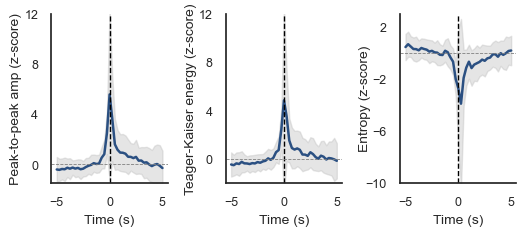

In [254]:
import numpy as np
import matplotlib.pyplot as plt
import joblib

# subj_data = joblib.load(r'subj_data_final.pkl')
subj_data = joblib.load(r'subj_data_final - Copy.pkl')


def extract_zscored_feature_around_detections(subj_data, feature_key, samples_before, samples_after, total_window_samples, clip_percentile=99):
    all_subjects_feature = []

    for subj_id, subj in subj_data.items():
        y_vector = subj['y']
        feat1 = subj['eog1'][feature_key]
        feat2 = subj['eog2'][feature_key]
        feat = np.nanmean(np.stack([feat1, feat2]), axis=0)

        # --- Clip extreme values to reduce outlier impact ---
        clip_thresh = np.nanpercentile(feat, clip_percentile)
        feat = np.clip(feat, None, clip_thresh)

        detections = np.where(y_vector == 1)[0]
        if len(detections) == 0:
            continue

        segments = []
        for idx in detections:
            start_idx = max(0, idx - samples_before)
            end_idx = min(len(feat), idx + samples_after + 1)
            segment = feat[start_idx:end_idx]

            # Pad if needed
            if len(segment) < total_window_samples:
                pad_before = samples_before - (idx - start_idx)
                pad_after = samples_after - (end_idx - idx - 1)
                segment = np.pad(segment, (pad_before, pad_after), constant_values=np.nan)

            segments.append(segment)

        segments = np.array(segments)
        avg = np.nanmean(segments, axis=0)

        # Normalize by baseline (z-score)
        baseline = avg[:samples_before]
        mean = np.nanmean(baseline)
        std = np.nanstd(baseline)
        norm = (avg - mean) / std

        all_subjects_feature.append(norm)

    return np.array(all_subjects_feature)


# === Parameters ===
sfreq = 4  # samples per second
seconds_before = 5
seconds_after = 5
samples_before = seconds_before * sfreq
samples_after = seconds_after * sfreq
total_window_samples = samples_before + samples_after + 1
time_vector = (np.arange(total_window_samples) - samples_before) / sfreq

# === Extract z-scored features with clipping ===
all_patients_ptp = extract_zscored_feature_around_detections(
    subj_data,
    feature_key='ptp_amp',
    samples_before=samples_before,
    samples_after=samples_after,
    total_window_samples=total_window_samples
)

all_patients_teager = extract_zscored_feature_around_detections(
    subj_data,
    feature_key='teager_kaiser_energy_0_mean',
    samples_before=samples_before,
    samples_after=samples_after,
    total_window_samples=total_window_samples
)

all_patients_entropy = extract_zscored_feature_around_detections(
    subj_data,
    feature_key='samp_entropy',
    samples_before=samples_before,
    samples_after=samples_after,
    total_window_samples=total_window_samples
)
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Prepare figure and axes
features = {
    'PTP Amplitude': all_patients_ptp,
    'Teager-Kaiser Energy': all_patients_teager,
    'Sample Entropy': all_patients_entropy
}

colors = {
    'PTP Amplitude': '#2b5082',   # standard blue
    'Teager-Kaiser Energy': '#2b5082',  # lighter blue
    'Sample Entropy': '#2b5082'   # lightest blue
}

ylabels = {
    'PTP Amplitude': 'Peak-to-peak amp (z-score)',
    'Teager-Kaiser Energy': 'Teager-Kaiser energy (z-score)',
    'Sample Entropy': 'Entropy (z-score)'
}

ylims = {
    'PTP Amplitude': (-1.5, 12),
    'Teager-Kaiser Energy': (-2, 12),
    'Sample Entropy': (-10, 3)
}

yticks = {
    'PTP Amplitude': [0, 4, 8, 12],
    'Teager-Kaiser Energy': [0, 4, 8, 12],
    'Sample Entropy': [-10, -6, -2, 2]
}
fig, axes = plt.subplots(1, 3, figsize=(6, 2.2), sharey=False, gridspec_kw={'wspace': 0.5})

for ax, (name, data) in zip(axes, features.items()):
    median = np.nanmedian(data, axis=0)
    std = np.nanstd(data, axis=0)

    ax.fill_between(time_vector, median - std, median + std, color='#BFBFBF', alpha=0.4)
    ax.plot(time_vector, median, color=colors[name], linewidth=1.8)
    ax.axvline(0, color='black', linestyle='--', linewidth=1)
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.6)

    ax.set_xlim(-3, 3)
    ax.set_xticks([-3, -2, -1, 0, 1, 2, 3])
    ax.set_ylim(*ylims[name])
    ax.set_yticks(yticks[name])
    ax.set_ylabel(ylabels[name], fontsize=10, labelpad=0)
    ax.yaxis.set_label_coords(-0.25, 0.5)
    ax.set_xlabel('Time (s)', fontsize=10)
    ax.tick_params(axis='both', labelsize=9)
    sns.despine(ax=ax, top=True, right=True)

plt.tight_layout()
# plt.savefig('figures/compact_row_features.png', dpi=300, bbox_inches='tight')
plt.savefig('figures/compact_row_features.pdf', dpi=600, bbox_inches='tight', pad_inches=0.02)
plt.show()


In [93]:
import pandas as pd
import statsmodels.formula.api as smf
import numpy as np

# קריאת הנתונים
df = pd.read_csv('figures/V1.csv')
df['group'] = df['group'].replace({'HC': 'Healthy', 'EPI': 'Epilepsy'})

data_subset = df.copy()
data_subset['subject'] = data_subset['subject'].astype('category')
data_subset['group'] = data_subset['group'].astype('category')

# Healthy כקבוצת הבסיס
data_subset['group'] = data_subset['group'].cat.reorder_categories(['Healthy', 'Epilepsy'])

# מודל מעורב
model = smf.mixedlm("Spikes_per_min ~ group", 
                    data_subset, 
                    groups=data_subset["subject"])
result = model.fit()

print(result.summary())

# p-value
p_value = result.pvalues['group[T.Epilepsy]']
print(f"P-value for group effect: {p_value:.4f}")

# ---------- חישוב Cohen's d מותאם ----------
# הבדל הממוצעים המותאם מהמודל
mean_diff = result.params['group[T.Epilepsy]']

# השאריות מהמודל
residuals = data_subset['Spikes_per_min'] - result.fittedvalues

# סטיית תקן משולבת של השאריות
sd_pooled = residuals.std(ddof=1)

# Cohen's d
cohen_d = mean_diff / sd_pooled
print(f"Cohen's d (adjusted for repeated measures): {cohen_d:.3f}")


           Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Spikes_per_min
No. Observations: 55      Method:             REML          
No. Groups:       20      Scale:              2.9519        
Min. group size:  2       Log-Likelihood:     -130.6774     
Max. group size:  3       Converged:          Yes           
Mean group size:  2.8                                       
------------------------------------------------------------
                   Coef.  Std.Err.   z   P>|z| [0.025 0.975]
------------------------------------------------------------
Intercept           2.741    1.216 2.255 0.024  0.358  5.124
group[T.Epilepsy]   5.509    1.721 3.201 0.001  2.136  8.882
Group Var          13.701    3.523                          

P-value for group effect: 0.0014
Cohen's d (adjusted for repeated measures): 3.908


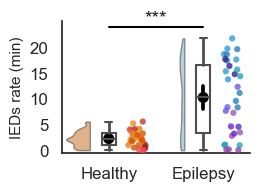

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt
import ptitprince as pt
from scipy.stats import ttest_ind

# סגנון
sns.set_context("notebook", font_scale=1.1)
sns.set_style("white")

# קריאת הנתונים
df = pd.read_csv('figures/V2.csv')
df['group'] = df['group'].replace({'HC': 'Healthy', 'EPI': 'Epilepsy'})

# הכנת הנתונים - לא צריך melt כי הנתונים כבר בפורמט הנכון
data_subset = df.copy()

# סדר הקבוצות
group_order = ['Healthy', 'Epilepsy']

# ציור
fig, ax = plt.subplots(figsize=(2.8, 2.1)) 

# Raincloud (without individual points)
pt.RainCloud(
    x='group',
    y='Spikes_per_min',
    data=data_subset,
    order=group_order,
    palette=['#e67e22', '#7fb3d3'],  # HC = orange, EPI = blue
    bw=.3,
    width_viol=.5,
    ax=ax,
    orient='v',
    move=0.2,
    alpha=0.6,
    pointplot=False,
    box_showfliers=False,
    point_size=0,  # This removes the individual points from RainCloud
)

# Get unique subjects for each group
hc_subjects = data_subset[data_subset['group'] == 'Healthy']['subject'].unique()
epi_subjects = data_subset[data_subset['group'] == 'Epilepsy']['subject'].unique()

# Create color palette
subject_colors = {}

# HC subjects - orange to red shades
hc_colors = [
    '#e88c1b',  # Original orange
    '#e67e22',  # Orange
    '#d35400',  # Dark orange
    '#e74c3c',  # Red
    '#c0392b',  # Dark red
    '#922b21',  # Darker red
    '#ff6b35',  # Orange-red
    '#ff4757',  # Light red
]

# Extend the list if we have more HC subjects than predefined colors
while len(hc_colors) < len(hc_subjects):
    hc_colors.extend(hc_colors)

for i, subject in enumerate(hc_subjects):
    subject_colors[subject] = hc_colors[i % len(hc_colors)]

# EPI subjects - blue to purple shades
epi_colors = [
    '#26a3b8',  # Original blue
    '#3498db',  # Light blue
    '#2980b9',  # Blue
    '#8e44ad',  # Purple
    '#9b59b6',  # Light purple
    '#6c5ce7',  # Blue-purple
    '#5f27cd',  # Dark purple
    '#341f97',  # Very dark purple
]

# Extend the list if we have more EPI subjects than predefined colors
while len(epi_colors) < len(epi_subjects):
    epi_colors.extend(epi_colors)

for i, subject in enumerate(epi_subjects):
    subject_colors[subject] = epi_colors[i % len(epi_colors)]

# Convert to list in the order seaborn expects
subject_palette = [subject_colors[subject] for subject in data_subset['subject'].unique()]

# Add individual points colored by subject (positioned to the right)
sns.stripplot(
    data=data_subset,
    x='group',
    y='Spikes_per_min',
    hue='subject',
    order=group_order,
    palette=subject_palette,
    ax=ax,
    size=4.5,
    alpha=0.8,
    jitter=0.1
)

# Get all collections created by stripplot (one for each subject)
stripplot_collections = ax.collections[2:]  # Skip the first 2 collections (violin and box)

# Move all points to the right of boxplots
for collection in stripplot_collections:
    if collection.get_offsets().size > 0:  # Check if collection has points
        offsets = collection.get_offsets()
        # Move points to the right: add 0.3 to all x-coordinates
        offsets[:, 0] = offsets[:, 0] + 0.3
        collection.set_offsets(offsets)

# Remove the legend (too many subjects for a useful legend)
ax.get_legend().remove()

# ממוצעים
sns.pointplot(
    data=data_subset,
    x='group',
    y='Spikes_per_min',
    order=group_order,
    color='black',
    join=False,
    markers='o',
    errorbar=None,
    scale=0.9,
    ax=ax
)

# סטטיסטיקה - השוואה בין HC ל-EPI
vals1 = data_subset[data_subset['group'] == 'Healthy']['Spikes_per_min']
vals2 = data_subset[data_subset['group'] == 'Epilepsy']['Spikes_per_min']
stat, pval = ttest_ind(vals1, vals2, equal_var=False)

# ציור כוכביות
y_max = data_subset['Spikes_per_min'].max()
y_line = y_max * 1.1  # גובה הקו
y_star = y_max * 1.1  # גובה הכוכבית

if pval < 0.001:
    star = '***'
elif pval < 0.01:
    star = '**'
elif pval < 0.05:
    star = '*'
else:
    star = 'ns'  # לא מובהק

# ציור הקו והכוכבית
if star != 'ns':
    ax.plot([0, 1], [y_line, y_line], color='black', linewidth=1.5)
    ax.text(0.5, y_star, star, ha='center', va='bottom', fontsize=14)

# עיצוב
ax.set_ylabel("IED rate (event/min)", fontsize=11)
ax.set_xlabel("")
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim(-0.5)
# set y ticks
ax.set_yticks([0, 5, 10, 15, 20])

plt.tight_layout()
fig.savefig("figures/V2.png", dpi=300, bbox_inches='tight', transparent=False)
plt.show()

In [94]:
import pandas as pd
import statsmodels.formula.api as smf
import numpy as np

# קריאת הנתונים
df = pd.read_csv('figures/V2.csv')
df['group'] = df['group'].replace({'HC': 'Healthy', 'EPI': 'Epilepsy'})

data_subset = df.copy()
data_subset['subject'] = data_subset['subject'].astype('category')
data_subset['group'] = data_subset['group'].astype('category')

# Healthy כקבוצת הבסיס
data_subset['group'] = data_subset['group'].cat.reorder_categories(['Healthy', 'Epilepsy'])

# מודל מעורב
model = smf.mixedlm("Spikes_per_min ~ group", 
                    data_subset, 
                    groups=data_subset["subject"])
result = model.fit()

print(result.summary())

# p-value
p_value = result.pvalues['group[T.Epilepsy]']
print(f"P-value for group effect: {p_value:.4f}")

# ---------- חישוב Cohen's d מותאם ----------
# הבדל הממוצעים המותאם מהמודל
mean_diff = result.params['group[T.Epilepsy]']

# השאריות מהמודל
residuals = data_subset['Spikes_per_min'] - result.fittedvalues

# סטיית תקן משולבת של השאריות
sd_pooled = residuals.std(ddof=1)

# Cohen's d
cohen_d = mean_diff / sd_pooled
print(f"Cohen's d (adjusted for repeated measures): {cohen_d:.3f}")


           Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Spikes_per_min
No. Observations: 64      Method:             REML          
No. Groups:       22      Scale:              1.7488        
Min. group size:  2       Log-Likelihood:     -146.5734     
Max. group size:  3       Converged:          Yes           
Mean group size:  2.9                                       
------------------------------------------------------------
                   Coef.  Std.Err.   z   P>|z| [0.025 0.975]
------------------------------------------------------------
Intercept           2.205    1.553 1.419 0.156 -0.839  5.249
group[T.Epilepsy]   8.202    2.196 3.734 0.000  3.898 12.507
Group Var          25.924    7.705                          

P-value for group effect: 0.0002
Cohen's d (adjusted for repeated measures): 7.555


In [ ]:
# handle colors
import pandas as pd
import json
import itertools

def build_subject_colors_for_file(csv_path, hc_colors, epi_colors, group_col='group', subj_col='subject'):
    df = pd.read_csv(csv_path)
    df[group_col] = df[group_col].replace({'HC':'Healthy', 'EPI':'Epilepsy'})
    hc_subjects = df[df[group_col]=='Healthy'][subj_col].unique()   # שמר על סדר הופעה
    epi_subjects = df[df[group_col]=='Epilepsy'][subj_col].unique()

    hc_cycle  = itertools.cycle(hc_colors)
    epi_cycle = itertools.cycle(epi_colors)

    out = {}
    for s in hc_subjects:
        if s not in out:
            out[s] = next(hc_cycle)
    for s in epi_subjects:
        if s not in out:
            out[s] = next(epi_cycle)
    return out

# ===== פלטות V1 (כמו בקוד שלך) =====
V1_HC = ['#E6F5A9','#D7F29B','#C8EF8D','#B6E67E','#A3DC71','#92D464','#7FCB58','#6FC34E','#60BA44','#52B23B']
V1_EPI = ['#D6ECFF','#C6E5FF','#B6DEFF','#A7D7FF','#97D0FF','#88C9FF','#78C2FF','#69BBFF','#59B4FF','#4AACFF']

# ===== פלטות V2 (כמו בקוד שלך) =====
V2_HC  = ['#4AAE35','#439F2F','#3C9129','#358323','#2F761E','#286819','#225B15','#1B4E11','#15420E','#0E350A','#082806']
V2_EPI = ['#3F8AE6','#397CD4','#336EC2','#2D60AF','#27529D','#21448B','#1B3779','#152966','#0F1B54','#0A1242','#050A31']

colors_V1 = build_subject_colors_for_file('figures/V1.csv', hc_colors=V1_HC, epi_colors=V1_EPI)
colors_V2 = build_subject_colors_for_file('figures/V2.csv', hc_colors=V2_HC,  epi_colors=V2_EPI)

# איחוד המילונים. אם במקרה אותו נבדק הופיע גם ב-V1 וגם ב-V2 (אמרת שחצי/חצי, אז כנראה שלא),
# ניתן להחליט מי גובר. כאן נותנים עדיפות לצבעים מ-V1:
subject_colors = {**colors_V2, **colors_V1}   # V1 overwrite V2 אם יש התנגשות

# שמירה ל-JSON לשימוש עתידי
with open('subject_colors.json', 'w') as f:
    json.dump(subject_colors, f, indent=2)


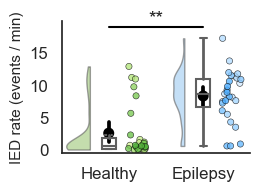

In [183]:
import seaborn as sns
import matplotlib.pyplot as plt
import ptitprince as pt
from scipy.stats import ttest_ind

# סגנון
sns.set_context("notebook", font_scale=1.1)
sns.set_style("white")

# קריאת הנתונים
df = pd.read_csv('figures/V1.csv')
df['group'] = df['group'].replace({'HC': 'Healthy', 'EPI': 'Epilepsy'})

# הכנת הנתונים - לא צריך melt כי הנתונים כבר בפורמט הנכון
data_subset = df.copy()

# סדר הקבוצות
group_order = ['Healthy', 'Epilepsy']

# ציור
fig, ax = plt.subplots(figsize=(2.8, 2.1))  # רוחב קטן יותר לשתי קבוצות

# Raincloud (without individual points)
pt.RainCloud(
    x='group',
    y='Spikes_per_min',
    data=data_subset,
    order=group_order,
    palette=['#9CD46A', '#90CCFF'],  # HC = orange, EPI = blue
    bw=.3,
    width_viol=0.5,
    ax=ax,
    orient='v',
    move=0.2,
    alpha=0.6,
    pointplot=False,
    box_showfliers=False,
    point_size=0,  # This removes the individual points from RainCloud
)

import json
with open('subject_colors.json', 'r') as f:
    subject_colors = json.load(f)

# חשוב: לקבע גם את סדר רמות ה-hue כדי ש-seaborn לא ינסה לסדר לבד
hue_order = sorted(data_subset['subject'].unique(), key=list(subject_colors.keys()).index)

# Add individual points colored by subject (positioned to the right)
sns.stripplot(
    data=data_subset,
    x='group',
    y='Spikes_per_min',
    hue='subject',
    order=group_order,
    palette=subject_colors,
    hue_order=hue_order,
    ax=ax,
    size=4.5,
    alpha=0.8,
    jitter=0.1,
    edgecolor="black", 
    linewidth=0.4
)

# Get all collections created by stripplot (one for each subject)
stripplot_collections = ax.collections[2:]  # Skip the first 2 collections (violin and box)

# Move all points to the right of boxplots
for collection in stripplot_collections:
    if collection.get_offsets().size > 0:  # Check if collection has points
        offsets = collection.get_offsets()
        # Move points to the right: add 0.3 to all x-coordinates
        offsets[:, 0] = offsets[:, 0] + 0.3
        collection.set_offsets(offsets)

# Remove the legend (too many subjects for a useful legend)
ax.get_legend().remove()

# ממוצעים
sns.pointplot(
    data=data_subset,
    x='group',
    y='Spikes_per_min',
    order=group_order,
    color='black',
    join=False,
    markers='o',
    errorbar=None,
    scale=0.9,
    ax=ax
)

# סטטיסטיקה - השוואה בין HC ל-EPI
vals1 = data_subset[data_subset['group'] == 'Healthy']['Spikes_per_min']
vals2 = data_subset[data_subset['group'] == 'Epilepsy']['Spikes_per_min']
# stat, pval = ttest_ind(vals1, vals2, equal_var=False)

# ציור כוכביות
y_max = data_subset['Spikes_per_min'].max()
y_line = y_max * 1.1  # גובה הקו
y_star = y_max * 1.1  # גובה הכוכבית

# ציור הקו והכוכבית
star = '**'
ax.plot([0, 1], [y_line, y_line], color='black', linewidth=1.5)
ax.text(0.5, y_star, star, ha='center', va='bottom', fontsize=14)

# עיצוב
ax.set_ylabel("IED rate (events / min)", fontsize=11)
ax.set_xlabel("")
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim(bottom=-0.5)
ax.set_yticks([0, 5, 10, 15])

plt.tight_layout()
# fig.savefig("figures/V1_green.png", dpi=300, bbox_inches='tight', transparent=False)
plt.show()

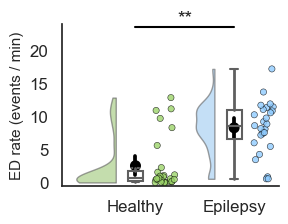

In [206]:
# same colors
import seaborn as sns
import matplotlib.pyplot as plt
import ptitprince as pt
import pandas as pd
from scipy.stats import ttest_ind

# ---------------- Style ----------------
sns.set_context("notebook", font_scale=1.1)
sns.set_style("white")

# ---------------- Data -----------------
df = pd.read_csv('figures/V1.csv')
df['group'] = df['group'].replace({'HC': 'Healthy', 'EPI': 'Epilepsy'})
data_subset = df.copy()

group_order = ['Healthy', 'Epilepsy']
group_palette = {'Healthy': '#9CD46A', 'Epilepsy': '#90CCFF'}  # same colors as violins

# ---------------- Plot -----------------
fig, ax = plt.subplots(figsize=(2.8, 2.1))

# RainCloud (no individual points drawn by ptitprince)
width_viol = 0.8    # your original width
move = 0.2          # your original move (half-violin shifts right a bit)

pt.RainCloud(
    x='group',
    y='Spikes_per_min',
    data=data_subset,
    order=group_order,
    palette=[group_palette[g] for g in group_order],
    bw=.3,
    width_viol=width_viol,
    ax=ax,
    orient='v',
    move=move,
    alpha=0.6,
    pointplot=False,
    box_showfliers=False,
    point_size=0,
)

# --- Individual points: match violin colors (hue by group) ---
pre_n = len(ax.collections)  # remember current collections before stripplot
sns.stripplot(
    data=data_subset,
    x='group',
    y='Spikes_per_min',
    hue='group',
    order=group_order,
    palette=group_palette,
    dodge=False,          # centered on each category
    ax=ax,
    size=4.5,
    alpha=0.8,
    jitter=0.1,
    edgecolor="black",
    linewidth=0.4,
)

# Move the dots a bit to the right of the box/violin (for visibility)
point_shift = 0.30
new_cols = ax.collections[pre_n:]  # only the collections created by stripplot
for col in new_cols:
    offs = col.get_offsets()
    if offs.size > 0:
        offs[:, 0] = offs[:, 0] + point_shift
        col.set_offsets(offs)

# ---------------- Means ----------------
sns.pointplot(
    data=data_subset,
    x='group',
    y='Spikes_per_min',
    order=group_order,
    color='black',
    join=False,
    markers='o',
    errorbar=None,
    scale=0.9,
    ax=ax
)

# ---------------- Significance (static demo) ----------------
y_max = data_subset['Spikes_per_min'].max()
y_line = y_max * 1.1
y_star = y_max * 1.1
ax.plot([0, 1], [23.5, 23.5], color='black', linewidth=1.5)
ax.text(0.5, 23.5, '**', ha='center', va='bottom', fontsize=14)

# ---------------- Axes & Layout ----------------
ax.set_ylabel("ED rate (events / min)", fontsize=11)
ax.set_xlabel("")
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim(-0.5, 24)
ax.set_yticks([0, 5, 10, 15, 20])
ax.get_legend().remove()

# Prevent the left violin from being clipped by the y-axis
# Leftmost extent of the first (x=0) half-violin is: 0 + move - width_viol
left_extent  = 0 + move - width_viol
# Rightmost extent needs to allow for the shifted dots on the second group (x=1)
right_extent = 1 + point_shift
pad = 0.15  # small extra slack
ax.set_xlim(left_extent - pad, right_extent + pad)

# plt.tight_layout()
plt.show()


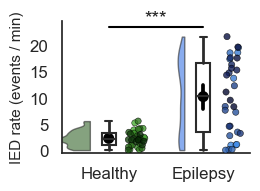

In [204]:
import seaborn as sns
import matplotlib.pyplot as plt
import ptitprince as pt
from scipy.stats import ttest_ind
import json

# סגנון
sns.set_context("notebook", font_scale=1.1)
sns.set_style("white")

# קריאת הנתונים
df = pd.read_csv('figures/V2.csv')
df['group'] = df['group'].replace({'HC': 'Healthy', 'EPI': 'Epilepsy'})

# הכנת הנתונים - לא צריך melt כי הנתונים כבר בפורמט הנכון
data_subset = df.copy()

# סדר הקבוצות
group_order = ['Healthy', 'Epilepsy']

# ציור
fig, ax = plt.subplots(figsize=(2.8, 2.1)) 

# Raincloud (without individual points)
pt.RainCloud(
    x='group',
    y='Spikes_per_min',
    data=data_subset,
    order=group_order,
    palette=['#2E6F20', '#1E6EFF'],  # HC = green, EPI = blue
    bw=.3,
    # width_viol=.8,
    ax=ax,
    orient='v',
    move=0.2,
    alpha=0.6,
    pointplot=False,
    box_showfliers=False,
    point_size=0,  # This removes the individual points from RainCloud
)

with open('subject_colors.json', 'r') as f:
    subject_colors = json.load(f)

# חשוב: לקבע גם את סדר רמות ה-hue כדי ש-seaborn לא ינסה לסדר לבד
hue_order = sorted(data_subset['subject'].unique(), key=list(subject_colors.keys()).index)

# Add individual points colored by subject (positioned to the right)
sns.stripplot(
    data=data_subset,
    x='group',
    y='Spikes_per_min',
    hue='subject',
    order=group_order,
    hue_order=hue_order,
    palette=subject_colors, 
    ax=ax,
    size=4.5,
    alpha=0.8,
    jitter=0.1,
    edgecolor="black", 
    linewidth=0.4
)

# Get all collections created by stripplot (one for each subject)
stripplot_collections = ax.collections[2:]  # Skip the first 2 collections (violin and box)

# Move all points to the right of boxplots
for collection in stripplot_collections:
    if collection.get_offsets().size > 0:  # Check if collection has points
        offsets = collection.get_offsets()
        # Move points to the right: add 0.3 to all x-coordinates
        offsets[:, 0] = offsets[:, 0] + 0.3
        collection.set_offsets(offsets)

# Remove the legend (too many subjects for a useful legend)
ax.get_legend().remove()

# ממוצעים
sns.pointplot(
    data=data_subset,
    x='group',
    y='Spikes_per_min',
    order=group_order,
    color='black',
    join=False,
    markers='o',
    errorbar=None,
    scale=0.9,
    ax=ax
)

# סטטיסטיקה - השוואה בין HC ל-EPI
vals1 = data_subset[data_subset['group'] == 'Healthy']['Spikes_per_min']
vals2 = data_subset[data_subset['group'] == 'Epilepsy']['Spikes_per_min']
stat, pval = ttest_ind(vals1, vals2, equal_var=False)

# ציור כוכביות
y_max = data_subset['Spikes_per_min'].max()
y_line = y_max * 1.1  # גובה הקו
y_star = y_max * 1.1  # גובה הכוכבית

if pval < 0.001:
    star = '***'
elif pval < 0.01:
    star = '**'
elif pval < 0.05:
    star = '*'
else:
    star = 'ns'  # לא מובהק

# ציור הקו והכוכבית
if star != 'ns':
    ax.plot([0, 1], [23.5, 23.5], color='black', linewidth=1.5)
    ax.text(0.5, 23.5, star, ha='center', va='bottom', fontsize=14)

# עיצוב
ax.set_ylabel("IED rate (events / min)", fontsize=11)
ax.set_xlabel("")
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim(-0.5)
# set y ticks
ax.set_yticks([0, 5, 10, 15, 20])

plt.tight_layout()
# fig.savefig("figures/V2_green.png", dpi=300, bbox_inches='tight', transparent=False)
plt.show()

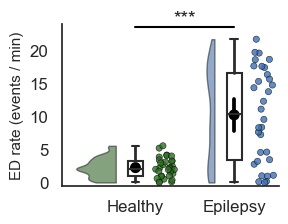

In [205]:
# same colors
import seaborn as sns
import matplotlib.pyplot as plt
import ptitprince as pt
import pandas as pd
from scipy.stats import ttest_ind

# ---------------- Style ----------------
sns.set_context("notebook", font_scale=1.1)
sns.set_style("white")

# ---------------- Data -----------------
df = pd.read_csv('figures/V2.csv')
df['group'] = df['group'].replace({'HC': 'Healthy', 'EPI': 'Epilepsy'})
data_subset = df.copy()

group_order = ['Healthy', 'Epilepsy']
group_palette = {'Healthy': '#2E6F20', 'Epilepsy': '#3870bb'}  # same colors as violins

# ---------------- Plot -----------------
fig, ax = plt.subplots(figsize=(2.8, 2.1))

# RainCloud (no individual points drawn by ptitprince)
width_viol = 0.8    # your original width
move = 0.2          # your original move (half-violin shifts right a bit)

pt.RainCloud(
    x='group',
    y='Spikes_per_min',
    data=data_subset,
    order=group_order,
    palette=[group_palette[g] for g in group_order],
    bw=.3,
    width_viol=width_viol,
    ax=ax,
    orient='v',
    move=move,
    alpha=0.6,
    pointplot=False,
    box_showfliers=False,
    point_size=0,
)

# --- Individual points: match violin colors (hue by group) ---
pre_n = len(ax.collections)  # remember current collections before stripplot
sns.stripplot(
    data=data_subset,
    x='group',
    y='Spikes_per_min',
    hue='group',
    order=group_order,
    palette=group_palette,
    dodge=False,          # centered on each category
    ax=ax,
    size=4.5,
    alpha=0.8,
    jitter=0.1,
    edgecolor="black",
    linewidth=0.4,
)

# Move the dots a bit to the right of the box/violin (for visibility)
point_shift = 0.30
new_cols = ax.collections[pre_n:]  # only the collections created by stripplot
for col in new_cols:
    offs = col.get_offsets()
    if offs.size > 0:
        offs[:, 0] = offs[:, 0] + point_shift
        col.set_offsets(offs)

# ---------------- Means ----------------
sns.pointplot(
    data=data_subset,
    x='group',
    y='Spikes_per_min',
    order=group_order,
    color='black',
    join=False,
    markers='o',
    errorbar=None,
    scale=0.9,
    ax=ax
)

# ---------------- Significance (static demo) ----------------
y_max = data_subset['Spikes_per_min'].max()
y_line = y_max * 1.1
y_star = y_max * 1.1
ax.plot([0, 1], [23.5, 23.5], color='black', linewidth=1.5)
ax.text(0.5, 23.5, '***', ha='center', va='bottom', fontsize=14)

# ---------------- Axes & Layout ----------------
ax.set_ylabel("ED rate (events / min)", fontsize=11)
ax.set_xlabel("")
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim(-0.5, 24)
ax.set_yticks([0, 5, 10, 15, 20])
ax.get_legend().remove()

# Prevent the left violin from being clipped by the y-axis
# Leftmost extent of the first (x=0) half-violin is: 0 + move - width_viol
left_extent  = 0 + move - width_viol
# Rightmost extent needs to allow for the shifted dots on the second group (x=1)
right_extent = 1 + point_shift
pad = 0.15  # small extra slack
ax.set_xlim(left_extent - pad, right_extent + pad)

# plt.tight_layout()
plt.show()

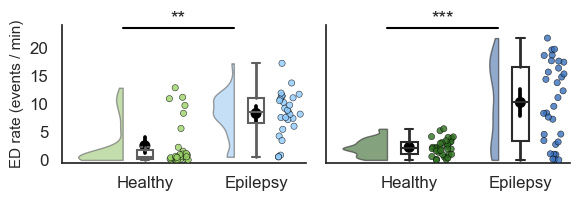

In [214]:
import seaborn as sns
import matplotlib.pyplot as plt
import ptitprince as pt
import pandas as pd

# ---------- Shared style ----------
sns.set_context("notebook", font_scale=1.1)
sns.set_style("white")

# ---------- Small helper to draw one panel ----------
def draw_panel(ax, csv_path, palette_dict, star_text):
    # Params that control geometry
    width_viol = 0.8
    move = 0.2
    point_shift = 0.30
    pad = 0.15

    # Data
    df = pd.read_csv(csv_path)
    df['group'] = df['group'].replace({'HC': 'Healthy', 'EPI': 'Epilepsy'})
    data_subset = df.copy()

    group_order = ['Healthy', 'Epilepsy']
    palette_list = [palette_dict[g] for g in group_order]

    # RainCloud (no points drawn by ptitprince)
    pt.RainCloud(
        x='group', y='Spikes_per_min',
        data=data_subset, order=group_order,
        palette=palette_list, bw=.3,
        width_viol=width_viol, ax=ax, orient='v',
        move=move, alpha=0.6,
        pointplot=False, box_showfliers=False,
        point_size=0,
    )

    # Individual points (colored to match violins)
    pre_n = len(ax.collections)
    sns.stripplot(
        data=data_subset, x='group', y='Spikes_per_min',
        hue='group', order=group_order,
        palette=palette_dict, dodge=False,
        ax=ax, size=4.5, alpha=0.8, jitter=0.1,
        edgecolor="black", linewidth=0.4
    )
    # Shift dots slightly right for visibility
    new_cols = ax.collections[pre_n:]
    for col in new_cols:
        offs = col.get_offsets()
        if offs.size > 0:
            offs[:, 0] = offs[:, 0] + point_shift
            col.set_offsets(offs)

    # Group means
    sns.pointplot(
        data=data_subset, x='group', y='Spikes_per_min',
        order=group_order, color='black',
        join=False, markers='o', errorbar=None, scale=0.9, ax=ax
    )

    # Significance line/text (static)
    ax.plot([-0.2, 0.8], [23.5, 23.5], color='black', linewidth=1.5)
    ax.text(0.3, 23.5, star_text, ha='center', va='bottom', fontsize=14)

    # Axes cosmetics
    ax.set_xlabel("")
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_ylim(-0.5, 24)
    ax.set_yticks([0, 5, 10, 15, 20])

    # Prevent left violin from being clipped (computed xlim)
    left_extent  = 0 + move - width_viol   # -0.6 with current params
    right_extent = 1 + point_shift         # ~1.30
    ax.set_xlim(left_extent - pad, right_extent + pad)

    return ax

# ---------- Figure with two side-by-side panels ----------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6.0, 2.2), sharey=True)

# Left panel: V1
palette_v1 = {'Healthy': '#9CD46A', 'Epilepsy': '#90CCFF'}
draw_panel(ax1, 'figures/V1.csv', palette_v1, star_text='**')
ax1.set_ylabel("ED rate (events / min)", fontsize=11)
ax1.get_legend().remove()

# Right panel: V2
palette_v2 = {'Healthy': '#2E6F20', 'Epilepsy': '#3870bb'}
draw_panel(ax2, 'figures/V2.csv', palette_v2, star_text='***')
ax2.set_ylabel("")  # sharey=True keeps ticks; no duplicate label
ax2.get_legend().remove()

plt.tight_layout()

# ---------- Save as PDF ----------
plt.savefig("figures/V1_V2_side_by_side.pdf", dpi=600, bbox_inches='tight', transparent=False)
plt.show()


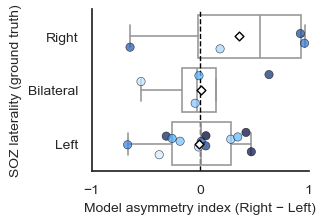

In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import json

# --- טוענים נתונים + צבעים קבועים ---
df = pd.read_csv('figures/laterality.csv')  # חשוב שתהיה עמודה 'subject'
with open('subject_colors.json', 'r') as f:
    subject_colors = json.load(f)

DEFAULT_COLOR = "#BFBFBF"

# נבדקים בגרף
subjects_in_plot = df['subject'].unique()

# בונים מילון צבעים לגרף + הדפסות אם חסרים
palette_for_plot = {}
for s in subjects_in_plot:
    if s in subject_colors:
        palette_for_plot[s] = subject_colors[s]
    else:
        print(f"⚠️ נבדק {s} לא נמצא ב-subject_colors.json – ניתן לו צבע ברירת מחדל ({DEFAULT_COLOR})")
        palette_for_plot[s] = DEFAULT_COLOR

# hue_order יציב: קודם לפי סדר subject_colors, אחר כך מי שלא נמצא
known_order = [s for s in subject_colors.keys() if s in subjects_in_plot]
unknown_order = [s for s in subjects_in_plot if s not in subject_colors]
hue_order = known_order + unknown_order

# --- ציור ---
categories = ['Right', 'Bilateral', 'Left']
plt.figure(figsize=(2.8, 2.1))

sns.boxplot(
    data=df,
    y='Zone Category', x='Asymmetry Index',
    order=categories,
    color='white', linewidth=1.2, showcaps=True, fliersize=0
)

sns.stripplot(
    data=df,
    y='Zone Category', x='Asymmetry Index',
    order=categories,
    hue='subject',
    hue_order=hue_order,
    palette=palette_for_plot,
    alpha=0.75, size=6, jitter=0.3, dodge=False,
    edgecolor='black', linewidth=0.4
)

# ממוצעים (יהלומים לבנים)
group_means = df.groupby('Zone Category')['Asymmetry Index'].mean()
for i, category in enumerate(categories):
    mean_x = group_means.get(category, float('nan'))
    plt.scatter(mean_x, i, color='white', edgecolor='black', marker='D', s=20, zorder=5)

plt.axvline(0, color='black', linestyle='--', linewidth=1)

plt.xlabel('Model asymmetry index (Right − Left)', fontsize=10)
plt.ylabel('SOZ laterality (ground truth)', fontsize=10)
plt.xlim(-1, 1)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.legend([],[], frameon=False)
plt.grid(False)
sns.despine(top=True, right=True)
#save
plt.savefig('figures/laterality_colored.png', dpi=300, bbox_inches='tight', transparent=False)

plt.show()


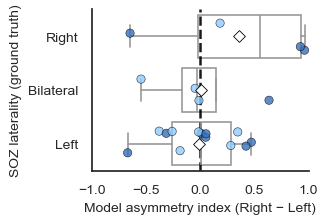

In [220]:
# 2 colors
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- סגנון ---
sns.set_context("notebook", font_scale=1.1)
sns.set_style("white")

# --- נתונים לגרף הנוכחי ---
df = pd.read_csv('figures/laterality.csv')  # חייב עמודות: subject, Zone Category, Asymmetry Index
df['subject'] = df['subject'].astype(str).str.strip()

# --- מיפוי נבדק -> קוהורט (V1/V2) לפי הקבצים מהגרפים הקודמים ---
v1 = pd.read_csv('figures/V1.csv')
v2 = pd.read_csv('figures/V2.csv')
v1['subject'] = v1['subject'].astype(str).str.strip()
v2['subject'] = v2['subject'].astype(str).str.strip()

v1_subjects = set(v1['subject'].unique())
v2_subjects = set(v2['subject'].unique())

def cohort_of(subj):
    in_v1 = subj in v1_subjects
    in_v2 = subj in v2_subjects
    if in_v1 and not in_v2:
        return 'V1'
    if in_v2 and not in_v1:
        return 'V2'
    if in_v1 and in_v2:
        # אם נבדק מופיע בשניהם – נותנים עדיפות ל-V2 (אפשר לשנות ל'V1' אם תרצה)
        return 'V2'
    return 'Unknown'

df['cohort'] = df['subject'].map(cohort_of)

# --- צבעים: V1 בהיר (כמו בגרף הראשון), V2 כחול כהה (כמו בגרף השני) ---
palette_cohort = {
    'V1': '#90CCFF',     # ירקרק בהיר של V1
    'V2': '#3870bb',     # כחול כהה של V2
}
hue_order = ['V1', 'V2', 'Unknown'] if 'Unknown' in df['cohort'].unique() else ['V1', 'V2']

# --- קטגוריות על הציר האנכי ---
categories = ['Right', 'Bilateral', 'Left']

# --- ציור ---
fig, ax = plt.subplots(figsize=(2.8, 2.1))

sns.boxplot(
    data=df,
    y='Zone Category', x='Asymmetry Index',
    order=categories,
    color='white', linewidth=1.2, showcaps=True, fliersize=0, ax=ax
)

sns.stripplot(
    data=df,
    y='Zone Category', x='Asymmetry Index',
    order=categories,
    hue='cohort', hue_order=hue_order,
    palette=palette_cohort,
    alpha=0.80, size=6, jitter=0.30, dodge=False,
    edgecolor='black', linewidth=0.4, ax=ax
)

# --- ממוצעים (יהלומים מעט גדולים יותר) ---
group_means = df.groupby('Zone Category')['Asymmetry Index'].mean()
for i, category in enumerate(categories):
    mean_x = group_means.get(category, float('nan'))
    ax.scatter(mean_x, i, color='white', edgecolor='black',
               marker='D', s=36, linewidth=0.6, zorder=5)

# --- קו 0 מודגש יותר ---
ax.axvline(0, color='black', linestyle='--', linewidth=1.8, alpha=0.9)

# --- עיצוב ---
ax.set_xlabel('Model asymmetry index (Right − Left)', fontsize=10)
ax.set_ylabel('SOZ laterality (ground truth)', fontsize=10)
ax.set_xlim(-1, 1)
ax.set_xticks([-1, -0.5, 0, 0.5, 1.0])
ax.tick_params(labelsize=10)
ax.grid(False)
sns.despine(ax=ax, top=True, right=True)
ax.get_legend().remove()



# --- שמירה כ-PNG וכ-PDF ---
plt.savefig("figures/laterality_2color.pdf", dpi=600, bbox_inches='tight', transparent=False)
plt.show()


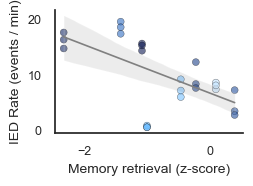

In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import json

# --- קריאת נתונים ---
spikes_df = pd.read_csv('figures/V1_V2_combined.csv')   # כולל 'subject', 'Spikes_per_min', 'part'
cog_df    = pd.read_csv('figures/EPI_Corr.csv', encoding='cp1255')

# ודא שהמזהים נקיים
spikes_df['subject'] = spikes_df['subject'].astype(str).str.strip()
cog_df['subject']    = cog_df['subject'].astype(str).str.strip()

# חיבור הקבצים
var = 'יעילות שליפת המידע'
merged_df = pd.merge(
    spikes_df,
    cog_df[['subject', var]],
    on='subject',
    how='inner'
)

# --- טעינת צבעים קבועים ---
with open('subject_colors.json', 'r') as f:
    subject_colors = json.load(f)

DEFAULT_COLOR = "#BFBFBF"  # צבע ברירת מחדל לנבדקים שלא במילון

# בנה פלטה לגרף והדפס אזהרות על חסרים
subjects_in_plot = merged_df['subject'].unique()
palette_for_plot = {}
for s in subjects_in_plot:
    if s in subject_colors:
        palette_for_plot[s] = subject_colors[s]
    else:
        print(f"⚠️ נבדק {s} לא נמצא ב-subject_colors.json – ניתן לו צבע ברירת מחדל ({DEFAULT_COLOR})")
        palette_for_plot[s] = DEFAULT_COLOR

# סדר עקבי של hue: קודם לפי סדר המילון הראשי, אחר כך הלא־מוכרים
known_order   = [s for s in subject_colors.keys() if s in subjects_in_plot]
unknown_order = [s for s in subjects_in_plot if s not in subject_colors]
hue_order = known_order + unknown_order

# --- ציור ---
plt.figure(figsize=(2.8, 2.13))

# נקודות צבועות לפי subject
sns.scatterplot(
    data=merged_df,
    x=var, y='Spikes_per_min',
    hue='subject',
    hue_order=hue_order,
    palette=palette_for_plot,
    s=25, alpha=0.6,
    edgecolor='black', linewidth=0.3,
    legend=False  # בד"כ יש יותר מדי נבדקים למקרא שימושי
)

# קו רגרסיה (ללא נקודות)
sns.regplot(
    data=merged_df,
    x=var, y='Spikes_per_min',
    scatter=False,
    line_kws={'color': 'gray', 'linewidth': 1.2}
)

# עיצוב
plt.xlabel('Memory retrieval (z-score)', fontsize=10)
plt.ylabel('IED Rate (events / min)', fontsize=10)
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
sns.despine(top=True, right=True)
plt.tight_layout()

# שמירה (אופציונלי)
plt.savefig('figures/epi_corr_colored.png', dpi=300, bbox_inches='tight', transparent=False)

plt.show()


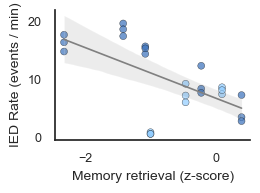

In [226]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import json

# --- קריאת נתונים ---
spikes_df = pd.read_csv('figures/V1_V2_combined.csv')   # כולל 'subject', 'Spikes_per_min', 'part'
cog_df    = pd.read_csv('figures/EPI_Corr.csv', encoding='cp1255')

# ודא שהמזהים נקיים
spikes_df['subject'] = spikes_df['subject'].astype(str).str.strip()
cog_df['subject']    = cog_df['subject'].astype(str).str.strip()

# חיבור הקבצים
var = 'יעילות שליפת המידע'
merged_df = pd.merge(
    spikes_df,
    cog_df[['subject', var]],
    on='subject',
    how='inner'
)

# --- מיפוי נבדק -> קוהורט (V1/V2) כמו בקוד השני ---
v1 = pd.read_csv('figures/V1.csv')
v2 = pd.read_csv('figures/V2.csv')
v1['subject'] = v1['subject'].astype(str).str.strip()
v2['subject'] = v2['subject'].astype(str).str.strip()

v1_subjects = set(v1['subject'].unique())
v2_subjects = set(v2['subject'].unique())

def cohort_of(subj):
    in_v1 = subj in v1_subjects
    in_v2 = subj in v2_subjects
    if in_v1 and not in_v2:
        return 'V1'
    if in_v2 and not in_v1:
        return 'V2'
    if in_v1 and in_v2:
        # עדיפות ל-V2 (כמו בדוגמה שלך)
        return 'V2'
    return 'Unknown'

merged_df['cohort'] = merged_df['subject'].map(cohort_of)

# --- צבעים לפי קוהורט ---
palette_cohort = {
    'V1': '#90CCFF',    # תכלת (כמו בגרף V1)
    'V2': '#3870bb',    # כחול כהה (כמו בגרף V2)
    'Unknown': '#BFBFBF'
}
hue_levels = ['V1', 'V2'] + (['Unknown'] if 'Unknown' in merged_df['cohort'].unique() else [])

# --- ציור ---
plt.figure(figsize=(2.8, 2.13))

# נקודות צבועות לפי קוהורט
sns.scatterplot(
    data=merged_df,
    x=var, y='Spikes_per_min',
    hue='cohort', hue_order=hue_levels,
    palette=palette_cohort,
    s=25, alpha=0.7,
    edgecolor='black', linewidth=0.3, legend=False
)

# קו רגרסיה (ללא נקודות)
sns.regplot(
    data=merged_df,
    x=var, y='Spikes_per_min',
    scatter=False,
    line_kws={'color': 'gray', 'linewidth': 1.2}
)

# עיצוב
plt.xlabel('Memory retrieval (z-score)', fontsize=10)
plt.ylabel('IED Rate (events / min)', fontsize=10)
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
sns.despine(top=True, right=True)
plt.tight_layout()

# שמירה (אופציונלי)
# plt.savefig('figures/epi_corr_colored_by_cohort.png', dpi=300, bbox_inches='tight', transparent=False)
plt.show()


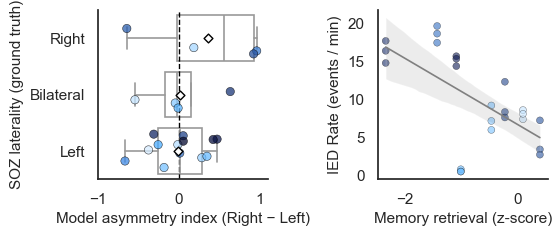

In [39]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import json

# ======================
# הגדרות כלליות
# ======================
DEFAULT_COLOR = "#BFBFBF"  # צבע ברירת מחדל למי שלא נמצא במילון
categories = ['Right', 'Bilateral', 'Left']  # סדר קטגוריות ל-laterality
cog_var = 'יעילות שליפת המידע'               # שם המשתנה הקוגניטיבי בקובץ

# ======================
# קריאת נתונים + צבעים
# ======================
# laterality
lat_df = pd.read_csv('figures/laterality.csv')           # חייב 'subject', 'Zone Category', 'Asymmetry Index'
# קורלציה
spikes_df = pd.read_csv('figures/V1_V2_combined.csv')    # כולל 'subject', 'Spikes_per_min', 'part'
cog_df    = pd.read_csv('figures/EPI_Corr.csv', encoding='cp1255')

# ניקוי מזהים
lat_df['subject']    = lat_df['subject'].astype(str).str.strip()
spikes_df['subject'] = spikes_df['subject'].astype(str).str.strip()
cog_df['subject']    = cog_df['subject'].astype(str).str.strip()

# מיזוג לקורלציה
merged_df = pd.merge(spikes_df, cog_df[['subject', cog_var]], on='subject', how='inner')

# טוענים מילון צבעים קבוע
with open('subject_colors.json', 'r') as f:
    subject_colors = json.load(f)

# ======================
# פונקציה לבניית פלטה+סדר hue עם הודעות אזהרה
# ======================
def build_palette_and_order(subject_series, subject_colors, default_color=DEFAULT_COLOR):
    subjects = subject_series.unique()
    palette = {}
    missing = []
    for s in subjects:
        if s in subject_colors:
            palette[s] = subject_colors[s]
        else:
            palette[s] = default_color
            missing.append(s)
    # hue_order: קודם לפי סדר המילון הראשי, אח"כ הלא-מוכרים
    known_order   = [s for s in subject_colors.keys() if s in subjects]
    unknown_order = [s for s in subjects if s not in subject_colors]
    hue_order = known_order + unknown_order
    # הדפסות
    for s in missing:
        print(f"⚠️ נבדק {s} לא נמצא ב-subject_colors.json – ניתן לו צבע ברירת מחדל ({default_color})")
    return palette, hue_order

# פלטות לכל פאנל
lat_palette, lat_hue_order   = build_palette_and_order(lat_df['subject'], subject_colors)
corr_palette, corr_hue_order = build_palette_and_order(merged_df['subject'], subject_colors)

# ======================
# ציור פיגורה כפולה
# ======================
sns.set_context("notebook", font_scale=1.0)
sns.set_style("white")

fig, (ax1, ax2) = plt.subplots(
    ncols=2, figsize=(5.8, 2.2),  # שני פאנלים קומפקטיים
    gridspec_kw={'wspace': 0.65}
)

# ---- פאנל שמאל: Laterality ----
sns.boxplot(
    data=lat_df,
    y='Zone Category', x='Asymmetry Index',
    order=categories,
    color='white', linewidth=1.2, showcaps=True, fliersize=0,
    ax=ax1
)

sns.stripplot(
    data=lat_df,
    y='Zone Category', x='Asymmetry Index',
    order=categories,
    hue='subject',
    hue_order=lat_hue_order,
    palette=lat_palette,
    alpha=0.75, size=6, jitter=0.3, dodge=False,
    edgecolor='black', linewidth=0.4,
    ax=ax1
)

# ממוצעים (יהלומים לבנים)
group_means = lat_df.groupby('Zone Category')['Asymmetry Index'].mean()
for i, cat in enumerate(categories):
    mean_x = group_means.get(cat, np.nan)
    ax1.scatter(mean_x, i, color='white', edgecolor='black', marker='D', s=20, zorder=5)

# קו אנכי ב-x=0
ax1.axvline(0, color='black', linestyle='--', linewidth=1)

# עיצוב שמאל
ax1.set_xlabel('Model asymmetry index (Right − Left)', fontsize=11)
ax1.set_ylabel('SOZ laterality (ground truth)', fontsize=11)
ax1.set_xlim(-1, 1.1)
ax1.tick_params(labelsize=11)
ax1.grid(False)
sns.despine(ax=ax1, top=True, right=True)
# כיבוי מקרא אם קפץ בכל זאת
leg1 = ax1.get_legend()
if leg1 is not None:
    leg1.remove()

# ---- פאנל ימין: קורלציה ----
# נקודות צבועות לפי subject
sns.scatterplot(
    data=merged_df,
    x=cog_var, y='Spikes_per_min',
    hue='subject',
    hue_order=corr_hue_order,
    palette=corr_palette,
    s=25, alpha=0.6,
    edgecolor='black', linewidth=0.3,
    ax=ax2, legend=False
)

# קו רגרסיה (ללא נקודות)
sns.regplot(
    data=merged_df,
    x=cog_var, y='Spikes_per_min',
    scatter=False,
    line_kws={'color': 'gray', 'linewidth': 1.2},
    ax=ax2
)

# עיצוב ימין
ax2.set_xlabel('Memory retrieval (z-score)', fontsize=11)
ax2.set_ylabel('IED Rate (events / min)', fontsize=11)
ax2.tick_params(labelsize=11)
sns.despine(ax=ax2, top=True, right=True)

# סידור ושמירה
# plt.tight_layout()
# שמירה לקובץ מאוחד
plt.savefig('figures/combined_laterality_corr.png', dpi=300, bbox_inches='tight', transparent=False)
plt.show()


⚠️ נבדק D13 לא נמצא ב-subject_colors.json – ניתן לו צבע ברירת מחדל (#BFBFBF)
⚠️ נבדק D18 לא נמצא ב-subject_colors.json – ניתן לו צבע ברירת מחדל (#BFBFBF)
⚠️ נבדק D38 לא נמצא ב-subject_colors.json – ניתן לו צבע ברירת מחדל (#BFBFBF)
⚠️ נבדק D39 לא נמצא ב-subject_colors.json – ניתן לו צבע ברירת מחדל (#BFBFBF)


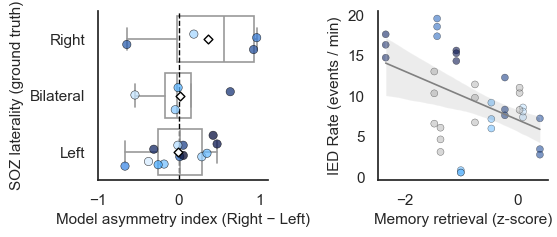

In [248]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import json

# ======================
# הגדרות כלליות
# ======================
DEFAULT_COLOR = "#BFBFBF"  # צבע ברירת מחדל למי שלא נמצא במילון
categories = ['Right', 'Bilateral', 'Left']  # סדר קטגוריות ל-laterality
cog_var = 'יעילות שליפת המידע'               # שם המשתנה הקוגניטיבי בקובץ

# ======================
# קריאת נתונים + צבעים
# ======================
# laterality
lat_df = pd.read_csv('figures/laterality.csv')           # חייב 'subject', 'Zone Category', 'Asymmetry Index'
# קורלציה
spikes_df = pd.read_csv('figures/V1_V2_combined_with_depth.csv')
cog_df = pd.read_csv('figures/EPI_Corr_with_depth.csv', encoding='cp1255')

# ניקוי מזהים
lat_df['subject']    = lat_df['subject'].astype(str).str.strip()
spikes_df['subject'] = spikes_df['subject'].astype(str).str.strip()
cog_df['subject']    = cog_df['subject'].astype(str).str.strip()

# מיזוג לקורלציה
merged_df = pd.merge(spikes_df, cog_df[['subject', cog_var]], on='subject', how='inner')

# טוענים מילון צבעים קבוע
with open('subject_colors.json', 'r') as f:
    subject_colors = json.load(f)

# ======================
# פונקציה לבניית פלטה+סדר hue עם הודעות אזהרה
# ======================
def build_palette_and_order(subject_series, subject_colors, default_color=DEFAULT_COLOR):
    subjects = subject_series.unique()
    palette = {}
    missing = []
    for s in subjects:
        if s in subject_colors:
            palette[s] = subject_colors[s]
        else:
            palette[s] = default_color
            missing.append(s)
    # hue_order: קודם לפי סדר המילון הראשי, אח"כ הלא-מוכרים
    known_order   = [s for s in subject_colors.keys() if s in subjects]
    unknown_order = [s for s in subjects if s not in subject_colors]
    hue_order = known_order + unknown_order
    # הדפסות
    for s in missing:
        print(f"⚠️ נבדק {s} לא נמצא ב-subject_colors.json – ניתן לו צבע ברירת מחדל ({default_color})")
    return palette, hue_order

# פלטות לכל פאנל
lat_palette, lat_hue_order   = build_palette_and_order(lat_df['subject'], subject_colors)
corr_palette, corr_hue_order = build_palette_and_order(merged_df['subject'], subject_colors)

# ======================
# ציור פיגורה כפולה
# ======================
sns.set_context("notebook", font_scale=1.0)
sns.set_style("white")

fig, (ax1, ax2) = plt.subplots(
    ncols=2, figsize=(5.8, 2.2),  # שני פאנלים קומפקטיים
    gridspec_kw={'wspace': 0.65}
)

# ---- פאנל שמאל: Laterality ----
sns.boxplot(
    data=lat_df,
    y='Zone Category', x='Asymmetry Index',
    order=categories,
    color='white', linewidth=1.2, showcaps=True, fliersize=0,
    ax=ax1
)

sns.stripplot(
    data=lat_df,
    y='Zone Category', x='Asymmetry Index',
    order=categories,
    hue='subject',
    hue_order=lat_hue_order,
    palette=lat_palette,
    alpha=0.75, size=6, jitter=0.3, dodge=False,
    edgecolor='black', linewidth=0.4,
    ax=ax1
)

# ממוצעים (יהלומים לבנים)
group_means = lat_df.groupby('Zone Category')['Asymmetry Index'].mean()
for i, cat in enumerate(categories):
    mean_x = group_means.get(cat, np.nan)
    ax1.scatter(mean_x, i, color='white', edgecolor='black', marker='D', s=20, zorder=5)

# קו אנכי ב-x=0
ax1.axvline(0, color='black', linestyle='--', linewidth=1)

# עיצוב שמאל
ax1.set_xlabel('Model asymmetry index (Right − Left)', fontsize=11)
ax1.set_ylabel('SOZ laterality (ground truth)', fontsize=11)
ax1.set_xlim(-1, 1.1)
ax1.tick_params(labelsize=11)
ax1.grid(False)
sns.despine(ax=ax1, top=True, right=True)
# כיבוי מקרא אם קפץ בכל זאת
leg1 = ax1.get_legend()
if leg1 is not None:
    leg1.remove()

# ---- פאנל ימין: קורלציה ----
# נקודות צבועות לפי subject
sns.scatterplot(
    data=merged_df,
    x=cog_var, y='Spikes_per_min',
    hue='subject',
    hue_order=corr_hue_order,
    palette=corr_palette,
    s=25, alpha=0.6,
    edgecolor='black', linewidth=0.3,
    ax=ax2, legend=False
)

# קו רגרסיה (ללא נקודות)
sns.regplot(
    data=merged_df,
    x=cog_var, y='Spikes_per_min',
    scatter=False,
    line_kws={'color': 'gray', 'linewidth': 1.2},
    ax=ax2
)

# עיצוב ימין
ax2.set_xlabel('Memory retrieval (z-score)', fontsize=11)
ax2.set_ylabel('IED Rate (events / min)', fontsize=11)
ax2.tick_params(labelsize=11)
sns.despine(ax=ax2, top=True, right=True)

# סידור ושמירה
# plt.tight_layout()
plt.savefig("figures/combined_laterality_correlation_12.pdf", dpi=600, bbox_inches='tight', transparent=False)
plt.show()


[Correlation on subject means] r = -0.4648, p = 0.1279, n = 12


C:\Users\user\AppData\Local\Temp\ipykernel_7644\3515587499.py:159: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


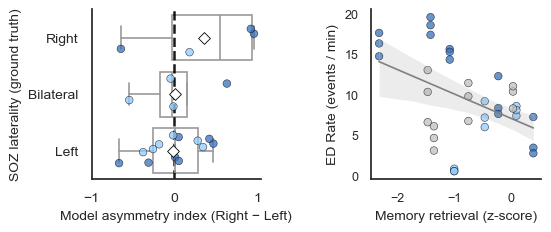

In [250]:
# 2 colors
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# --- סגנון ---
sns.set_context("notebook", font_scale=1.1)
sns.set_style("white")

# --- קריאת נתוני קוהורטות (משותף לשני הגרפים) ---
v1 = pd.read_csv('figures/V1.csv')
v2 = pd.read_csv('figures/V2.csv')
v1['subject'] = v1['subject'].astype(str).str.strip()
v2['subject'] = v2['subject'].astype(str).str.strip()

v1_subjects = set(v1['subject'].unique())
v2_subjects = set(v2['subject'].unique())

def cohort_of(subj):
    in_v1 = subj in v1_subjects
    in_v2 = subj in v2_subjects
    if in_v1 and not in_v2:
        return 'V1'
    if in_v2 and not in_v1:
        return 'V2'
    if in_v1 and in_v2:
        return 'V2'
    return 'Unknown'

# --- צבעים ושקיפות משותפים ---
palette_cohort = {
    'V1': '#90CCFF',
    'V2': '#3870bb',
    'Unknown': '#BFBFBF'
}
point_alpha = 0.75  # שקיפות אחידה
point_size = 30     # גודל אחיד (ב-scatter s=, ב-stripplot size= שונה)

# --- יצירת Figure עם שני subplots ---
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 2.4))
fig, (ax1, ax2) = plt.subplots(
    ncols=2, figsize=(5.8, 2.2),  # שני פאנלים קומפקטיים
    gridspec_kw={'wspace': 0.65}
)

# ========== גרף שמאל: Laterality ==========
df_lat = pd.read_csv('figures/laterality.csv')
df_lat['subject'] = df_lat['subject'].astype(str).str.strip()
df_lat['cohort'] = df_lat['subject'].map(cohort_of)

categories = ['Right', 'Bilateral', 'Left']
hue_order = ['V1', 'V2', 'Unknown'] if 'Unknown' in df_lat['cohort'].unique() else ['V1', 'V2']

sns.boxplot(
    data=df_lat,
    y='Zone Category', x='Asymmetry Index',
    order=categories,
    color='white', linewidth=1.2, showcaps=True, fliersize=0, ax=ax1
)

sns.stripplot(
    data=df_lat,
    y='Zone Category', x='Asymmetry Index',
    order=categories,
    hue='cohort', hue_order=hue_order,
    palette=palette_cohort,
    alpha=point_alpha, size=5.5, jitter=0.30, dodge=False,
    edgecolor='black', linewidth=0.4, ax=ax1
)

# ממוצעים
group_means = df_lat.groupby('Zone Category')['Asymmetry Index'].mean()
for i, category in enumerate(categories):
    mean_x = group_means.get(category, float('nan'))
    ax1.scatter(mean_x, i, color='white', edgecolor='black',
                marker='D', s=36, linewidth=0.6, zorder=5)

# קו 0
ax1.axvline(0, color='black', linestyle='--', linewidth=1.8, alpha=0.9)

# עיצוב
ax1.set_xlabel('Model asymmetry index (Right − Left)', fontsize=10)
ax1.set_ylabel('SOZ laterality (ground truth)', fontsize=10)
ax1.set_xlim(-1, 1.05)
ax1.set_xticks([-1, 0, 1])
ax1.tick_params(labelsize=10)
ax1.grid(False)
sns.despine(ax=ax1, top=True, right=True)
if ax1.get_legend():
    ax1.get_legend().remove()

# ========== גרף ימין: Correlation ==========
spikes_df = pd.read_csv('figures/V1_V2_combined_with_depth.csv')
cog_df    = pd.read_csv('figures/EPI_Corr_with_depth.csv', encoding='cp1255')

spikes_df['subject'] = spikes_df['subject'].astype(str).str.strip()
cog_df['subject']    = cog_df['subject'].astype(str).str.strip()

var = 'יעילות שליפת המידע'
merged_df = pd.merge(
    spikes_df,
    cog_df[['subject', var]],
    on='subject',
    how='inner'
).dropna(subset=['subject', 'Spikes_per_min', var])

# שיוך קוהורטות לכל דגימה (לצבע בגרף)
merged_df['cohort'] = merged_df['subject'].map(cohort_of)
hue_levels = ['V1', 'V2'] + (['Unknown'] if 'Unknown' in merged_df['cohort'].unique() else [])

# --- גרף: כל הדגימות ---
sns.scatterplot(
    data=merged_df,
    x=var, y='Spikes_per_min',
    hue='cohort', hue_order=hue_levels,
    palette=palette_cohort,
    s=point_size, alpha=point_alpha,
    edgecolor='black', linewidth=0.4, legend=False,
    ax=ax2
)

# (אופציונלי) קו רגרסיה על כל הדגימות – להשאיר ויזואלית בלבד
sns.regplot(
    data=merged_df,
    x=var, y='Spikes_per_min',
    scatter=False,
    line_kws={'color': 'gray', 'linewidth': 1.2},
    ax=ax2
)

# --- קורלציה: רק על ממוצעים לנבדק (מודפס לקונסול בלבד) ---
subj_means = (
    merged_df.groupby('subject', as_index=False)
             .agg(Spikes_per_min=('Spikes_per_min', 'mean'),
                  **{var: (var, 'mean')})
)

# סינון בטיחותי ונטרול מקרים דגנרטיביים
import numpy as np
x = subj_means[var].to_numpy()
y = subj_means['Spikes_per_min'].to_numpy()
mask = np.isfinite(x) & np.isfinite(y)

if mask.sum() >= 2 and np.std(x[mask]) > 0 and np.std(y[mask]) > 0:
    r, p = pearsonr(x[mask], y[mask])
    print(f"[Correlation on subject means] r = {r:.4f}, p = {p:.4g}, n = {mask.sum()}")
else:
    print(f"[Correlation on subject means] insufficient/constant data (n = {mask.sum()})")

# עיצוב
ax2.set_xlabel('Memory retrieval (z-score)', fontsize=10)
ax2.set_ylabel('ED Rate (events / min)', fontsize=10)
ax2.tick_params(labelsize=9)
sns.despine(ax=ax2, top=True, right=True)


# --- שמירה ---
plt.tight_layout()
plt.savefig("figures/combined_laterality_correlation_12.pdf", dpi=600, bbox_inches='tight', transparent=False)
plt.show()

In [252]:
# 12 נבדקים
# === סטטיסטיקה: LMM + Repeated-Measures Correlation ===
import numpy as np
import pandas as pd

# 1) להכין DF מודלי עם שם עמודה סטנדרטי ולוודא נומריקה
model_df = (
    merged_df
      .rename(columns={var: 'retrieval_efficiency'})  # var='יעילות שליפת המידע'
      .loc[:, ['subject', 'Spikes_per_min', 'retrieval_efficiency']]
      .copy()
)

# להמיר לנומרי ולהפיל NaN
model_df['Spikes_per_min'] = pd.to_numeric(model_df['Spikes_per_min'], errors='coerce')
model_df['retrieval_efficiency'] = pd.to_numeric(model_df['retrieval_efficiency'], errors='coerce')
model_df = model_df.dropna(subset=['subject', 'Spikes_per_min', 'retrieval_efficiency'])

# ליתר בטחון: subject כמחרוזת
model_df['subject'] = model_df['subject'].astype(str).str.strip()

# 2) Mixed Effects Model: רנדום-אינטרספט לפי subject
import statsmodels.formula.api as smf

# ננסה התאמה; אם יש אזהרות קונברגנציה – ננסה method='lbfgs'
try:
    result = smf.mixedlm(
        "Spikes_per_min ~ retrieval_efficiency",
        data=model_df,
        groups="subject",
        re_formula="1"
    ).fit(reml=True)
except Exception as e:
    print("[MixedLM] First try failed, retrying with lbfgs. Details:", str(e))
    result = smf.mixedlm(
        "Spikes_per_min ~ retrieval_efficiency",
        data=model_df,
        groups="subject",
        re_formula="1"
    ).fit(method='lbfgs', reml=True)

# מקדמים, טעויות תקן, סטטיסטיקות
beta1 = result.params.get('retrieval_efficiency', np.nan)
se1   = result.bse.get('retrieval_efficiency', np.nan)
z1    = result.tvalues.get('retrieval_efficiency', np.nan)  # ב-MixedLM זה נקרא tvalues אך מתנהג כ-z במודל לינארי
p1    = result.pvalues.get('retrieval_efficiency', np.nan)

# 3) R^2 (Nakagawa): מרג'ינלי וקונדישנלי — תיקון y_fixed באמצעות exog @ fe_params
import numpy as np

# חיזוי מהאפקטים הקבועים בלבד (Fixed effects only)
X = result.model.exog                  # מטריצת העיצוב של האפקטים הקבועים
beta = result.fe_params                # וקטור המקדמים של האפקטים הקבועים
y_fixed = np.asarray(X @ beta)         # תחזית ללא רנדום-אינטרספט

var_fixed = np.var(y_fixed, ddof=1)

# וריאנס הרכיב הרנדומי (רנדום-אינטרספט) — עבור מודל עם רכיב רנדומי יחיד
try:
    var_random = float(result.cov_re.iloc[0, 0])
except Exception:
    var_random = float(np.squeeze(np.asarray(result.cov_re)))

# וריאנס שיורי (Scale = σ^2)
var_resid = float(result.scale)

R2_marg = var_fixed / (var_fixed + var_random + var_resid)
R2_cond = (var_fixed + var_random) / (var_fixed + var_random + var_resid)

print(f"Mixed model: β = {beta.get('retrieval_efficiency', np.nan):.2f}, "
      f"SE = {result.bse.get('retrieval_efficiency', np.nan):.2f}, "
      f"z = {result.tvalues.get('retrieval_efficiency', np.nan):.2f}, "
      f"p = {result.pvalues.get('retrieval_efficiency', np.nan):.4g}")
print(f"R² (marginal) = {R2_marg:.3f}, R² (conditional) = {R2_cond:.3f}")


# 4) Repeated-measures correlation (Pingouin)
try:
    import pingouin as pg
    rm = pg.rm_corr(data=model_df, x='retrieval_efficiency', y='Spikes_per_min', subject='subject')
    # הדפסה נעימה
    r_rm   = float(rm['r'].iat[0])
    p_rm   = float(rm['pval'].iat[0])
    ci_rm  = rm['CI95%'].iat[0]  # מחרוזת כמו "[low, high]"
    print(f"Repeated-measures correlation: r_rm = {r_rm:.2f}, 95% CI {ci_rm}, p = {p_rm:.3g}")
except ImportError:
    print("pingouin לא מותקן (pip install pingouin) — מדלגים על rmcorr.")


Mixed model: β = -3.00, SE = 1.81, z = -1.66, p = 0.0969
R² (marginal) = 0.177, R² (conditional) = 0.892
Repeated-measures correlation: r_rm = -0.28, 95% CI [-0.6, 0.12], p = 0.162


In [239]:
# 8 נבדקים
import numpy as np

# פרמטרים מהמודל
fe = result.fe_params
beta0 = fe['Intercept']
beta1 = fe['retrieval_efficiency']

# חיזוי מהחלק הקבוע בלבד (ללא רנדום)
y_fixed = beta0 + beta1 * merged_df['retrieval_efficiency'].values
var_fixed  = np.var(y_fixed, ddof=1)
var_random = float(result.cov_re.iloc[0,0])   # Group Var
var_resid  = result.scale                     # Scale (σ^2)

R2_marg = var_fixed / (var_fixed + var_random + var_resid)
R2_cond = (var_fixed + var_random) / (var_fixed + var_random + var_resid)

print(f"Mixed model: β = {beta1:.2f}, p = {result.pvalues['retrieval_efficiency']:.3g}")
print(f"R² (marginal) = {R2_marg:.3f}, R² (conditional) = {R2_cond:.3f}")


NameError: name 'result' is not defined

In [156]:
# 8 נבדקים
import pingouin as pg

# rmcorr: כל הדגימות, מתקן לתלות לפי subject
rm = pg.rm_corr(data=merged_df, x='retrieval_efficiency', y='Spikes_per_min', subject='subject')
print(rm[['r','CI95%','pval']])

r_rm = rm['r'].iat[0]
p_rm = rm['pval'].iat[0]
print(f"Repeated-measures correlation: r = {r_rm:.2f}, p = {p_rm:.3g}")


                r           CI95%      pval
rm_corr -0.801062  [-0.92, -0.53]  0.000065
Repeated-measures correlation: r = -0.80, p = 6.47e-05


One-way ANOVA (Young vs Elderly vs MCI vs AD) on per-subject means: F=19.788, p=2.148e-09


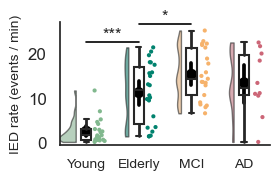

In [89]:
import seaborn as sns
import matplotlib.pyplot as plt
import ptitprince as pt
from scipy.stats import f_oneway
import pandas as pd
import numpy as np

# Styling
sns.set_context("notebook", font_scale=1.1)
sns.set_style("white")

# ----- קבוצה מקורית: HC / MCI / AD -----
df = pd.read_csv('figures/MCI_rates_final.csv')  # מצופה: group, subject, Spikes_per_min
data_subset = df.copy()
data_subset['group'] = data_subset['group'].astype(str).str.strip()
data_subset['subject'] = data_subset['subject'].astype(str).str.strip()

# ממוצע פר-נבדק לכל קבוצה קיימת
data_subset_mean = data_subset.groupby(['group', 'subject'], as_index=False)['Spikes_per_min'].mean()

# ----- קבוצה חדשה: Young (נלקח מ-HC מתוך V1_V2_combined.csv) -----
spikes_df = pd.read_csv('figures/V1_V2_combined.csv')  # מצופה: subject, Spikes_per_min, part, group(=HC/...)
spikes_df['group'] = spikes_df['group'].astype(str).str.strip()
spikes_df['subject'] = spikes_df['subject'].astype(str).str.strip()

young_src = spikes_df[spikes_df['group'] == 'HC'].copy()
young_mean = young_src.groupby('subject', as_index=False)['Spikes_per_min'].mean()
young_mean['group'] = 'Young'  # שם קבוצה חדש

# נתוני ממוצע פר-נבדק לכל הקבוצות יחד (Young + HC/MCI/AD)
combined_means = pd.concat(
    [data_subset_mean[['group', 'subject', 'Spikes_per_min']], young_mean[['group', 'subject', 'Spikes_per_min']]],
    ignore_index=True
)

# שינוי שם HC -> Elderly (לנוחות הצגה)
combined_means['group'] = combined_means['group'].replace({'HC': 'Elderly'})

# ----- סדר וקולורים -----
group_order = ['Young', 'Elderly', 'MCI', 'AD']
palette = ['#81b88e', '#00826e', '#F6B26B', '#CC6677']  # Young=ירוק בהיר, Elderly=זית כהה, MCI=כתום, AD=בורדו

# ----- ANOVA (one-way) על ממוצעי נבדק בארבע הקבוצות -----
groups = [
    combined_means.loc[combined_means['group'] == g, 'Spikes_per_min'].dropna().values
    for g in group_order
]
if any(len(a) == 0 for a in groups):
    print("Cannot run ANOVA: one or more groups are empty.")
else:
    F, p = f_oneway(*groups)
    print(f"One-way ANOVA (Young vs Elderly vs MCI vs AD) on per-subject means: F={F:.3f}, p={p:.4g}")

# ----- ציור -----
fig, ax = plt.subplots(figsize=(3, 2))  # מעט רחב יותר ל-4 קבוצות

pt.RainCloud(
    x='group',
    y='Spikes_per_min',
    data=combined_means,
    order=group_order,
    palette=palette,
    bw=.3, width_viol=.65,
    ax=ax, orient='v', move=0.25,
    alpha=0.6, pointplot=False, box_showfliers=False, width_box=0.2
)

sns.pointplot(
    data=combined_means,
    x='group', y='Spikes_per_min',
    order=group_order,
    color='black', join=False, markers='o',
    errorbar=None, scale=0.9, ax=ax
)

# --- כוכביות מבוקשות ---
def add_sig(ax, x1, x2, y, text, h=0.08):
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], color='black', lw=1.2)
    ax.text((x1+x2)/2, y+h*1.05, text, ha='center', va='bottom', fontsize=12)

ymax = combined_means['Spikes_per_min'].max()
base = ymax * 1.05
step = max(0.1, (ymax - (-0.3)) * 0.07)

# *** בין Young (0) ל-Elderly (1)
add_sig(ax, 0, 1, 22.5, '***')
# * בין Elderly (1) ל-MCI (2)
add_sig(ax, 1, 2, 26.5, '*')

# עיצוב
ax.set_ylabel("IED rate (events / min)", fontsize=10)
ax.set_xlabel("")
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_ylim(-0.6, 27)  # מקום לכוכביות
ax.set_xticklabels(['Young', 'Elderly', 'MCI', 'AD'])
# x font
plt.xticks(fontsize=10)

plt.tight_layout()
plt.savefig("figures/MCI_groups_rates_with_young_ANOVA_stars.png", dpi=300, bbox_inches='tight', transparent=False)
plt.show()


One-way ANOVA (Young vs Elderly vs MCI vs AD) on per-subject means: F=19.788, p=2.148e-09


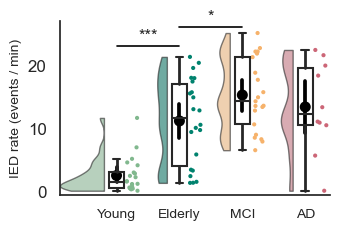

In [105]:
import seaborn as sns
import matplotlib.pyplot as plt
import ptitprince as pt
from scipy.stats import f_oneway
import pandas as pd
import numpy as np

# Styling
sns.set_context("notebook", font_scale=1.1)
sns.set_style("white")

# ----- קבוצה מקורית: HC / MCI / AD -----
df = pd.read_csv('figures/MCI_rates_final.csv')  # מצופה: group, subject, Spikes_per_min
data_subset = df.copy()
data_subset['group'] = data_subset['group'].astype(str).str.strip()
data_subset['subject'] = data_subset['subject'].astype(str).str.strip()

# ממוצע פר-נבדק לכל קבוצה קיימת
data_subset_mean = data_subset.groupby(['group', 'subject'], as_index=False)['Spikes_per_min'].mean()

# ----- קבוצה חדשה: Young (נלקח מ-HC מתוך V1_V2_combined.csv) -----
spikes_df = pd.read_csv('figures/V1_V2_combined.csv')  # מצופה: subject, Spikes_per_min, part, group(=HC/...)
spikes_df['group'] = spikes_df['group'].astype(str).str.strip()
spikes_df['subject'] = spikes_df['subject'].astype(str).str.strip()

young_src = spikes_df[spikes_df['group'] == 'HC'].copy()
young_mean = young_src.groupby('subject', as_index=False)['Spikes_per_min'].mean()
young_mean['group'] = 'Young'  # שם קבוצה חדש

# נתוני ממוצע פר-נבדק לכל הקבוצות יחד (Young + HC/MCI/AD)
combined_means = pd.concat(
    [data_subset_mean[['group', 'subject', 'Spikes_per_min']], young_mean[['group', 'subject', 'Spikes_per_min']]],
    ignore_index=True
)

# שינוי שם HC -> Elderly (לנוחות הצגה)
combined_means['group'] = combined_means['group'].replace({'HC': 'Elderly'})

# ----- סדר וקולורים -----
group_order = ['Young', 'Elderly', 'MCI', 'AD']
palette = ['#81b88e', '#00826e', '#F6B26B', '#CC6677']  # Young=ירוק בהיר, Elderly=זית כהה, MCI=כתום, AD=בורדו

# ----- ANOVA (one-way) על ממוצעי נבדק בארבע הקבוצות -----
groups = [
    combined_means.loc[combined_means['group'] == g, 'Spikes_per_min'].dropna().values
    for g in group_order
]
if any(len(a) == 0 for a in groups):
    print("Cannot run ANOVA: one or more groups are empty.")
else:
    F, p = f_oneway(*groups)
    print(f"One-way ANOVA (Young vs Elderly vs MCI vs AD) on per-subject means: F={F:.3f}, p={p:.4g}")

# ----- ציור -----
# Increased width to accommodate larger violins and prevent clipping
PER_GROUP_INCH = 1.2       # Increased from 1.0 to give more space
HEIGHT_INCH    = 2.5

fig, ax = plt.subplots(figsize=(PER_GROUP_INCH * len(group_order)*0.75, HEIGHT_INCH))

# ---- RainCloud with larger violins ----
pt.RainCloud(
    x='group', y='Spikes_per_min',
    data=combined_means,
    order=group_order,
    palette=palette,
    bw=.3,
    width_viol=1.4,    # Increased from 0.80 to make violins larger
    width_box=0.24,    
    move=0.25,         
    ax=ax, orient='v',
    alpha=0.6,
    pointplot=False,
    box_showfliers=False
)

# ממוצעים
sns.pointplot(
    data=combined_means, x='group', y='Spikes_per_min',
    order=group_order, color='black',
    join=False, markers='o', errorbar=None, scale=0.9, ax=ax
)

# Updated function for flat significance lines (no vertical connectors)
def add_sig_flat(ax, x1, x2, y_frac, text):
    """Add flat significance line without vertical connectors"""
    y0, y1 = ax.get_ylim()
    span = y1 - y0
    y = y0 + y_frac * span
    
    # Draw only horizontal line
    ax.plot([x1, x2], [y, y], color='black', lw=1.2)
    
    # Add text above the line
    ax.text((x1+x2)/2, y + 0.015 * span, text, ha='center', va='bottom', fontsize=12)

# Flat significance lines
add_sig_flat(ax, 0, 1, 0.88, '***')  # Young–Elderly
add_sig_flat(ax, 1, 2, 0.99, '*')    # Elderly–MCI

# עיצוב
ax.set_ylabel("IED rate (events / min)", fontsize=10)
ax.set_xlabel("")
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Adjust x-axis limits to prevent clipping of the leftmost violin
ax.set_xlim(-0.9, 3.4)  # Give more space on the left side
ax.set_ylim(-0.6, 27)   # Keep original y limits
ax.set_xticklabels(['Young', 'Elderly', 'MCI', 'AD'])

# x font
plt.xticks(fontsize=10)

plt.tight_layout()
plt.savefig("figures/MCI_groups_rates_with_young_ANOVA_stars.png", dpi=300, bbox_inches='tight', transparent=False)
plt.show()

r = -0.36
p = 0.006


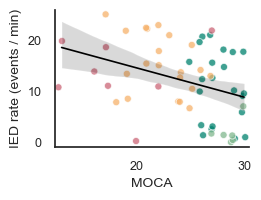

In [126]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import numpy as np

# --- קבצים ---
spikes_main = pd.read_csv('figures/MCI_rates_final.csv')   # subject, group, Spikes_per_min
cog_main    = pd.read_csv('figures/MCI_corr_final.csv')    # subject, group, MOCA
epi         = pd.read_csv('figures/EPI_MOCA.csv')          # subject, Spikes_per_min, group, MOCA

# --- ניקוי בסיסי ---
for df in (spikes_main, cog_main, epi):
    for col in ('subject','group'):
        if col in df.columns:
            df[col] = df[col].astype(str).str.strip()

# ודא שהקובץ הנוסף מסומן כ-HC
epi['group'] = 'HC'

# --- ממוצע ספייקים לכל נבדק ---
avg_main = (spikes_main.groupby('subject', as_index=False)['Spikes_per_min']
            .mean().rename(columns={'Spikes_per_min':'Avg_Spikes_per_min'}))
avg_epi  = (epi.groupby('subject', as_index=False)['Spikes_per_min']
            .mean().rename(columns={'Spikes_per_min':'Avg_Spikes_per_min'}))

# מאחדים ממוצעי ספייקים (עדיפות ל-main)
spikes_all = avg_main.merge(avg_epi, on='subject', how='outer', suffixes=('_main','_epi'))
spikes_all['Avg_Spikes_per_min'] = spikes_all['Avg_Spikes_per_min_main'].combine_first(spikes_all['Avg_Spikes_per_min_epi'])
spikes_all = spikes_all[['subject','Avg_Spikes_per_min']]

# --- איחוד קוגניציה (עדיפות ל-main) ---
cog_keep_cols = ['subject','group','MOCA']
cog_all = pd.concat([cog_main[cog_keep_cols], epi[cog_keep_cols]], ignore_index=True)
cog_all = cog_all.drop_duplicates(subset=['subject'], keep='first').reset_index(drop=True)

# --- Young/Elderly: כל מי שמגיע מ-EPI_MOCA => Young; שאר ה-HC => Elderly ---
young_subjects = set(epi['subject'])
def map_group4(row):
    if row['group'] == 'HC':
        return 'Young' if row['subject'] in young_subjects else 'Elderly'
    return row['group']  # MCI / AD

cog_all['group4'] = cog_all.apply(map_group4, axis=1)
cog_all['MOCA'] = pd.to_numeric(cog_all['MOCA'], errors='coerce')

# --- מיזוג קוגניציה + ספייקים ---
merged_df = pd.merge(cog_all, spikes_all, on='subject', how='inner')

# --- פילטר (אם צריך, כמו אצלך) ---
filtered_df = merged_df[merged_df['MOCA'] > 10].copy()

# --- צבעים כמו ב-RainCloud: Young/Elderly/MCI/AD ---
palette_map = {'Young': '#81b88e', 'Elderly': '#00826e', 'MCI': '#F6B26B', 'AD': '#CC6677'}
hue_order   = ['Young', 'Elderly', 'MCI', 'AD']

# --- ציור + מתאם ---
sns.set_context("notebook", font_scale=1.1)
sns.set_style("white")
plt.figure(figsize=(2.8, 2.2))

# --- פרמטרים לנראות ---
DOT_SIZE = 26          # היה ~32
ALPHA    = 0.75        # היה 0.85
EDGE_LW  = 0.6         # קצה לבן קצת עבה יותר

# --- Jitter עדין (עם seed לשחזור) ---
rng = np.random.default_rng(42)
SIGMA_X = 0.15         # ~0.15 נק' MOCA
SIGMA_Y = 0.35         # ~0.35 באירועים/דקה

plot_df = filtered_df.copy()
plot_df['MOCA_plot'] = plot_df['MOCA'] + rng.normal(0, SIGMA_X, len(plot_df))
plot_df['IED_plot']  = np.clip(
    plot_df['Avg_Spikes_per_min'] + rng.normal(0, SIGMA_Y, len(plot_df)),
    0, None
)

# נקודות משופרות
sns.scatterplot(
    data=plot_df,
    x='MOCA_plot', y='IED_plot',
    hue='group4', hue_order=['Young','Elderly','MCI','AD'],
    palette={'Young':'#81b88e','Elderly':'#00826e','MCI':'#F6B26B','AD':'#CC6677'},
    s=DOT_SIZE, alpha=ALPHA,
    edgecolor='white', linewidth=EDGE_LW
)

# קו רגרסיה על הנתונים המקוריים (בלי נקודות)
sns.regplot(
    data=filtered_df,
    x='MOCA', y='Avg_Spikes_per_min',
    scatter=False, color='black',
    line_kws={'linewidth': 1.2}
)

# Pearson r,p על כל המדגם (אפשר גם לפי קבוצה אם תרצי)
valid_df = filtered_df[['MOCA','Avg_Spikes_per_min']].dropna()
if len(valid_df) >= 2:
    r, p = pearsonr(valid_df['MOCA'], valid_df['Avg_Spikes_per_min'])
    print(f"r = {r:.2f}\np = {p:.3f}")
else:
    print("Not enough data")

# עיצוב
plt.legend([], [], frameon=False)   # בלי מקרא; הסדר נשמר ב-hue_order אם תרצי להציג
plt.xlabel('MOCA', fontsize=10)
plt.ylabel('IED rate (events / min)', fontsize=10)
plt.xticks(fontsize=9); plt.yticks(fontsize=9)
plt.ylim(-1, 26)
plt.xlim(12.4, 30.5)
sns.despine(top=True, right=True)
plt.tight_layout()
# save
plt.savefig('figures/moca_corr_jittered.png', dpi=300, bbox_inches='tight', transparent=False)
plt.show()


One-way ANOVA (IEDs): F=19.788, p=2.148e-09
Pearson corr (all): r=-0.36, p=0.006


C:\Users\user\AppData\Local\Temp\ipykernel_7644\1469897947.py:178: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


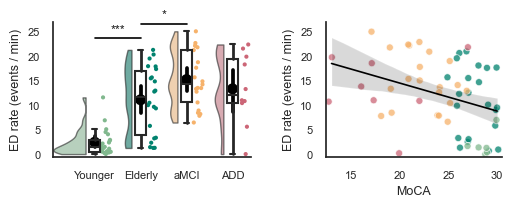

In [140]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
import ptitprince as pt
from scipy.stats import f_oneway, pearsonr
import numpy as np

# ============= קריאה וניקוי נתונים =============
sns.set_context("notebook", font_scale=1.1)
sns.set_style("white")

# קבצים
df_main   = pd.read_csv('figures/MCI_rates_final.csv')     # group, subject, Spikes_per_min
roc_src   = pd.read_csv('figures/V1_V2_combined.csv')      # subject, Spikes_per_min, part, group (HC/...)
cog_main  = pd.read_csv('figures/MCI_corr_final.csv')      # subject, group, MOCA
epi       = pd.read_csv('figures/EPI_MOCA.csv')            # subject, Spikes_per_min, group, MOCA

# ניקוי בסיסי
for df in (df_main, roc_src, cog_main, epi):
    for col in ('subject','group'):
        if col in df.columns:
            df[col] = df[col].astype(str).str.strip()
epi['group'] = 'HC'  # ודא

# ============= הכנת נתונים לגרף 1 (RainCloud של IEDs) =============
# ממוצע פר-נבדק מהקובץ הראשי
data_subset_mean = df_main.groupby(['group','subject'], as_index=False)['Spikes_per_min'].mean()

# Young: ממוצע פר-נבדק לכל HC מ-V1_V2_combined
young_mean = (roc_src[roc_src['group']=='HC']
              .groupby('subject', as_index=False)['Spikes_per_min'].mean())
young_mean['group'] = 'Young'

# איחוד + שינוי תווית HC→Elderly
combined_means = pd.concat(
    [data_subset_mean[['group','subject','Spikes_per_min']],
     young_mean[['group','subject','Spikes_per_min']]],
    ignore_index=True
)
combined_means['group'] = combined_means['group'].replace({'HC':'Elderly'})

group_order = ['Young','Elderly','MCI','AD']
palette     = ['#81b88e', '#00826e', '#F6B26B', '#CC6677']

# ANOVA (הדפסה)
groups = [combined_means.loc[combined_means['group']==g, 'Spikes_per_min'].dropna().values
          for g in group_order]
if not any(len(a)==0 for a in groups):
    F, p = f_oneway(*groups)
    print(f"One-way ANOVA (IEDs): F={F:.3f}, p={p:.4g}")

# ============= הכנת נתונים לגרף 2 (קורלציה MOCA↔IED) =============
# ממוצע IED פר-נבדק: main + fallback מ-EPI_MOCA
avg_main = (df_main.groupby('subject', as_index=False)['Spikes_per_min']
            .mean().rename(columns={'Spikes_per_min':'Avg_Spikes_per_min'}))
avg_epi  = (epi.groupby('subject', as_index=False)['Spikes_per_min']
            .mean().rename(columns={'Spikes_per_min':'Avg_Spikes_per_min'}))
spikes_all = avg_main.merge(avg_epi, on='subject', how='outer', suffixes=('_main','_epi'))
spikes_all['Avg_Spikes_per_min'] = spikes_all['Avg_Spikes_per_min_main'].combine_first(spikes_all['Avg_Spikes_per_min_epi'])
spikes_all = spikes_all[['subject','Avg_Spikes_per_min']]

# קוגניציה מאוחדת + חלוקה Young/Elderly בתוך HC לפי מקור EPI_MOCA
cog_all = pd.concat([cog_main[['subject','group','MOCA']], epi[['subject','group','MOCA']]], ignore_index=True)
cog_all = cog_all.drop_duplicates(subset=['subject'], keep='first').reset_index(drop=True)
young_subjects = set(epi['subject'])
cog_all['group4'] = cog_all.apply(lambda r: ('Young' if r['subject'] in young_subjects else 'Elderly') if r['group']=='HC' else r['group'], axis=1)
cog_all['MOCA'] = pd.to_numeric(cog_all['MOCA'], errors='coerce')

merged = pd.merge(cog_all, spikes_all, on='subject', how='inner')
filtered = merged[merged['MOCA'] > 10].copy()  # אותו פילטר כמו קודם

# Pearson r,p (כולל)
valid = filtered[['MOCA','Avg_Spikes_per_min']].dropna()
if len(valid) >= 2:
    r, p = pearsonr(valid['MOCA'], valid['Avg_Spikes_per_min'])
    print(f"Pearson corr (all): r={r:.2f}, p={p:.3f}")

# ============= פונקציית כוכביות =============
def add_sig_flat(ax, x1, x2, y_frac, text):
    """מצייר קו אופקי קצר וטקסט בגובה יחסי של הציר האנכי"""
    y0, y1 = ax.get_ylim(); span = y1 - y0
    y = y0 + y_frac * span
    ax.plot([x1, x2], [y, y], color='black', lw=1.2)
    ax.text((x1+x2)/2, y + 0.015*span, text, ha='center', va='bottom', fontsize=9)

# ============= הגדרות פיזיות של איור (70%×15% עמוד) + פונטים אחידים =============
PAGE = "A4"  # או "LETTER"
PAGE_W = 8.27 if PAGE == "A4" else 8.50   # inches
PAGE_H = 11.69 if PAGE == "A4" else 11.00

W_FRAC = 0.70      # 70% מרוחב העמוד
H_FRAC = 0.15      # 15% מגובה העמוד
FIG_W = PAGE_W * W_FRAC
FIG_H = PAGE_H * H_FRAC

DPI = 600  # חדות גבוהה להדפסה/פרסום

# פונטים אחידים לכל האיור
BASE = 9  # אפשר להגדיל ל-10 אם תרצי יותר גדול
mpl.rcParams.update({
    "font.size": BASE,
    "axes.labelsize": BASE,
    "xtick.labelsize": BASE-1,
    "ytick.labelsize": BASE-1,
    "legend.fontsize": BASE-1,
})

# ============= ציור זה-לצד-זה =============
fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(FIG_W, FIG_H),
    gridspec_kw={'width_ratios':[1.12, 1.0], 'wspace':0.40}
)

# --- שמאל: RainCloud ---
pt.RainCloud(
    x='group', y='Spikes_per_min',
    data=combined_means,
    order=group_order, palette=palette,
    bw=.3, width_viol=1.4, width_box=0.24, move=0.25,
    ax=ax1, orient='v', alpha=0.6,
    pointplot=False, box_showfliers=False
)
sns.pointplot(
    data=combined_means, x='group', y='Spikes_per_min',
    order=group_order, color='black',
    join=False, markers='o', errorbar=None, scale=0.9, ax=ax1
)

# --- ימין: קורלציה עם jitter ---
palette_map = {'Young':'#81b88e','Elderly':'#00826e','MCI':'#F6B26B','AD':'#CC6677'}

rng = np.random.default_rng(42)
SIGMA_X, SIGMA_Y = 0.15, 0.35
plot_df = filtered.copy()
plot_df['MOCA_plot'] = plot_df['MOCA'] + rng.normal(0, SIGMA_X, len(plot_df))
plot_df['IED_plot']  = np.clip(plot_df['Avg_Spikes_per_min'] + rng.normal(0, SIGMA_Y, len(plot_df)), 0, None)

sns.scatterplot(
    data=plot_df, x='MOCA_plot', y='IED_plot',
    hue='group4', hue_order=['Young','Elderly','MCI','AD'],
    palette=palette_map,
    s=26, alpha=0.75, edgecolor='white', linewidth=0.6,
    ax=ax2, legend=False
)
sns.regplot(
    data=filtered, x='MOCA', y='Avg_Spikes_per_min',
    scatter=False, color='black', line_kws={'linewidth':1.2},
    ax=ax2
)

# === אחידות פונטים וטייקים/סקאלה ב-Y (IED) ===
YMIN, YMAX = -0.6, 27
YTICKS = [0, 5, 10, 15, 20, 25]
for a in (ax1, ax2):
    a.set_ylim(YMIN, YMAX)
    a.set_yticks(YTICKS)

# תוויות צירים
ax1.set_ylabel("ED rate (events / min)")
ax1.set_xlabel("")
ax2.set_ylabel("ED rate (events / min)")
ax2.set_xlabel("MoCA")

# X-axes
ax1.set_xlim(-0.9, 3.4)
ax1.set_xticklabels(['Younger','Elderly','aMCI','ADD'])
ax1.spines['top'].set_visible(False); ax1.spines['right'].set_visible(False)

ax2.set_xlim(12.4, 30.5)
ax2.set_xticks([15, 20, 25, 30])
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)

# כוכביות - רק אחרי שקבענו ylim
add_sig_flat(ax1, 0, 1, 0.88, '***')  # Young–Elderly
add_sig_flat(ax1, 1, 2, 0.99, '*')    # Elderly–MCI

plt.tight_layout()

# ===== שמירה בגודל הסופי =====
fig.savefig("figures/ed_groups_and_moca_corr_side_by_side.png",
            dpi=DPI, bbox_inches="tight", pad_inches=0.02)
# save as pdf
fig.savefig("figures/ed_groups_and_moca_corr_side_by_side.pdf", dpi=DPI, bbox_inches="tight", pad_inches=0.02)

plt.show()


HC: W=0.9143, p=0.0503
MCI: W=0.9518, p=0.3950
AD: W=0.9203, p=0.3943
HC vs MCI p-value: 8.520206367424398e-08
MCI vs AD p-value: 0.017599323979744817
HC vs AD p-value: 0.00020592154733022996


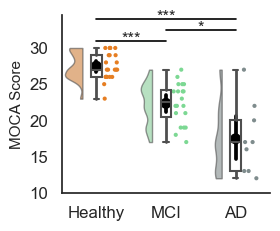

In [97]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import ptitprince as pt
from scipy.stats import ttest_ind

# Load data (contains 'subject', 'group', 'MOCA')
df = pd.read_csv('figures/MCI_Corr.csv')  # Update with your actual file path
# filter moca > 10
df = df[df['MOCA'] > 10]
# Define group order and palette
group_order = ['HC', 'MCI', 'AD']
group_palette = {'HC': '#e67e22', 'MCI': '#7cd893', 'AD': '#7f8c8d'}

# Plot setup
fig, ax = plt.subplots(figsize=(3, 2.5))

# RainCloud plot (violin + box without fliers, no individual points)
pt.RainCloud(
    x='group',
    y='MOCA',
    data=df,
    order=group_order,
    palette=[group_palette['HC'], group_palette['MCI'], group_palette['AD']],
    bw=.3,
    width_viol=.5,
    ax=ax,
    orient='v',
    move=0.2,
    alpha=0.6,
    pointplot=False,
    box_showfliers=False,
    # point_size=0
)


# Plot group means (black dots)
sns.pointplot(
    data=df,
    x='group',
    y='MOCA',
    order=group_order,
    color='black',
    join=False,
    markers='o',
    errorbar=None,
    scale=0.9,
    ax=ax
)

# --- Statistical comparisons (t-tests between group pairs) ---
hc_vals = df[df['group'] == 'HC']['MOCA']
mci_vals = df[df['group'] == 'MCI']['MOCA']
ad_vals = df[df['group'] == 'AD']['MOCA']

from scipy.stats import shapiro

# בדיקת נורמליות עבור כל קבוצה
for group_name in ['HC', 'MCI', 'AD']:
    stat, p = shapiro(df[df['group'] == group_name]['MOCA'])
    print(f"{group_name}: W={stat:.4f}, p={p:.4f}")

# T-tests
_, pval_HC_MCI = ttest_ind(hc_vals, mci_vals, equal_var=False)
_, pval_MCI_AD = ttest_ind(mci_vals, ad_vals, equal_var=False)
_, pval_HC_AD = ttest_ind(hc_vals, ad_vals, equal_var=False)

# Print p-values for debugging
print(f"HC vs MCI p-value: {pval_HC_MCI}")
print(f"MCI vs AD p-value: {pval_MCI_AD}")
print(f"HC vs AD p-value: {pval_HC_AD}")
# Function for significance stars
def significance_star(pval):
    if pval < 0.001:
        return '***'
    elif pval < 0.01:
        return '**'
    elif pval < 0.05:
        return '*'
    else:
        return 'ns'

# Draw significance lines and stars
y_max = df['MOCA'].max()
offsets = [1, 2.5, 4]  # Vertical offsets for the comparisons
comparisons = [((0, 1), pval_HC_MCI), ((1, 2), pval_MCI_AD), ((0, 2), pval_HC_AD)]

for (x1, x2), pval in comparisons:
    star = significance_star(pval)
    y_line = y_max + offsets.pop(0)
    if star != 'ns':
        ax.plot([x1, x2], [y_line, y_line], color='black', linewidth=1.2)
        ax.text((x1 + x2)/2, y_line-0.8, star, ha='center', va='bottom', fontsize=12)

# Axes styling
ax.set_ylabel("MOCA Score", fontsize=11)
ax.set_xlabel("")
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim(10, 34.5)
ax.set_xticklabels(['Healthy', 'MCI', 'AD'])

plt.tight_layout()
fig.savefig("figures/MCI_moca_box.png", dpi=300, bbox_inches='tight', transparent=False)
plt.show()


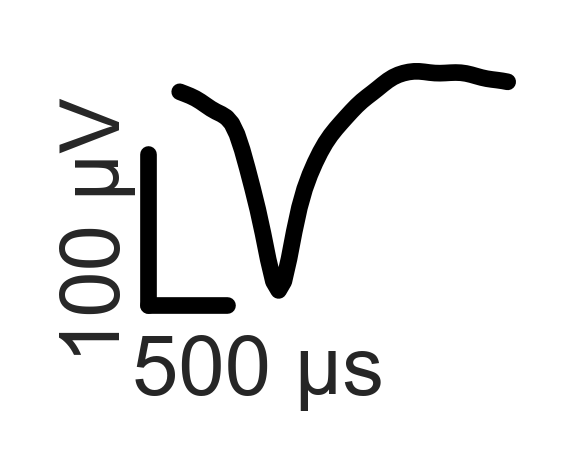

In [88]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# קריאת הקובץ
df = pd.read_csv("figures/times_018_RMH2.csv")

# עמודות הספייקים
spike_cols = [col for col in df.columns if col.startswith("spike_")]

# בחירת cluster
cluster_id = 1
df_cluster = df[df['cluster_class'] == cluster_id]

# לוקחים רק את הדגימות (n × 64)
samples = df_cluster[spike_cols].values

# מחשבים ממוצע
mean_waveform = samples.mean(axis=0)

# יצירת וקטור זמן (במיקרושניות)
fs = 30000  # תדר דגימה
n_samples = mean_waveform.shape[0]
time_us = np.arange(n_samples) / fs * 1e6  # מיקרושניות

# ========= פרמטרים לגודל =========
FIG_W_IN, FIG_H_IN = 1.0, 0.8   # קטן משמעותית
SAVE_DPI = 600                  # חדות גבוהה בשמירה (אפשר 300 אם מעדיפים)
FONT_SIZE = 10                  # פונטים יחסית גדולים

# ציור
fig, ax = plt.subplots(figsize=(FIG_W_IN, FIG_H_IN), dpi=SAVE_DPI)
ax.plot(time_us + 300, mean_waveform - 10, color='black', linewidth=2)

# הורדת צירים ומרווחים
ax.axis('off')
ax.set_position([0, 0, 1, 1])   # ממלא את כל הפיגורה

# הוספת סקייל-בר (במיקום קבוע יחסית לנתונים)
scalex = 500   # 500 µs
scaley = 100   # 100 µV
x0 = time_us.min() + 100
y0 = -140

# קווי סקייל
ax.plot([x0, x0 + scalex], [y0, y0], color='black', linewidth=2)
ax.plot([x0, x0], [y0, y0 + scaley], color='black', linewidth=2)

# טקסטים (פונט גדול יחסית לפיגורה קטנה)
ax.text(x0 + 700, y0 - 20, "500 µs", ha='center', va='top', fontsize=FONT_SIZE)
ax.text(x0 - 80, y0 + scaley/2, "100 µV", ha='right', va='center', rotation=90, fontsize=FONT_SIZE)

# תצוגה
plt.tight_layout(pad=0.01)  # מצמצם שוליים
plt.show()

# שמירה קטנה וחדה
fig.savefig("figures/RMH2_waveform.png",dpi=SAVE_DPI, bbox_inches='tight', pad_inches=0.01, transparent=False)


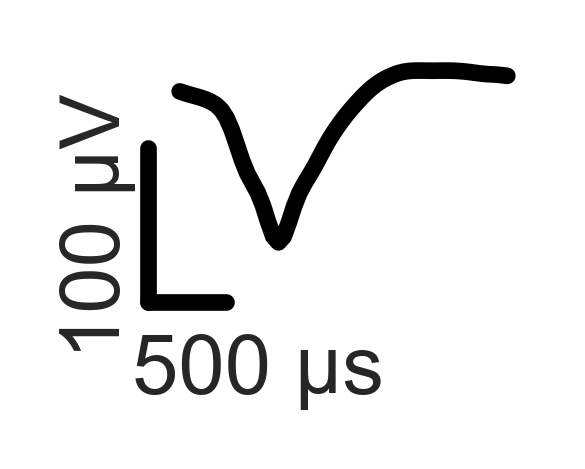

In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# קריאת הקובץ
df = pd.read_csv("figures/times_018_RMH6.csv")

# עמודות הספייקים
spike_cols = [col for col in df.columns if col.startswith("spike_")]

# בחירת cluster
cluster_id = 3
df_cluster = df[df['cluster_class'] == cluster_id]

# לוקחים רק את הדגימות (n × 64)
samples = df_cluster[spike_cols].values

# מחשבים ממוצע
mean_waveform = samples.mean(axis=0)

# יצירת וקטור זמן (במיקרושניות)
fs = 30000  # תדר דגימה
n_samples = mean_waveform.shape[0]
time_us = np.arange(n_samples) / fs * 1e6  # מיקרושניות

# ========= פרמטרים לגודל =========
FIG_W_IN, FIG_H_IN = 1.0, 0.8   # קטן משמעותית
SAVE_DPI = 600                  # חדות גבוהה בשמירה (אפשר 300 אם מעדיפים)
FONT_SIZE = 10                  # פונטים יחסית גדולים

# ציור
fig, ax = plt.subplots(figsize=(FIG_W_IN, FIG_H_IN), dpi=SAVE_DPI)
ax.plot(time_us + 300, mean_waveform - 10, color='black', linewidth=2)

# הורדת צירים ומרווחים
ax.axis('off')
ax.set_position([0, 0, 1, 1])   # ממלא את כל הפיגורה

# הוספת סקייל-בר (במיקום קבוע יחסית לנתונים)
scalex = 500   # 500 µs
scaley = 100   # 100 µV
x0 = time_us.min() + 100
y0 = -140

# קווי סקייל
ax.plot([x0, x0 + scalex], [y0, y0], color='black', linewidth=2)
ax.plot([x0, x0], [y0, y0 + scaley], color='black', linewidth=2)

# טקסטים (פונט גדול יחסית לפיגורה קטנה)
ax.text(x0 + 700, y0 - 20, "500 µs", ha='center', va='top', fontsize=FONT_SIZE)
ax.text(x0 - 80, y0 + scaley/2, "100 µV", ha='right', va='center', rotation=90, fontsize=FONT_SIZE)

# תצוגה
plt.tight_layout(pad=0.01)  # מצמצם שוליים
plt.show()

# שמירה קטנה וחדה
fig.savefig("figures/RMH6_waveform.png",dpi=SAVE_DPI, bbox_inches='tight', pad_inches=0.01, transparent=True)


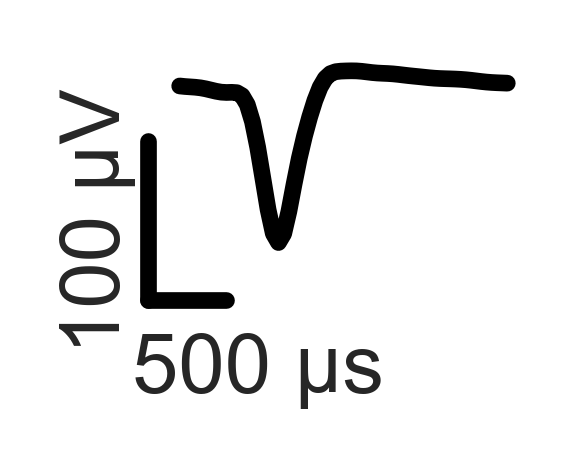

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# קריאת הקובץ
df = pd.read_csv("figures/times_018_RMH7.csv")

# עמודות הספייקים
spike_cols = [col for col in df.columns if col.startswith("spike_")]

# בחירת cluster
cluster_id = 1
df_cluster = df[df['cluster_class'] == cluster_id]

# לוקחים רק את הדגימות (n × 64)
samples = df_cluster[spike_cols].values

# מחשבים ממוצע
mean_waveform = samples.mean(axis=0)

# יצירת וקטור זמן (במיקרושניות)
fs = 30000  # תדר דגימה
n_samples = mean_waveform.shape[0]
time_us = np.arange(n_samples) / fs * 1e6  # מיקרושניות

# ========= פרמטרים לגודל =========
FIG_W_IN, FIG_H_IN = 1.0, 0.8   # קטן משמעותית
SAVE_DPI = 600                  # חדות גבוהה בשמירה (אפשר 300 אם מעדיפים)
FONT_SIZE = 10                  # פונטים יחסית גדולים

# ציור
fig, ax = plt.subplots(figsize=(FIG_W_IN, FIG_H_IN), dpi=SAVE_DPI)
ax.plot(time_us + 300, mean_waveform - 10, color='black', linewidth=2)

# הורדת צירים ומרווחים
ax.axis('off')
ax.set_position([0, 0, 1, 1])   # ממלא את כל הפיגורה

# הוספת סקייל-בר (במיקום קבוע יחסית לנתונים)
scalex = 500   # 500 µs
scaley = 100   # 100 µV
x0 = time_us.min() + 100
y0 = -140

# קווי סקייל
ax.plot([x0, x0 + scalex], [y0, y0], color='black', linewidth=2)
ax.plot([x0, x0], [y0, y0 + scaley], color='black', linewidth=2)

# טקסטים (פונט גדול יחסית לפיגורה קטנה)
ax.text(x0 + 700, y0 - 20, "500 µs", ha='center', va='top', fontsize=FONT_SIZE)
ax.text(x0 - 80, y0 + scaley/2, "100 µV", ha='right', va='center', rotation=90, fontsize=FONT_SIZE)

# תצוגה
plt.tight_layout(pad=0.01)  # מצמצם שוליים
plt.show()

# שמירה קטנה וחדה
fig.savefig("figures/RMH7_waveform.png",dpi=SAVE_DPI, bbox_inches='tight', pad_inches=0.01, transparent=True)


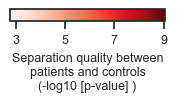

In [143]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# Parameters
cmap_name = 'Reds'
min_val = 2.77559854463559
max_val = 9.06072609795248
label = 'Separation quality between\npatients and controls\n(-log10 [p-value] )'

# Create a figure for the colorbar with a smaller size
fig, ax = plt.subplots(figsize=(2, 0.2))  # Smaller figure size for fitting in a paper
fig.subplots_adjust(bottom=0.3)  # Adjust spacing to fit colorbar

# Colormap
cmap = plt.get_cmap(cmap_name)
norm = mpl.colors.Normalize(vmin=min_val, vmax=max_val)

# Create colorbar
cb = mpl.colorbar.ColorbarBase(ax, cmap=cmap, norm=norm, orientation='horizontal')
cb.set_label(label, fontsize=9)  # Set font size for label

# Set ticks at 3, 5, 7, 9 and font size for ticks
cb.set_ticks([3, 5, 7, 9])
cb.ax.tick_params(labelsize=9)  # Set font size for ticks

# save
# plt.savefig('figures/heatmap_colorbar.png', dpi=300, bbox_inches='tight', transparent=False)
# save as pdf
plt.savefig("figures/heatmap_colorbar.pdf", dpi=DPI, bbox_inches="tight", pad_inches=0.02)
# Show the plot
plt.show()


[OK] Using features (plots/stats): ['amplitude', 'group_event_duration_z', 'group_event_spatial_spread_z']

Summary stats (pooled, IQR-outliers removed per group) | subjects=16

Feature: amplitude
  n (undetected, detected): 59,637, 3,735
  Median (undetected, detected): 3.65, 5.432
  Mean(t3%) (undetected, detected): 4.004, 5.95
  Mann–Whitney U: 1.478e+08 | p=2.69e-247 | p_FDR=2.69e-247 | stars=****
  Cliff's Δ=0.327  CI95% [0.307, 0.345]

Feature: group_event_duration_z
  n (undetected, detected): 59,773, 3,861
  Median (undetected, detected): -0.6438, 0.17
  Mean(t3%) (undetected, detected): -0.2171, 0.429
  Mann–Whitney U: 1.54e+08 | p=2.25e-286 | p_FDR=3.38e-286 | stars=****
  Cliff's Δ=0.334  CI95% [0.316, 0.353]

Feature: group_event_spatial_spread_z
  n (undetected, detected): 33,509, 3,372
  Median (undetected, detected): -0.3655, -0.08895
  Mean(t3%) (undetected, detected): -0.3402, 0.7388
  Mann–Whitney U: 8.762e+07 | p=0 | p_FDR=0 | stars=****
  Cliff's Δ=0.551  CI95% [0.5

C:\Users\user\anaconda3\envs\depth_ieds\Lib\site-packages\seaborn\categorical.py:253: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
C:\Users\user\anaconda3\envs\depth_ieds\Lib\site-packages\seaborn\categorical.py:253: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
C:\Users\user\anaconda3\envs\depth_ieds\Lib\site-packages\seaborn\categorical.py:253: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt t

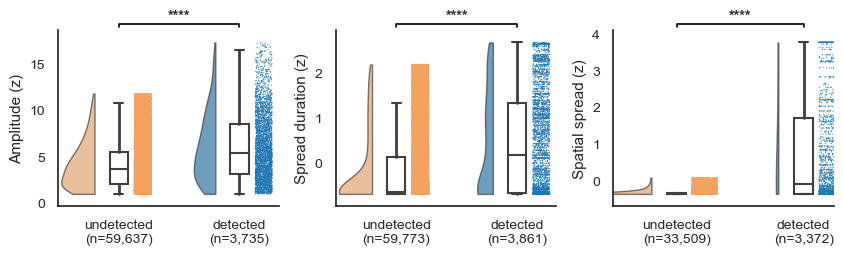

In [262]:
# ================= RainCloud (ptitprince), 3 panels, stars only, clean axes =================
import re
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.stats import trim_mean, mannwhitneyu, rankdata
from statsmodels.stats.multitest import multipletests
import ptitprince as pt  # דורש pip install ptitprince

# ---------- paths & config ----------
ROOT_DIR = Path(r"C:\repos\spikes_notebooks\paper\ofer_pipe")  # <<< עדכני אם צריך
OUT_DIR = ROOT_DIR / "analysis_outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# We will PLOT these three (note: last two are now z-scores)
# amplitude is ALREADY z-scored in your data → we only relabel units
PLOT_FEATURES = [
    "amplitude",                     # already z
    "group_event_duration_z",        # NEW: z-scored
    "group_event_spatial_spread_z",  # NEW: z-scored
]

# Nice y-axis labels for these plot columns
Y_LABELS = {
    "amplitude": "Amplitude (z)",
    "group_event_duration_z": "Spread duration (z)",
    "group_event_spatial_spread_z": "Spatial spread (z)",
}

TRIM = 0.03
pattern = "**/*_flat_features.csv"

# צבעים: undetected=כתום, detected=כחול (היפוך שביקשת)
COLOR_DETECTED   = "#1f77b4"
COLOR_UNDETECTED = "#ff7f0e"
PALETTE_GROUP = {"undetected": COLOR_UNDETECTED, "detected": COLOR_DETECTED}
ORDER = ["undetected", "detected"]

# ---------- helpers ----------
def parse_subject_from_path(path: Path) -> str:
    m = re.search(r"(p\d+)", str(path))
    return m.group(1) if m else path.stem

def remove_outliers_iqr(df_in, col, by="is_in_scalp", k=1.5):
    parts = []
    for _, g in df_in.groupby(by, observed=True):
        s = g[col].dropna()
        if s.empty:
            continue
        Q1, Q3 = s.quantile([0.25, 0.75])
        IQR = Q3 - Q1
        lo, hi = Q1 - k*IQR, Q3 + k*IQR
        parts.append(g[(g[col] >= lo) & (g[col] <= hi)])
    return pd.concat(parts) if parts else df_in.dropna(subset=[col])

def prep_feature_df(df_in: pd.DataFrame, feat: str) -> pd.DataFrame:
    """
    - If we plot a z-feature for spatial spread, also filter raw sentinel -1.
    - Then remove IQR outliers on the actual plotted column.
    """
    d = df_in.copy()
    # Filter out spatial-spread sentinel even when using the z column
    if "group_event_spatial_spread" in feat and "group_event_spatial_spread" in d.columns:
        d = d[d["group_event_spatial_spread"] != -1]
    d = d.dropna(subset=[feat])
    d = remove_outliers_iqr(d, feat)
    return d

def p_to_stars(p):
    if p is None or not np.isfinite(p): return "n.s."
    if p < 1e-4: return "****"
    if p < 1e-3: return "***"
    if p < 1e-2: return "**"
    if p < 5e-2: return "*"
    return "n.s."

# Vargha–Delaney A12 + Cliff's delta
def cliffs_delta(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    na, nb = len(a), len(b)
    if na == 0 or nb == 0:
        return np.nan, np.nan
    joint = np.concatenate([a, b])
    r = rankdata(joint, method="average")
    r_a_sum = r[:na].sum()
    A12 = (r_a_sum - na*(na+1)/2.0) / (na*nb)
    delta = 2*A12 - 1
    return delta, A12

def bootstrap_ci_delta(a, b, n_boot=1000, alpha=0.05, seed=123):
    rng = np.random.default_rng(seed)
    a = np.asarray(a, dtype=float); b = np.asarray(b, dtype=float)
    na, nb = len(a), len(b)
    if na == 0 or nb == 0:
        return (np.nan, np.nan)
    deltas = np.empty(n_boot, dtype=float)
    for i in range(n_boot):
        d, _ = cliffs_delta(a[rng.integers(0, na, na)], b[rng.integers(0, nb, nb)])
        deltas[i] = d
    return (float(np.quantile(deltas, alpha/2)), float(np.quantile(deltas, 1-alpha/2)))

# ---------- load & pool ----------
files = sorted(ROOT_DIR.glob(pattern))
dfs = []
for f in files:
    try:
        d0 = pd.read_csv(f)
    except Exception as e:
        print(f"[WARN] Failed {f}: {e}")
        continue
    if "is_in_scalp" not in d0.columns:
        print(f"[WARN] 'is_in_scalp' missing in {f.name}, skipping.")
        continue
    d0["is_in_scalp"] = d0["is_in_scalp"].map(
        {True:"detected", False:"undetected", "True":"detected", "False":"undetected"}
    ).fillna(d0["is_in_scalp"])
    d0["subject"] = parse_subject_from_path(f)

    # Keep raw columns we need for z transforms + plot columns
    keep_raw = ["is_in_scalp","subject","amplitude","group_event_duration","group_event_spatial_spread"]
    keep = [c for c in keep_raw if c in d0.columns]
    if not keep:
        continue
    dfs.append(d0[keep])

if not dfs:
    raise SystemExit("No valid CSVs. Check ROOT_DIR/pattern.")

df = pd.concat(dfs, ignore_index=True)
n_subjects = df["subject"].nunique()
df["is_in_scalp"] = pd.Categorical(df["is_in_scalp"], ORDER, ordered=True)

# ---------- NEW: create z-score versions for duration & spatial spread ----------
def zscore(series: pd.Series) -> pd.Series:
    mu = series.mean(skipna=True)
    sd = series.std(ddof=0, skipna=True)
    return (series - mu) / sd if sd and np.isfinite(sd) and sd > 0 else pd.Series(np.nan, index=series.index)

if "group_event_duration" in df.columns:
    df["group_event_duration_z"] = zscore(df["group_event_duration"])
if "group_event_spatial_spread" in df.columns:
    # Keep raw for sentinel filtering; make z for plotting
    df["group_event_spatial_spread_z"] = zscore(df["group_event_spatial_spread"])

# Which requested features are actually present & have data
features_present = [f for f in PLOT_FEATURES if f in df.columns and df[f].notna().any()]
print(f"[OK] Using features (plots/stats): {features_present}")

# ---------- stats: Mann–Whitney + FDR on the plotted variables (z for last two) ----------
rows_test = []
for feat in features_present:
    d = prep_feature_df(df, feat)
    det = d.loc[d["is_in_scalp"]=="detected", feat]
    und = d.loc[d["is_in_scalp"]=="undetected", feat]
    if det.empty or und.empty:
        rows_test.append({"feature": feat, "U": np.nan, "p_value": np.nan})
    else:
        U, p = mannwhitneyu(det, und, alternative="two-sided")
        rows_test.append({"feature": feat, "U": float(U), "p_value": float(p)})

test_df = pd.DataFrame(rows_test).sort_values("feature")
if test_df["p_value"].notna().any():
    rej, p_corr, _, _ = multipletests(test_df["p_value"].fillna(1.0), method="fdr_bh")
    test_df["p_value_fdr"] = p_corr
    test_df["significant_fdr"] = rej
else:
    test_df["p_value_fdr"] = np.nan
    test_df["significant_fdr"] = False

# ---------- Effect size ----------
rows_eff = []
for feat in features_present:
    d = prep_feature_df(df, feat)
    a = d.loc[d["is_in_scalp"]=="detected", feat].values
    b = d.loc[d["is_in_scalp"]=="undetected", feat].values
    if len(a)==0 or len(b)==0:
        rows_eff.append({"feature": feat, "cliffs_delta": np.nan, "A12": np.nan,
                         "delta_ci_low": np.nan, "delta_ci_high": np.nan})
        continue
    delta, A12 = cliffs_delta(a, b)
    lo, hi = bootstrap_ci_delta(a, b, n_boot=1000, alpha=0.05)
    rows_eff.append({"feature": feat, "cliffs_delta": float(delta), "A12": float(A12),
                     "delta_ci_low": lo, "delta_ci_high": hi})

eff_df = pd.DataFrame(rows_eff).sort_values("feature")
full_stats = test_df.merge(eff_df, on="feature", how="left")

# ---------- print stats (לקונסול בלבד) ----------
print("\n" + "="*90)
print(f"Summary stats (pooled, IQR-outliers removed per group) | subjects={n_subjects}")
print("="*90)
for feat in features_present:
    d = prep_feature_df(df, feat)
    counts = d.groupby("is_in_scalp", observed=True)[feat].size().reindex(ORDER).fillna(0).astype(int)
    med = d.groupby("is_in_scalp", observed=True)[feat].median().reindex(ORDER)
    mean_trim = (d.groupby("is_in_scalp", observed=True)[feat]
                   .apply(lambda x: trim_mean(x, proportiontocut=TRIM))).reindex(ORDER)
    row = full_stats.loc[full_stats["feature"]==feat].iloc[0]
    print(f"\nFeature: {feat}")
    print(f"  n (undetected, detected): {counts['undetected']:,}, {counts['detected']:,}")
    print(f"  Median (undetected, detected): {med['undetected']:.4g}, {med['detected']:.4g}")
    print(f"  Mean(t{int(TRIM*100)}%) (undetected, detected): {mean_trim['undetected']:.4g}, {mean_trim['detected']:.4g}")
    print(f"  Mann–Whitney U: {row['U']:.4g} | p={row['p_value']:.3g} | p_FDR={row['p_value_fdr']:.3g} | stars={p_to_stars(row['p_value_fdr'])}")
    print(f"  Cliff's Δ={row['cliffs_delta']:.3f}  CI95% [{row['delta_ci_low']:.3f}, {row['delta_ci_high']:.3f}]")

# === עדכונים בראש הקובץ ===
# צבעים: undetected כתום פסטלי, detected כחול
COLOR_DETECTED   = "#1f77b4"
COLOR_UNDETECTED = "#f4a261"   # כתום פסטלי נעים
PALETTE_GROUP = {"undetected": COLOR_UNDETECTED, "detected": COLOR_DETECTED}

# תוויות Y מעודכנות (שימי לב: הכל z)
Y_LABELS = {
    "amplitude": "Amplitude (z)",
    "group_event_duration_z": "Spread duration (z)",
    "group_event_spatial_spread_z": "Spatial spread (z)",
}

# # מגבלות Y: טווח סימטרי סביר ל-z
# YLIMS = {
#     "amplitude": (-3.0, 3.0),
#     "group_event_duration_z": (-3.0, 3.0),
#     "group_event_spatial_spread_z": (-3.0, 3.0),
# }

# === helper קטן לסוגריים+כוכביות מחוץ לאזור הדאטה (לא נחתך) ===
from matplotlib import transforms as mtransforms
BRACKET_Y_FRAC = 1.02   # הקו קצת מעל הציר
BRACKET_TICK   = 0.015
STAR_Y_FRAC    = 1.04

def draw_sig_bracket(ax, star, x0=0, x1=1):
    trans = mtransforms.blended_transform_factory(ax.transData, ax.transAxes)
    y0 = BRACKET_Y_FRAC
    y1 = BRACKET_Y_FRAC + BRACKET_TICK
    ax.plot([x0, x0, x1, x1], [y0, y1, y1, y0],
            transform=trans, clip_on=False, color="black", lw=1.2, zorder=10)
    ax.text((x0+x1)/2, STAR_Y_FRAC, star, transform=trans,
            ha="center", va="bottom", fontsize=10.5, weight="bold", zorder=11)

# ================= Plotting: RainCloud אמיתי, 3 פאנלים, נק' קטנות, A4 =================
sns.set_context("notebook", font_scale=1.0)
sns.set_style("white")
mpl.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

# A4-ish: make it a bit wider than before (was 7in → now 8.6in)
fig, axes = plt.subplots(1, 3, figsize=(8.6, 2.7))
axes = axes.flatten()

pmap = {r["feature"]: r["p_value_fdr"] for _, r in test_df.iterrows()}

# RainCloud params (kept your spread panel slightly wider)
RAIN_PARAMS = {
    "default": dict(bw=0.35, width_viol=0.55, move=0.20, jitter=0.07, point_size=0.8, alpha=0.7),
    "group_event_spatial_spread_z": dict(bw=0.7, width_viol=0.9, move=0.22, jitter=0.10, point_size=0.8, alpha=0.7),
}

def draw_raincloud(ax, feat, y_label):
    d = prep_feature_df(df, feat)
    if d.empty:
        ax.set_visible(False); return

    # aesthetics
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # params
    rp   = RAIN_PARAMS.get(feat, RAIN_PARAMS["default"])
    bw   = rp["bw"]; width_viol = rp["width_viol"]; move = rp["move"]
    jit  = rp["jitter"]; psize  = rp["point_size"]; alpha = rp["alpha"]

    # RainCloud
    pt.RainCloud(
        x="is_in_scalp", y=feat, data=d, order=["undetected","detected"],
        palette=[PALETTE_GROUP["undetected"], PALETTE_GROUP["detected"]],
        bw=bw, width_viol=width_viol, move=move, alpha=alpha,
        orient='v', ax=ax,
        pointplot=False, box_showfliers=False,
        jitter=jit, point_size=psize
    )

    # labels
    ax.set_xlabel("")
    ax.set_ylabel(y_label)

    # xticks with n
    counts = (d.groupby("is_in_scalp", observed=True)[feat]
                .size().reindex(["undetected","detected"]).fillna(0).astype(int))
    ax.set_xticks([0, 1], [f"undetected\n(n={counts['undetected']:,})",
                           f"detected\n(n={counts['detected']:,})"])

    # --- dynamic y-limits with small padding ---
    vals = d[feat].to_numpy()
    y_min = np.nanmin(vals)
    y_max = np.nanmax(vals)
    if not np.isfinite(y_min) or not np.isfinite(y_max):
        y_min, y_max = -1.0, 1.0  # safe fallback
    if y_min == y_max:
        pad = 1.0
    else:
        pad = 0.08 * (y_max - y_min)  # 8% padding
    ax.set_ylim(y_min - pad, y_max + pad)

    # stars bracket uses axis-fraction coords, so it stays above even with autoscale
    star = p_to_stars(pmap.get(feat, np.nan))
    draw_sig_bracket(ax, star)

    # no legend
    leg = ax.get_legend()
    if leg: leg.remove()
    
    
# Draw three panels (in the order defined above)
panel_feats = [f for f in PLOT_FEATURES if f in features_present][:3]
for ax, feat in zip(axes, panel_feats):
    draw_raincloud(ax, feat, Y_LABELS.get(feat, f"{feat} (z)"))

# hide unused axes if any
for j in range(len(panel_feats), len(axes)):
    fig.delaxes(axes[j])

for ax in fig.get_axes():
    # Find and rasterize only the scatter/violin/box elements
    for artist in ax.get_children():
        if isinstance(artist, (mpl.collections.PathCollection,  # scatter points
                              mpl.collections.PolyCollection)):  # violin plots
            artist.set_rasterized(True)
            
plt.tight_layout()
with mpl.rc_context({
    "pdf.fonttype": 42,      # keep text editable in PDF
    "ps.fonttype": 42,
    "font.family": "Arial",
    "axes.unicode_minus": False,
}):
    fig.savefig("figures/supp1_new.pdf", dpi=300, bbox_inches="tight", pad_inches=0.02)
plt.show()
